# Analysis — leave-one-out, visualization, regression, Bayesian optimization, LVGP, trees

Loads `master_df` directly from an Excel workbook. The loader cell below prompts for the workbook path and sheet name (press Enter to accept the defaults), so when new data arrives you only have to point it at the new file or sheet.

In [1]:
# --- preamble: ensure relative paths resolve to repository_dmref root ---
import os
if os.path.basename(os.getcwd()) != 'repository_dmref':
    os.chdir('..')
print('cwd =', os.getcwd())


cwd = /data/zhq7531/IDEAL/DMREF/repository_dmref


In [2]:
# --- Load master_df from Excel ---
# Prompts for the Excel file path and sheet name so it is easy to point at
# a new export whenever more data arrives. Press Enter to accept the default.
import pandas as pd
from pathlib import Path

DEFAULT_FILE = "Processed_data_inputs/second_iteration_orthogonal/XPS_XRD_with_newdata_clean_v02.xlsx"
DEFAULT_SHEET = "master_xps_xrd"

file_in = input(f"Excel file path (relative to repo root) [{DEFAULT_FILE}]: ").strip()
excel_path = file_in or DEFAULT_FILE
if not Path(excel_path).exists():
    raise FileNotFoundError(f"Excel file not found: {excel_path}")

xl = pd.ExcelFile(excel_path)
print("\nAvailable sheets:")
for s in xl.sheet_names:
    print(f"  - {s}")

sheet_in = input(f"\nSheet name to use [{DEFAULT_SHEET}]: ").strip()
sheet_name = sheet_in or DEFAULT_SHEET
if sheet_name not in xl.sheet_names:
    raise ValueError(f"Sheet '{sheet_name}' not found. Available: {xl.sheet_names}")

master_df = pd.read_excel(excel_path, sheet_name=sheet_name)

# The master sheet is built by horizontally concatenating Experiments/XPS/XRD
# sheets, which leaves duplicate key columns like Experiment.1, Trial.1, etc.
# Drop those so downstream code sees a single Experiment / Trial column.
dup_cols = [c for c in master_df.columns if c.split('.')[-1].isdigit() and c.split('.')[0] in master_df.columns]
if dup_cols:
    print(f"\nDropping redundant duplicate columns: {dup_cols}")
    master_df = master_df.drop(columns=dup_cols)

print(f"\nLoaded master_df from '{excel_path}' :: '{sheet_name}'")
print(f"Shape: {master_df.shape}")
print(f"\nColumns ({len(master_df.columns)}):")
for c in master_df.columns:
    print(f"  - {c}  ({master_df[c].dtype})")
print("\nFirst 3 rows:")
print(master_df.head(3))



Available sheets:
  - Experiments_v00
  - XPS
  - XRD
  - master_xps_xrd

Dropping redundant duplicate columns: ['Experiment.1', 'Trial.1', 'Experiment.2', 'Trial.2']

Loaded master_df from 'Processed_data_inputs/second_iteration_orthogonal/XPS_XRD_with_newdata_clean_v02.xlsx' :: 'master_xps_xrd'
Shape: (51, 27)

Columns (27):
  - Experiment  (int64)
  - Trial  (int64)
  - Power (W)  (int64)
  - Substrate Temp (°C)  (int64)
  - O2 Flow (sccm)  (float64)
  - Pressure (mTorr)  (int64)
  - Anneal Condition  (object)
  - Anneal Temp (°C)  (int64)
  - Hall Mobility (cm^2/V·s)  (float64)
  - Anneal Condition Num  (int64)
  - In3d_p1  (float64)
  - In3d_p2  (float64)
  - O1s_p1  (float64)
  - Ta4f_p1  (float64)
  - Ta4f_p2  (float64)
  - Area_In3d  (float64)
  - Area_O1s  (float64)
  - Area_Ta4f  (float64)
  - Peak01  (float64)
  - Peak02  (float64)
  - Peak03  (float64)
  - Height01  (int64)
  - Height02  (int64)
  - Height03  (int64)
  - FWHM01  (float64)
  - FWHM02  (float64)
  - FWHM03  

# Leave one out

In [3]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

target = "Hall Mobility (cm^2/V·s)"

# Same process predictors you used before
process_predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",   # categorical
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
]

# -------------------------------------------------
# Build modeling dataframe with Experiment column
# -------------------------------------------------
cols_needed = ["Experiment"] + process_predictors + [target]
df_all = master_df[cols_needed].dropna().copy()

print("Number of rows used for CV:", len(df_all))
print("Experiments:", sorted(df_all["Experiment"].unique()))

# -------------------------------------------------
# Rebuild the SAME formula as in your main model
# -------------------------------------------------
main_terms = [
    "Q('Power (W)')",
    "Q('Substrate Temp (°C)')",
    "Q('O2 Flow (sccm)')",
    "Q('Pressure (mTorr)')",
    "Q('Anneal Temp (°C)')",
    # Anneal Condition only appears through interaction
]

interaction_terms = [
    "Q('Substrate Temp (°C)'):Q('O2 Flow (sccm)')",     # Substrate Temp × O2 Flow
    "Q('Power (W)'):Q('O2 Flow (sccm)')",              # Power × O2 Flow
    "Q('Power (W)'):C(Q('Anneal Condition Num'))",     # Power × Anneal Condition (categorical)
]

rhs = " + ".join(main_terms + interaction_terms)
formula = f"Q('{target}') ~ {rhs}"
print("Formula used for CV:")
print(formula)

# -------------------------------------------------
# Leave-one-experiment-out CV
# -------------------------------------------------
results = []

for exp_id in sorted(df_all["Experiment"].unique()):
    # split train / test by experiment
    df_train = df_all[df_all["Experiment"] != exp_id]
    df_test = df_all[df_all["Experiment"] == exp_id]

    # fit on training experiments
    model_cv = smf.ols(formula=formula, data=df_train).fit()

    # predict for held-out experiment
    y_test = df_test[target]
    y_pred = model_cv.predict(df_test)

    # metrics
    mse = np.mean((y_test - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_test - y_pred))

    ss_res = np.sum((y_test - y_pred) ** 2)
    ss_tot = np.sum((y_test - y_test.mean()) ** 2)
    r2_test = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    results.append({
        "Held_out_experiment": exp_id,
        "n_test": len(df_test),
        "RMSE": rmse,
        "MAE": mae,
        "R2_test": r2_test,
    })

cv_df = pd.DataFrame(results)
display(cv_df)

print("\nAverage across folds:")
print(cv_df[["RMSE", "MAE", "R2_test"]].mean())


Number of rows used for CV: 47
Experiments: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(15), np.int64(16), np.int64(17)]
Formula used for CV:
Q('Hall Mobility (cm^2/V·s)') ~ Q('Power (W)') + Q('Substrate Temp (°C)') + Q('O2 Flow (sccm)') + Q('Pressure (mTorr)') + Q('Anneal Temp (°C)') + Q('Substrate Temp (°C)'):Q('O2 Flow (sccm)') + Q('Power (W)'):Q('O2 Flow (sccm)') + Q('Power (W)'):C(Q('Anneal Condition Num'))


,Held_out_experiment,n_test,RMSE,MAE,R2_test
0,1,3,26.825673,24.806743,-5.903313
1,2,3,23.999477,22.047661,-5.408583
2,3,3,13.270572,13.188938,-80.531523
3,4,3,40.549666,40.473556,-265.639258
4,5,3,64.391500,64.383745,-4150.708686
5,6,3,22.493979,22.178965,-34.954856
6,7,3,20.055423,19.902956,-65.020441
7,8,3,44.324575,44.284318,-549.776270
8,9,3,23.512814,22.907136,-18.663579
9,10,3,17.191215,16.878241,-26.716549



Average across folds:
RMSE        24.905019
MAE         24.265695
R2_test   -531.292620
dtype: float64


# Visualization

## Noise on the data (calc coefficient of variation)

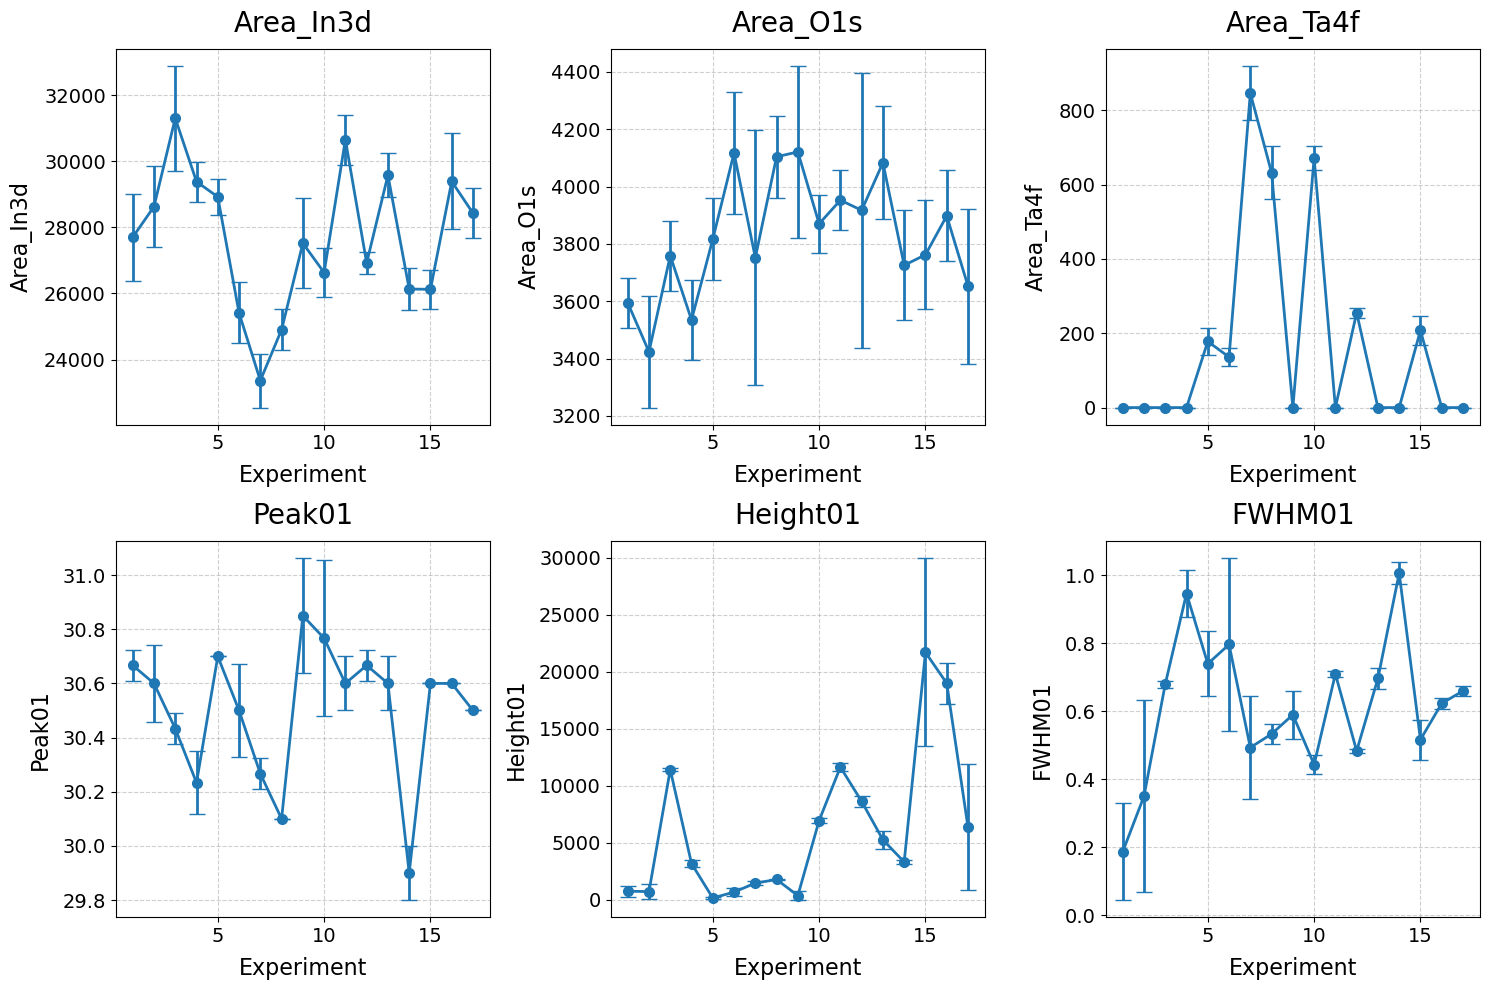

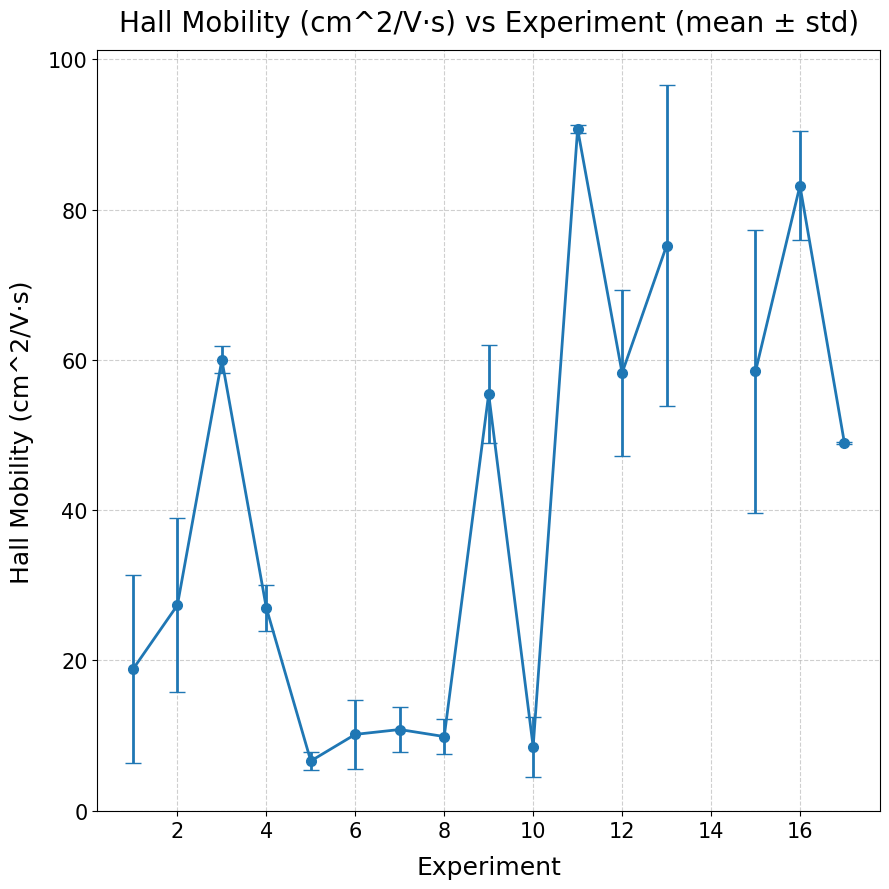

Coefficient of variation per experiment (percent):


,CV_%_Area_In3d,CV_%_Area_O1s,CV_%_Area_Ta4f,CV_%_Peak01,CV_%_Height01,CV_%_FWHM01,CV_%_Hall Mobility (cm^2/V·s)
Experiment,,,,,,,
1,4.762,2.454,nan,0.188,61.957,76.202,66.396
2,4.295,5.680,nan,0.462,92.257,80.812,42.427
3,5.074,3.237,nan,0.190,1.339,1.471,3.000
4,2.043,3.940,nan,0.382,9.652,7.190,11.264
5,1.916,3.764,20.419,0.000,34.032,12.891,18.470
6,3.639,5.132,17.890,0.568,56.718,31.862,45.191
7,3.497,11.835,8.691,0.191,11.845,30.764,27.956
8,2.481,3.469,11.211,0.000,4.629,5.728,23.420
9,4.953,7.291,nan,0.688,105.509,11.985,11.708


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) columns we want to analyze
cols_to_agg = [
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Peak01",
    "Height01",
    "FWHM01",
    "Hall Mobility (cm^2/V·s)",
]

# keep only those that exist
cols_to_agg = [c for c in cols_to_agg if c in master_df.columns]

# 2) group by experiment and compute mean and std
grp_mean = master_df.groupby("Experiment")[cols_to_agg].mean(numeric_only=True)
grp_std = master_df.groupby("Experiment")[cols_to_agg].std(numeric_only=True)

# separate hall mobility if present
hall_col = "Hall Mobility (cm^2/V·s)"
has_hall = hall_col in cols_to_agg

# variables to plot in the 3x2 grid (exclude hall mobility)
grid_cols = [c for c in cols_to_agg if c != hall_col]

# 3) make a 2x3 figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, col in zip(axes, grid_cols):
    x = grp_mean.index.values
    y = grp_mean[col].values
    yerr = grp_std[col].values

    ax.errorbar(x, y, yerr=yerr, fmt="o-", capsize=6, markersize=7, linewidth=2)
    ax.set_title(col, fontsize=20, pad=12)
    ax.set_xlabel("Experiment", fontsize=16, labelpad=8)
    ax.set_ylabel(col, fontsize=16, labelpad=8)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True, linestyle='--', alpha=0.6)

# hide any unused axes
for i in range(len(grid_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# 3b) plot hall mobility separately
if has_hall:
    plt.figure(figsize=(9, 9))
    x = grp_mean.index.values
    y = grp_mean[hall_col].values
    yerr = grp_std[hall_col].values
    plt.errorbar(x, y, yerr=yerr, fmt="o-", capsize=6, markersize=7, linewidth=2)
    plt.title(f"{hall_col} vs Experiment (mean ± std)", fontsize=20, pad=14)
    plt.xlabel("Experiment", fontsize=18, labelpad=10)
    plt.ylabel(hall_col, fontsize=18, labelpad=10)
    plt.tick_params(axis='both', which='major', labelsize=15)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# 4) coefficient of variation (CV = std / mean) as PERCENT
cv_df = (grp_std / grp_mean.replace(0, np.nan)) * 100
cv_df = cv_df.add_prefix("CV_%_")

print("Coefficient of variation per experiment (percent):")
display(
    cv_df.style.format("{:.3f}").background_gradient(cmap="Blues")
)
cv_df.to_excel("output/cv_percetage.xlsx", index_label=False)


In [5]:
hall_col = "Hall Mobility (cm^2/V·s)"

# 1) Design table: one row per experiment with the knob settings
design_cols = [
    "Experiment",
    "Power (W)",
    "Substrate Temp (°C)",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Condition Num",
    "Anneal Temp (°C)",
]

design_df = (
    master_df[design_cols]
    .drop_duplicates(subset="Experiment")
    .set_index("Experiment")
)

# 2) Mean and std of Hall mobility per experiment
hall_mean = grp_mean[[hall_col]].rename(
    columns={hall_col: "Hall mobility mean (cm^2/V·s)"}
)
hall_std = grp_std[[hall_col]].rename(
    columns={hall_col: "Hall mobility std (cm^2/V·s)"}
)

# 3) Merge into a single summary table
summary = design_df.join(hall_mean).join(hall_std).reset_index()

# 4) Save to Excel
summary.to_excel("output/experiment_hall_stats.xlsx", index=False)

print(summary)


    Experiment  Power (W)  Substrate Temp (°C)  O2 Flow (sccm)  \
0            1         10                   25             0.3   
1            2         10                   25             0.3   
2            3         10                  400             3.0   
3            4         10                  400             3.0   
4            5         30                   25             3.0   
5            6         30                   25             3.0   
6            7         30                  400             0.3   
7            8         30                  400             0.3   
8            9         20                   25             3.0   
9           10         30                   25             0.3   
10          11         20                  400             2.0   
11          12         20                  400             0.3   
12          13         10                   25             2.0   
13          14         20                   25             2.0   
14        

In [6]:
# build a per-trial dataset with knobs + Hall mobility
cols = design_cols + [hall_col]   # from your code
df_trials = master_df[cols].dropna(subset=[hall_col]).copy()


## correlation matrix 

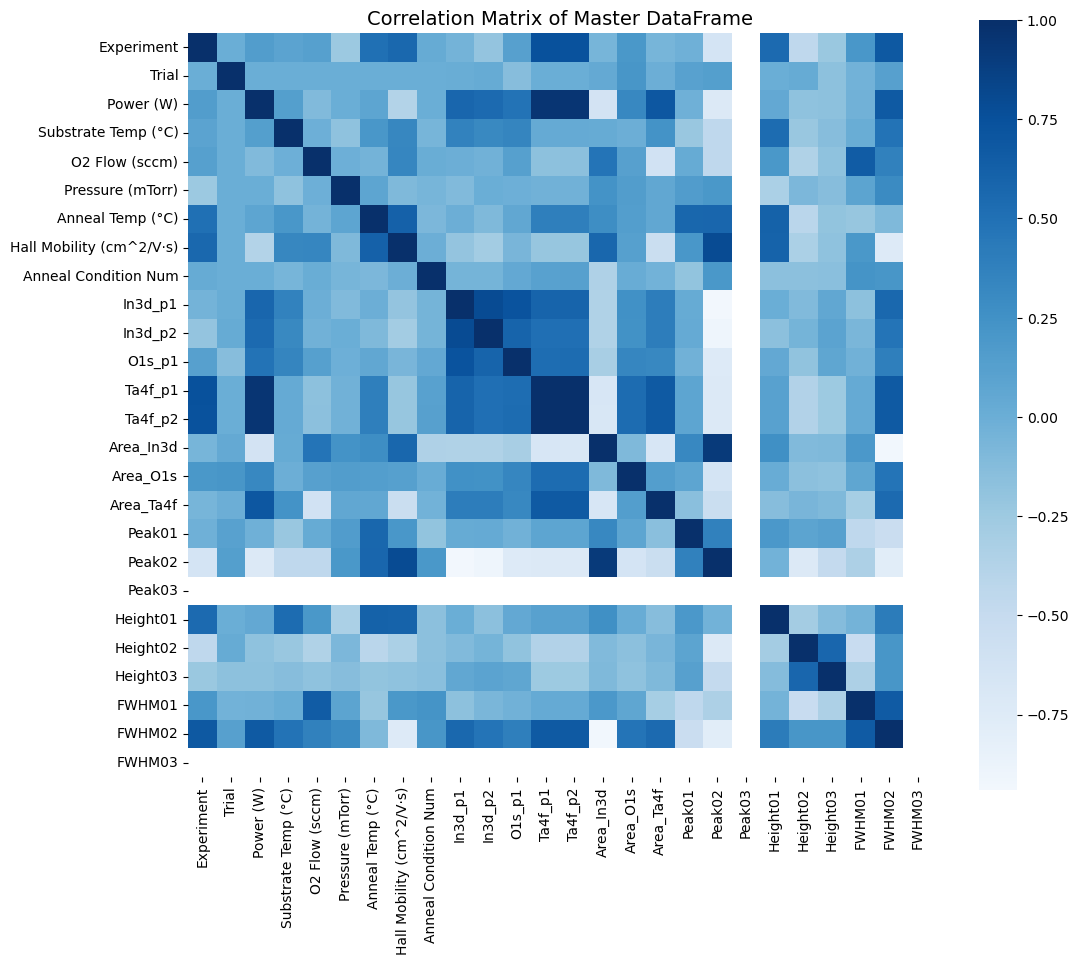

                            Experiment         Trial     Power (W)  \
Experiment                1.000000e+00  1.567374e-16  1.572070e-01   
Trial                     1.567374e-16  1.000000e+00  9.647018e-17   
Power (W)                 1.572070e-01  9.647018e-17  1.000000e+00   
Substrate Temp (°C)       9.622504e-02  0.000000e+00  1.402709e-01   
O2 Flow (sccm)            1.341852e-01  4.655484e-18 -1.039161e-01   
Pressure (mTorr)         -2.405626e-01  3.204938e-17  6.229279e-17   
Anneal Temp (°C)          5.062618e-01  6.573185e-17  7.768390e-02   
Hall Mobility (cm^2/V·s)  5.659160e-01  1.191953e-03 -3.781700e-01   
Anneal Condition Num      2.405626e-02  5.341563e-18  7.059850e-17   
In3d_p1                  -3.929871e-02  1.181822e-02  5.800113e-01   
In3d_p2                  -1.982615e-01  2.408080e-02  5.498434e-01   
O1s_p1                    1.139108e-01 -1.322242e-01  4.798739e-01   
Ta4f_p1                   7.425373e-01  1.432180e-03  9.519337e-01   
Ta4f_p2             

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns from your master_df
df_corr = master_df.select_dtypes(include=["number"]).copy()

# Compute correlation matrix (Pearson by default)
corr_matrix = df_corr.corr()

# Display as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    # annot=True,       # show correlation values
    cmap="Blues",  # color palette
    center=0,
    fmt=".2f",
    square=True,
)
plt.title("Correlation Matrix of Master DataFrame", fontsize=14)
plt.show()

# Optional: save to Excel for exploration
# corr_matrix.to_excel("correlation_matrix.xlsx")
print(corr_matrix)


## Pair plots

Numeric columns used in pair plot:
['Experiment', 'Trial', 'Power (W)', 'Substrate Temp (°C)', 'O2 Flow (sccm)', 'Pressure (mTorr)', 'Anneal Temp (°C)', 'Hall Mobility (cm^2/V·s)', 'Anneal Condition Num', 'In3d_p1', 'In3d_p2', 'O1s_p1', 'Ta4f_p1', 'Ta4f_p2', 'Area_In3d', 'Area_O1s', 'Area_Ta4f', 'Peak01', 'Peak02', 'Peak03', 'Height01', 'Height02', 'Height03', 'FWHM01', 'FWHM02', 'FWHM03']


/data/zhq7531/envs/ml_gp_env/lib/python3.13/site-packages/pandas/plotting/_matplotlib/misc.py:100: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[j])
/data/zhq7531/envs/ml_gp_env/lib/python3.13/site-packages/pandas/plotting/_matplotlib/misc.py:101: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(boundaries_list[i])
/data/zhq7531/envs/ml_gp_env/lib/python3.13/site-packages/pandas/plotting/_matplotlib/misc.py:91: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[i])


<Figure size 1800x1800 with 0 Axes>

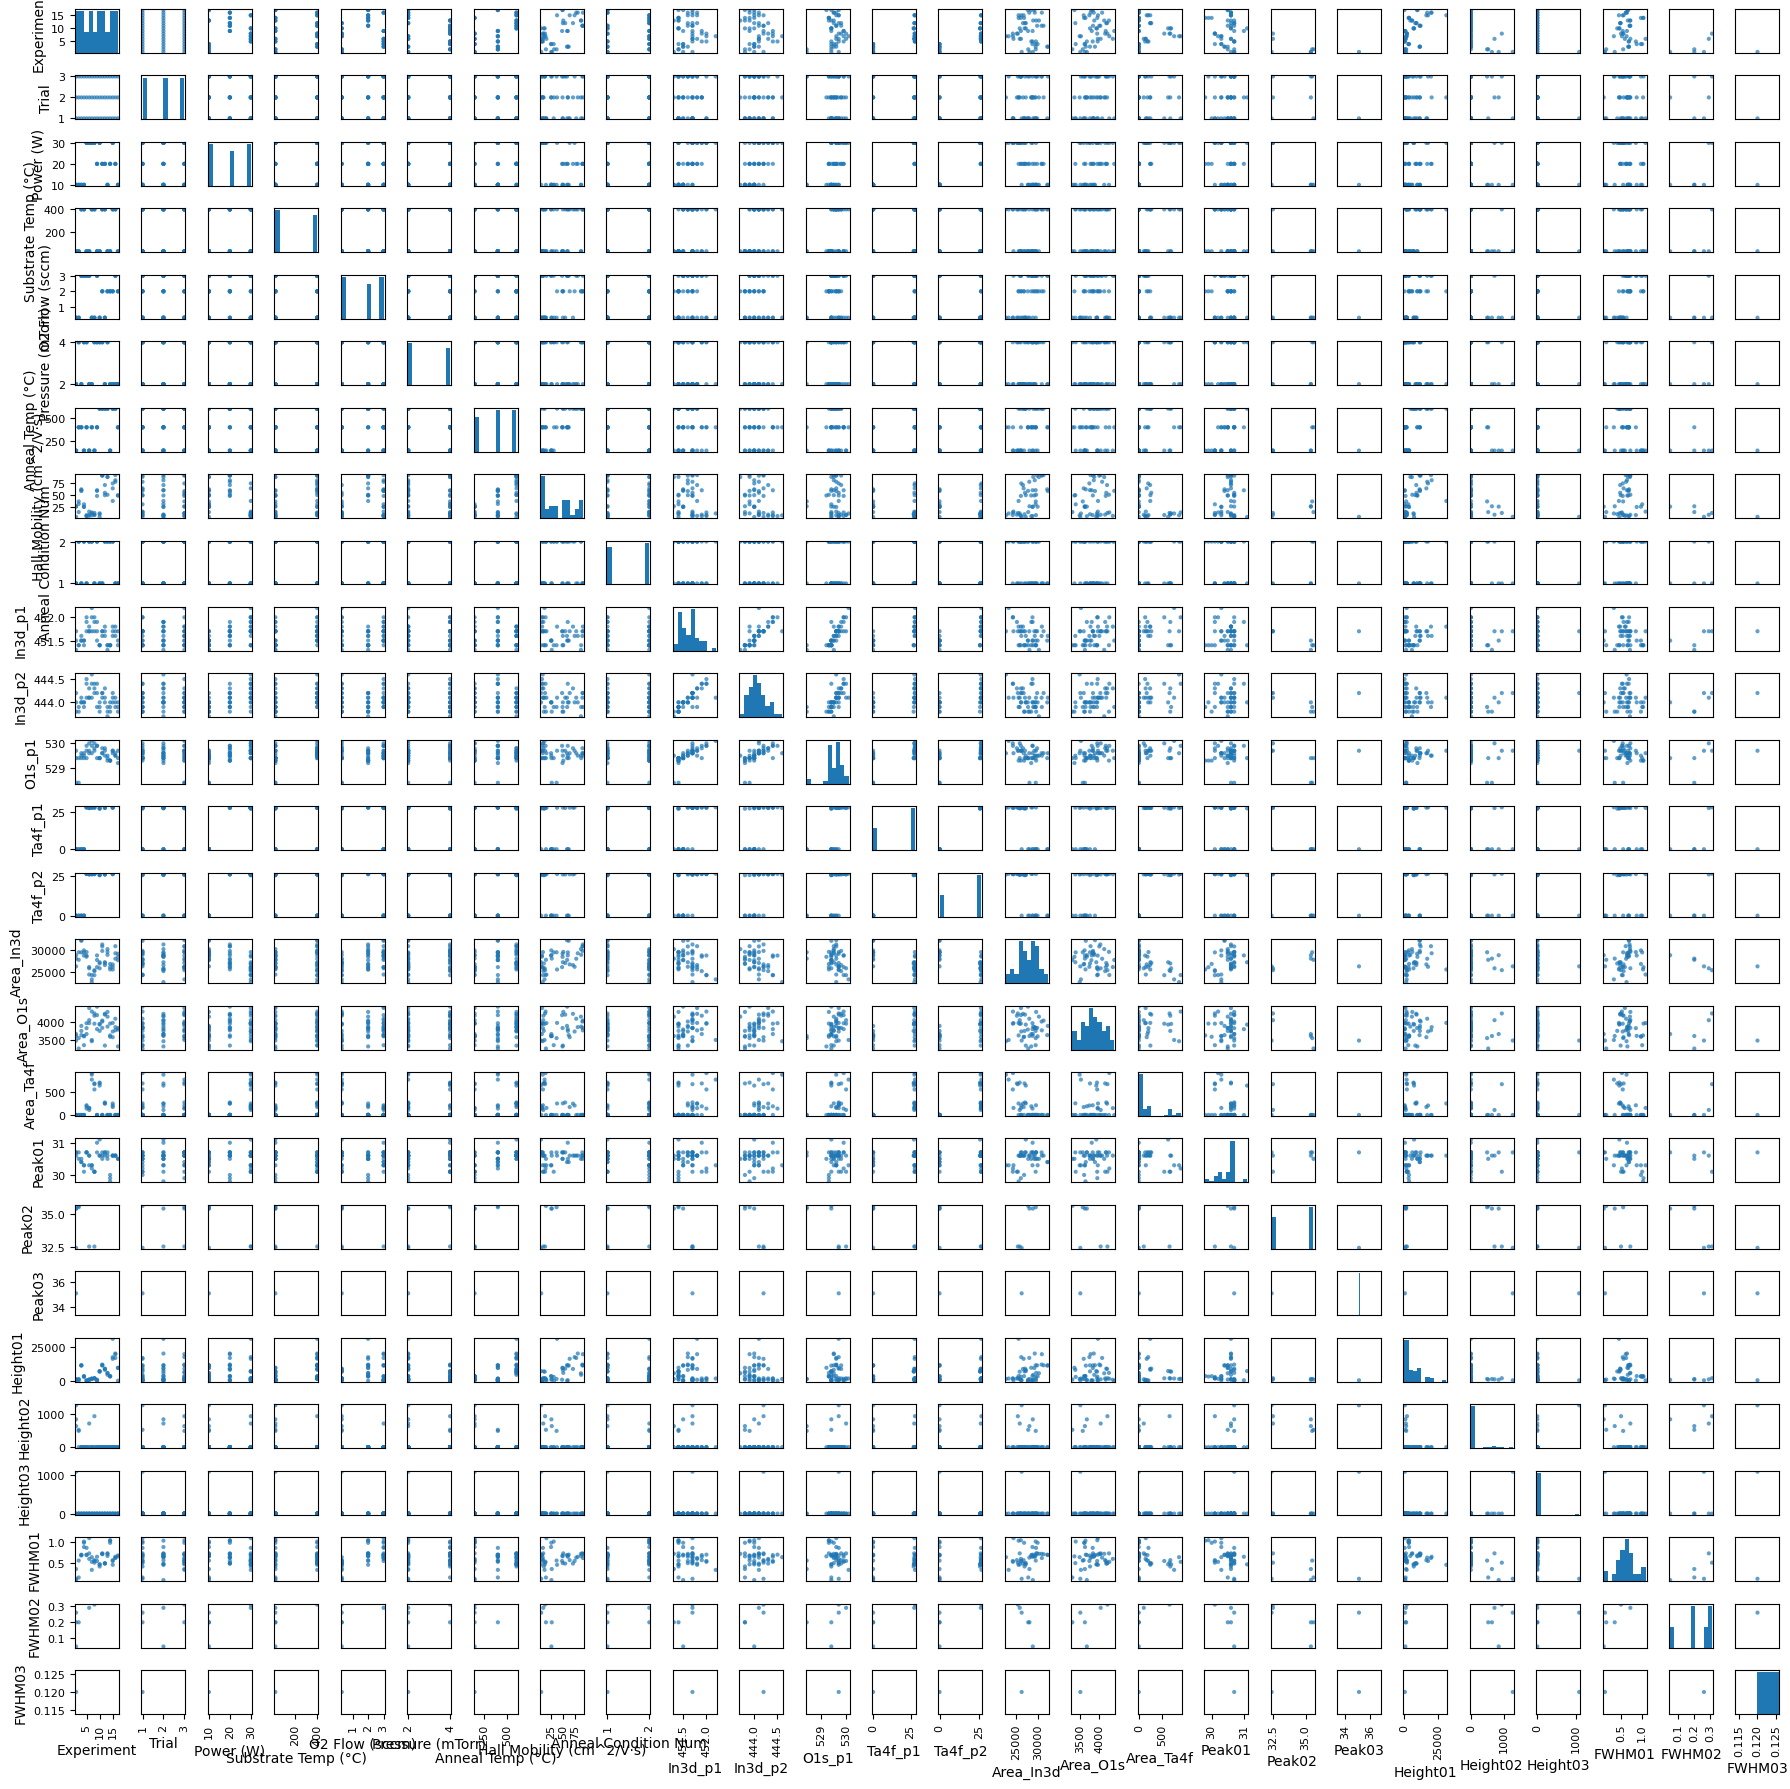

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# 1) pick only numeric columns from master_df
num_df = master_df.select_dtypes(include=[np.number]).copy()

print("Numeric columns used in pair plot:")
print(num_df.columns.tolist())

# 2) make a big scatter-matrix (pair plot)
plt.figure(figsize=(18, 18))
axes = scatter_matrix(
    num_df,
    diagonal='hist',
    alpha=0.7,
    figsize=(18, 18),
)

# make tick labels a bit smaller
for ax in axes.flatten():
    ax.tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()


Columns in pair plot (in order):
['Hall Mobility (cm^2/V·s)', 'Power (W)', 'Substrate Temp (°C)', 'Anneal Condition Num', 'O2 Flow (sccm)', 'Pressure (mTorr)', 'Anneal Temp (°C)', 'Area_In3d', 'Area_O1s', 'Area_Ta4f', 'Height01', 'Height02', 'Height03']


<Figure size 3000x3000 with 0 Axes>

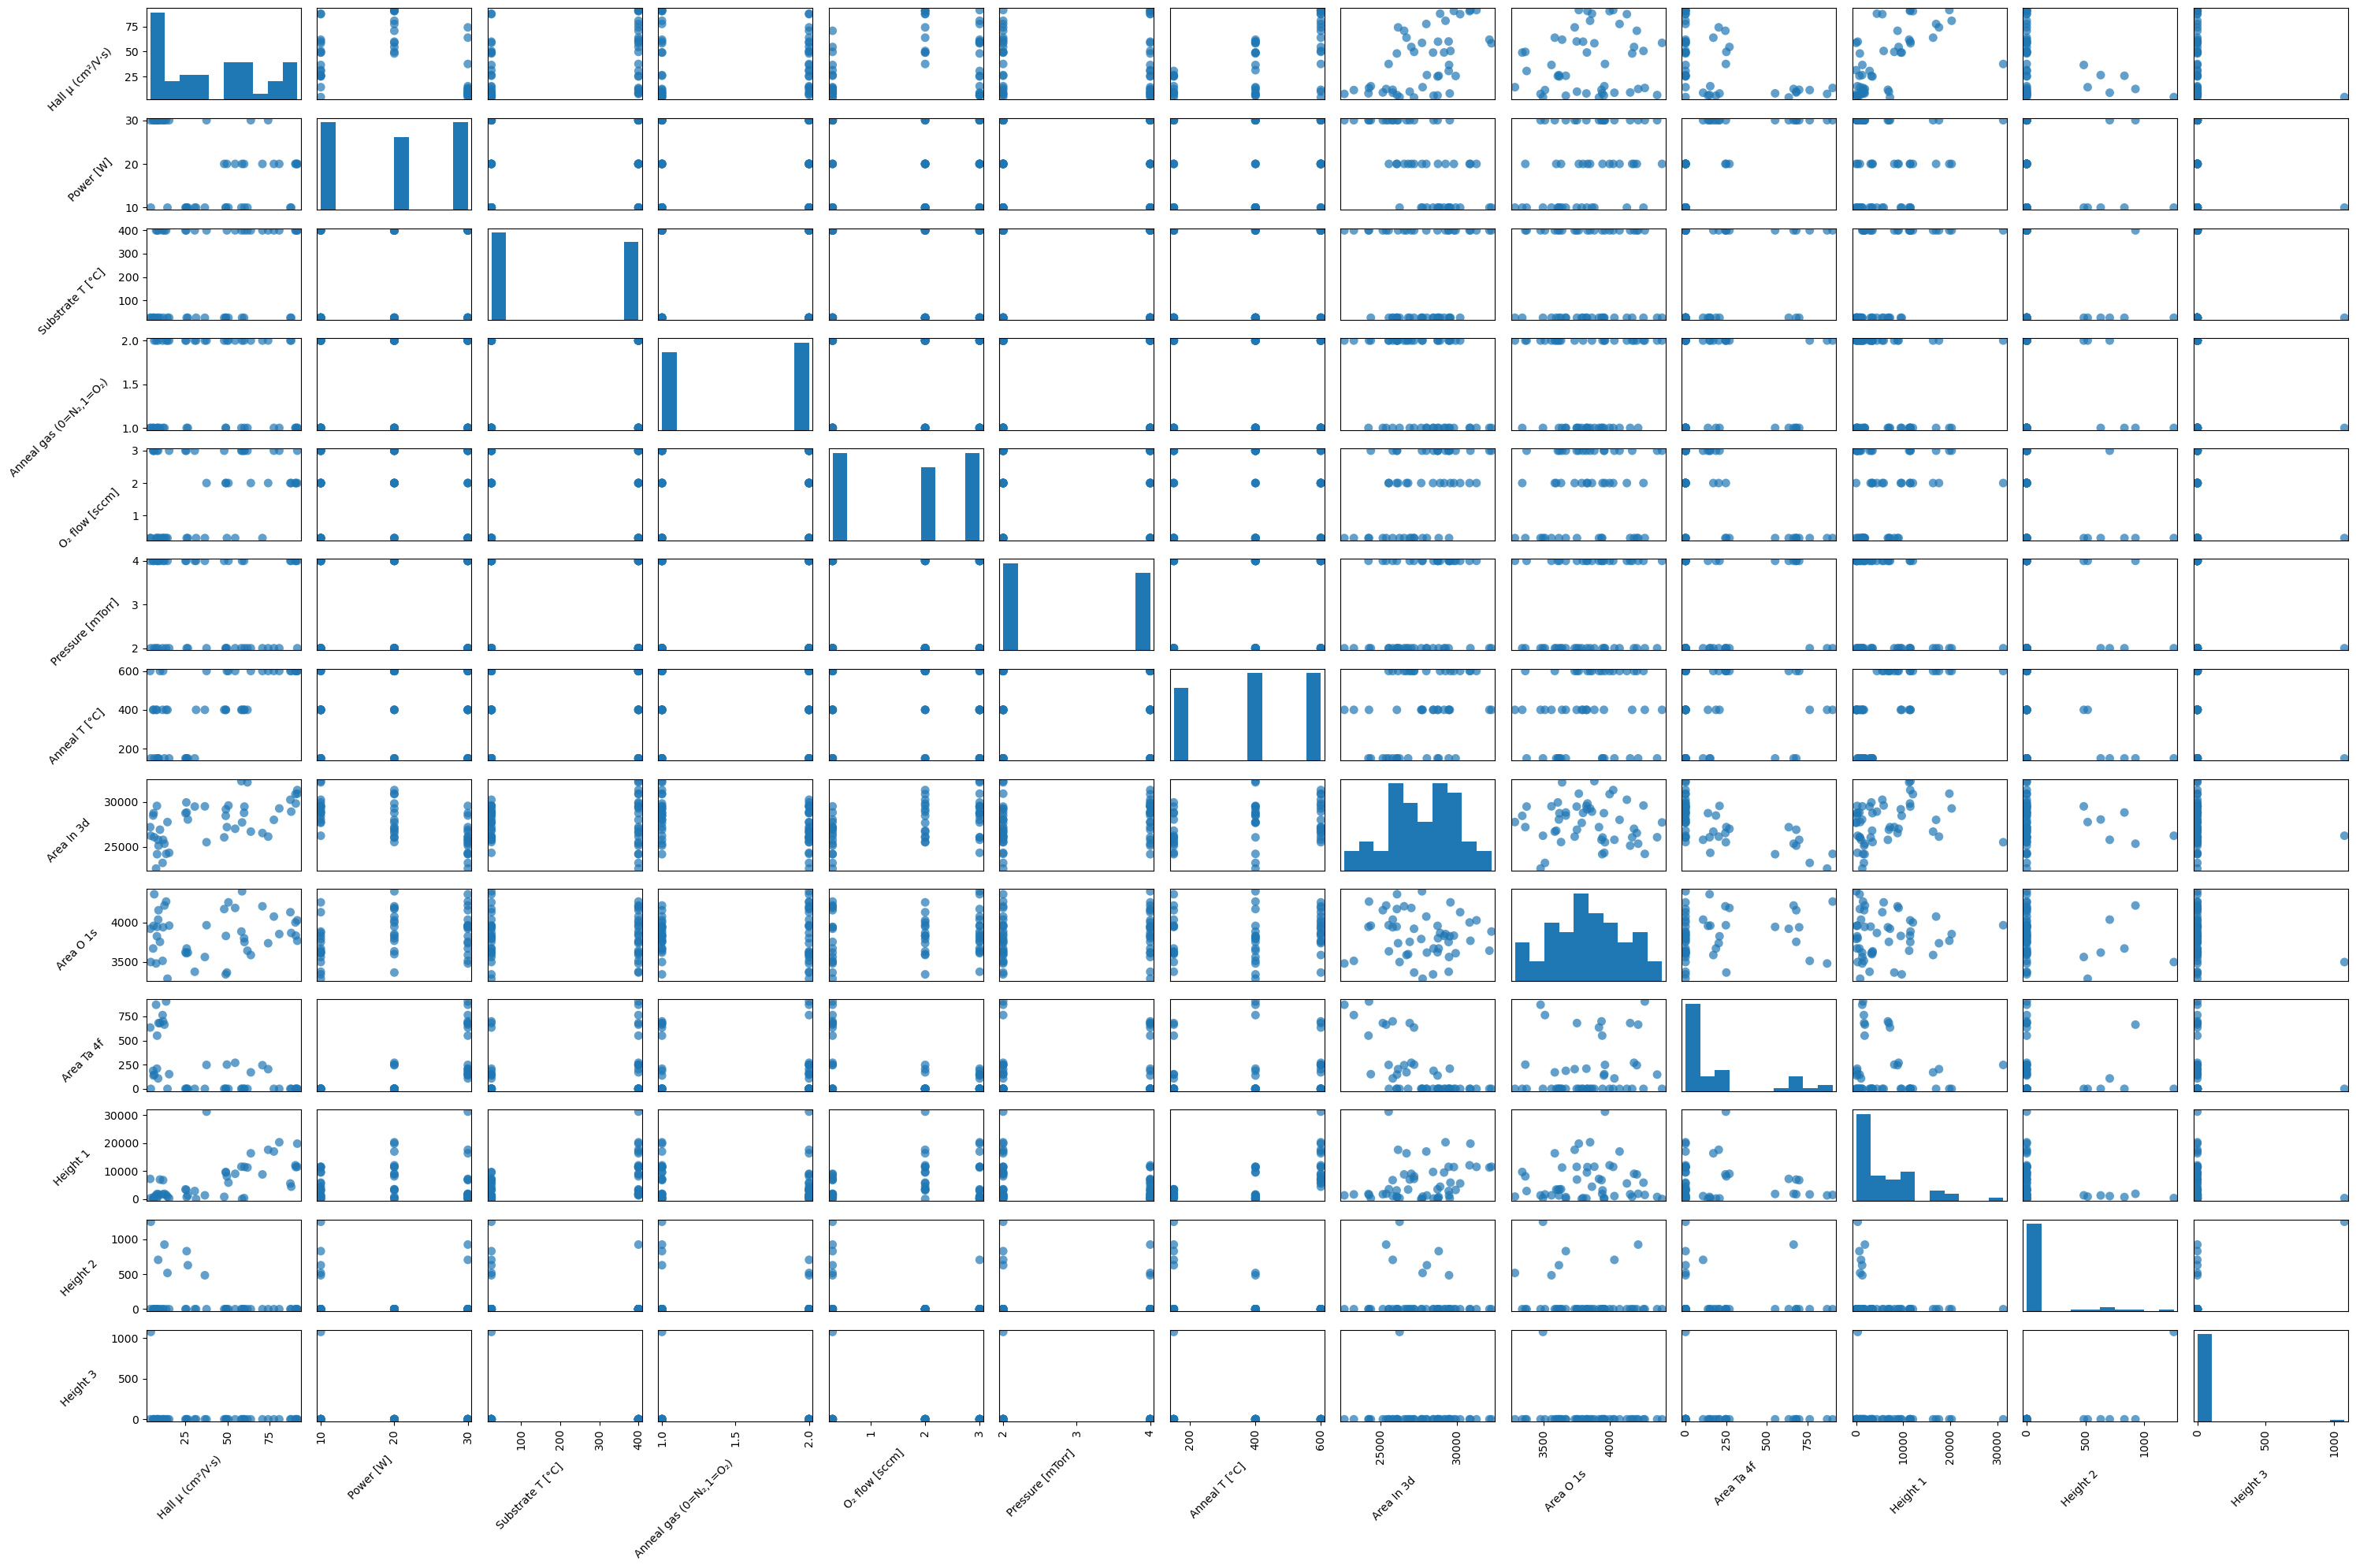

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# 1) name of your target
target_col = "Hall Mobility (cm^2/V·s)"

# 2) choose the predictors you care about (order after the target)
predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    # "In3d_p1", 
    # "In3d_p2", 
    # "O1s_p1", 
    # "Ta4f_p1", 
    # "Ta4f_p2",
    # "Peak01", 
    # "Peak02",
    # "Peak03", 
    "Height01",
    "Height02", 
    "Height03", 
    # "FWHM01", 
    # "FWHM02", 
    # "FWHM03",
]

# keep only those that actually exist in master_df
predictors = [c for c in predictors if c in master_df.columns]

# 3) put Hall mobility first, then predictors
cols_for_plot = [target_col] + predictors
df_plot = master_df[cols_for_plot].copy()

print("Columns in pair plot (in order):")
print(df_plot.columns.tolist())

# 3b) pretty labels (rename columns)
label_map = {
    "Hall Mobility (cm^2/V·s)": "Hall μ (cm²/V·s)",
    "Power (W)": "Power [W]",
    "Substrate Temp (°C)": "Substrate T [°C]",
    "Anneal Condition Num": "Anneal gas (0=N₂,1=O₂)",
    "O2 Flow (sccm)": "O₂ flow [sccm]",
    "Pressure (mTorr)": "Pressure [mTorr]",
    "Anneal Temp (°C)": "Anneal T [°C]",
    "Area_In3d": "Area In 3d",
    "Area_O1s": "Area O 1s",
    "Area_Ta4f": "Area Ta 4f",
    "Height01": "Height 1",
    "Height02": "Height 2",
    "Height03": "Height 3",
}

df_plot = df_plot.rename(columns=label_map)

# 4) make the scatter matrix
plt.figure(figsize=(30, 30))
axes = scatter_matrix(
    df_plot,
    diagonal="hist",
    alpha=0.7,
    figsize=(30, 20),
    s=250
)

show_labels = True  # set to False to hide everything

for ax in axes.flatten():
    # tick number size (leave numbers horizontal)
    ax.tick_params(axis="both", labelsize=10)
    
    if show_labels:
        # rotate X and Y AXIS LABELS (titles), not tick numbers
        xlab = ax.get_xlabel()
        ylab = ax.get_ylabel()
        ax.set_xlabel(xlab, rotation=45, ha="right", labelpad=10)
        ax.set_ylabel(ylab, rotation=45, ha="right", labelpad=10)
    else:
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_xlabel("")
        ax.set_ylabel("")

plt.tight_layout()
plt.show()

### main effect

Predictors used: ['Power (W)', 'Substrate Temp (°C)', 'Anneal Condition Num', 'O2 Flow (sccm)', 'Pressure (mTorr)', 'Anneal Temp (°C)', 'Area_In3d', 'Area_O1s', 'Area_Ta4f', 'Height01', 'Height02', 'Height03']


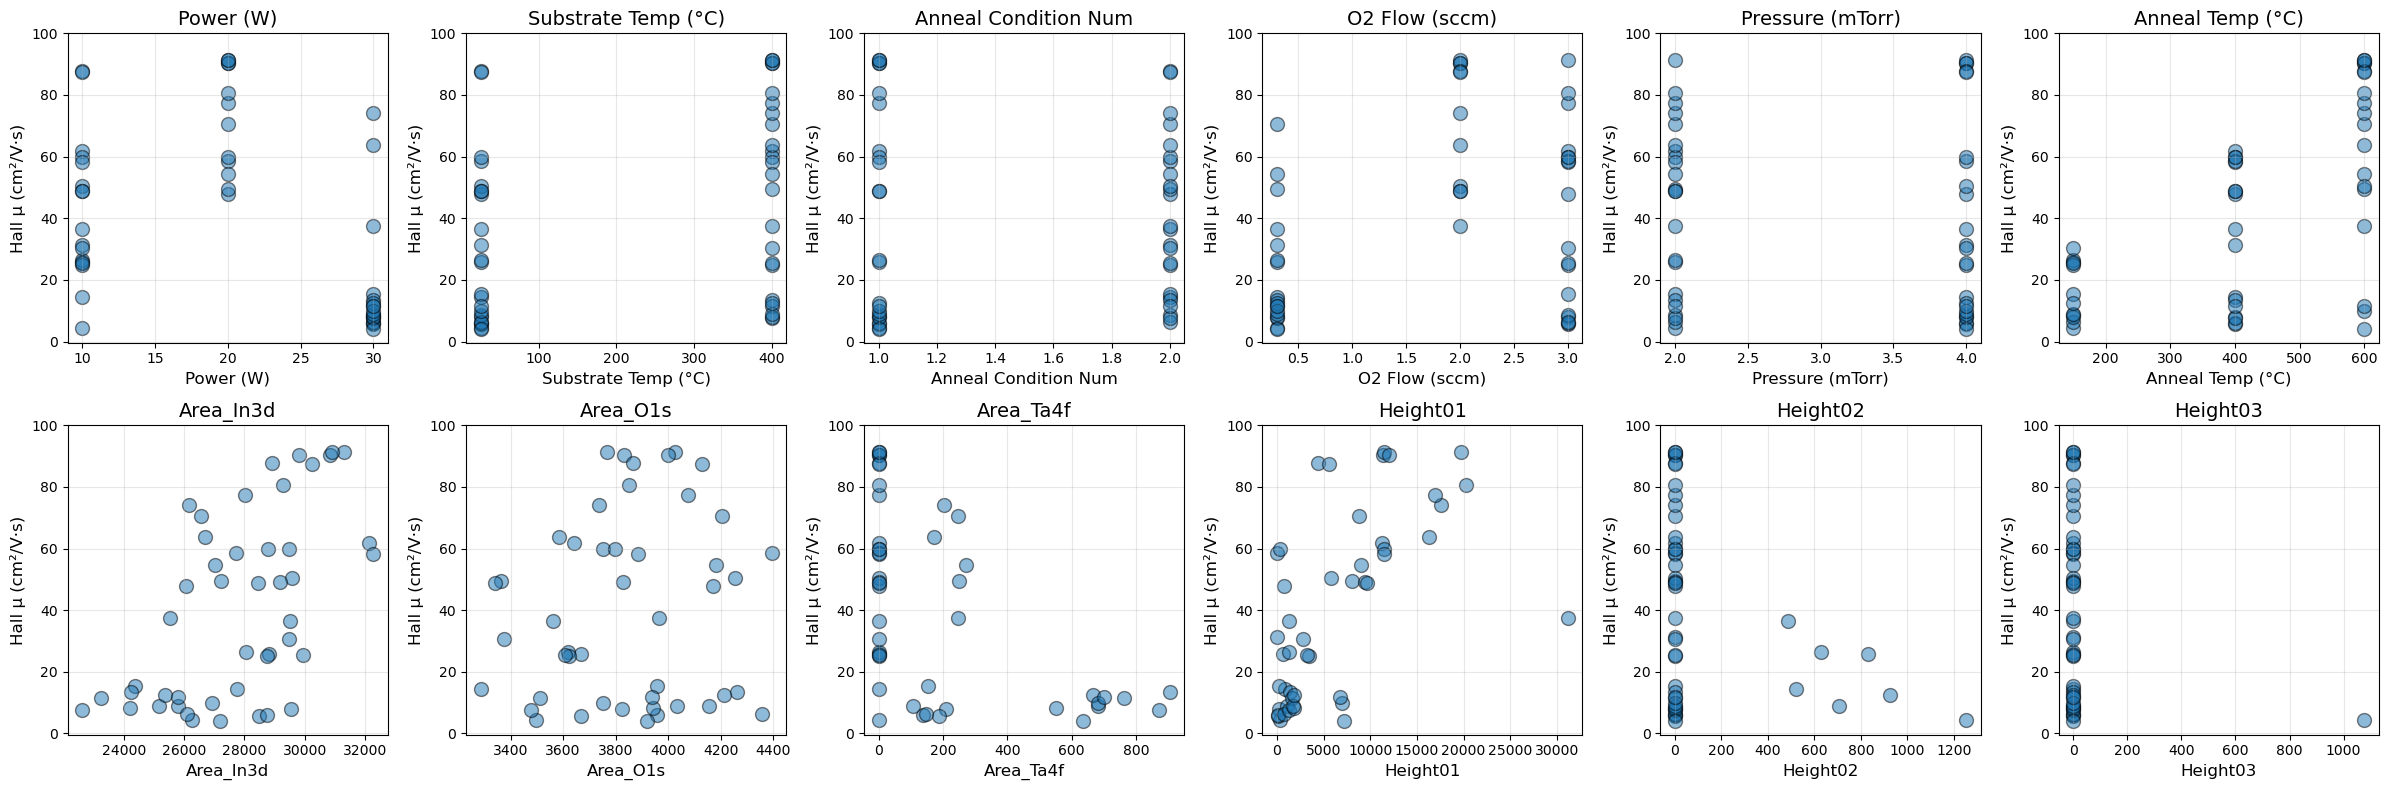

In [10]:
import numpy as np
import matplotlib.pyplot as plt

target_col = "Hall Mobility (cm^2/V·s)"

predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",
    "Anneal Condition",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Height01",
    "Height02",
    "Height03",
]

# keep only predictors that exist and are numeric
predictors = [
    c for c in predictors
    if c in master_df.columns and np.issubdtype(master_df[c].dtype, np.number)
]

print("Predictors used:", predictors)

n_rows, n_cols = 2, 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 8))
axes = axes.flatten()

for ax, col in zip(axes, predictors):
    x = master_df[col].values
    y = master_df[target_col].values

    # scatter
    ax.scatter(x, y, s=100, alpha=0.5, edgecolor="k")

    # optional: simple linear fit line if enough points
    # if len(x[~np.isnan(x)]) > 2:
    #     try:
    #         coeffs = np.polyfit(x[~np.isnan(x)], y[~np.isnan(x)], 1)
    #         x_line = np.linspace(np.nanmin(x), np.nanmax(x), 50)
    #         y_line = coeffs[0] * x_line + coeffs[1]
    #         ax.plot(x_line, y_line, linewidth=2)
    #     except Exception:
    #         pass

    ax.set_title(col, fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel("Hall μ (cm²/V·s)", fontsize=12)
    ax.set_ylim(top=100)
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(alpha=0.3)

# hide any unused axes (in case < 12 predictors)
for i in range(len(predictors), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


## Ridz Visualization

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


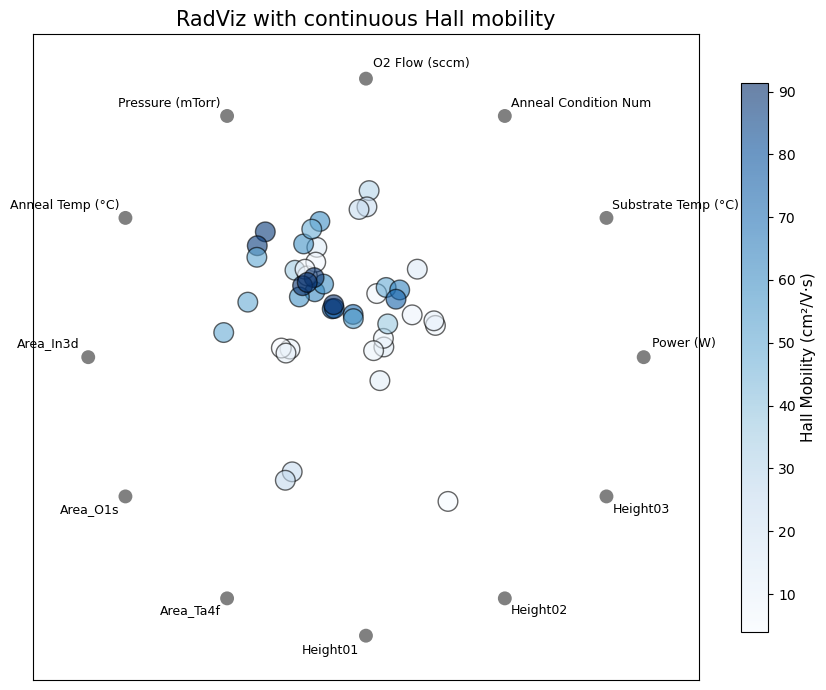

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import radviz

target_col = "Hall Mobility (cm^2/V·s)"

predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Height01",
    "Height02",
    "Height03",
]

predictors = [
    c for c in predictors
    if c in master_df.columns and np.issubdtype(master_df[c].dtype, np.number)
]

cols_for_radviz = predictors + [target_col]
df_radviz = master_df[cols_for_radviz].dropna().copy()

df_radviz["HallMobilityBin"] = pd.qcut(
    df_radviz[target_col],
    q=3,
    labels=["Low μ", "Med μ", "High μ"]
)

df_radviz_plot = df_radviz[predictors + ["HallMobilityBin"]].copy()

# jitter
np.random.seed(0)
jitter_strength = 0.02
for col in predictors:
    vals = df_radviz_plot[col].to_numpy(dtype=float)
    col_range = vals.max() - vals.min()
    if col_range == 0:
        continue
    noise = np.random.normal(0.0, jitter_strength * col_range, size=vals.shape)
    df_radviz_plot[col] = vals + noise

fig, ax = plt.subplots(figsize=(9, 7))

# 1) draw the radviz frame/anchors
radviz(df_radviz_plot, class_column="HallMobilityBin", ax=ax)

# 2) remove the legend
leg = ax.get_legend()
if leg is not None:
    leg.remove()

# 3) fade/remove the class points that pandas drew
# ax.collections are the scatter groups from radviz
for coll in ax.collections:
    coll.set_alpha(0)      # or coll.set_visible(False)

ax.set_title("RadViz with continuous Hall mobility", fontsize=15)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

# pull labels in
for txt in ax.texts:
    x, y = txt.get_position()
    r = np.sqrt(x**2 + y**2)
    if r > 0:
        new_r = 1.03
        scale = new_r / r
        txt.set_position((x * scale, y * scale))
        txt.set_fontsize(9)

# ======================================================
# overlay your own scatter with colorbar
# ======================================================
X = df_radviz_plot[predictors].to_numpy(dtype=float)

X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_range = X_max - X_min
X_range[X_range == 0] = 1.0
X_norm = (X - X_min) / X_range

n_samples, n_features = X_norm.shape
angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False)
anchors = np.stack([np.cos(angles), np.sin(angles)], axis=1)

den = X_norm.sum(axis=1)
den[den == 0] = 1e-12
coords = (X_norm @ anchors) / den[:, None]

x_rv = coords[:, 0]
y_rv = coords[:, 1]

hall_vals = df_radviz[target_col].to_numpy(dtype=float)

sc = ax.scatter(
    x_rv,
    y_rv,
    c=hall_vals,
    cmap="Blues",
    s=200,
    alpha=0.6,
    edgecolor="k",
)

cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label("Hall Mobility (cm²/V·s)", fontsize=11)

plt.tight_layout()
plt.show()


# Linear Regression Model (preliminar)

## Model including all predictors (preliminar)

Formula used:
Q('Hall Mobility (cm^2/V·s)') ~ Q('Power (W)') + Q('Substrate Temp (°C)') + Q('Anneal Condition Num') + Q('O2 Flow (sccm)') + Q('Pressure (mTorr)') + Q('Anneal Temp (°C)')
                                  OLS Regression Results                                 
Dep. Variable:     Q('Hall Mobility (cm^2/V·s)')   R-squared:                       0.749
Model:                                       OLS   Adj. R-squared:                  0.710
Method:                            Least Squares   F-statistic:                     19.36
Date:                           Tue, 28 Apr 2026   Prob (F-statistic):           2.58e-10
Time:                                   06:58:44   Log-Likelihood:                -189.41
No. Observations:                             46   AIC:                             392.8
Df Residuals:                                 39   BIC:                             405.6
Df Model:                                      6                                         
Cova

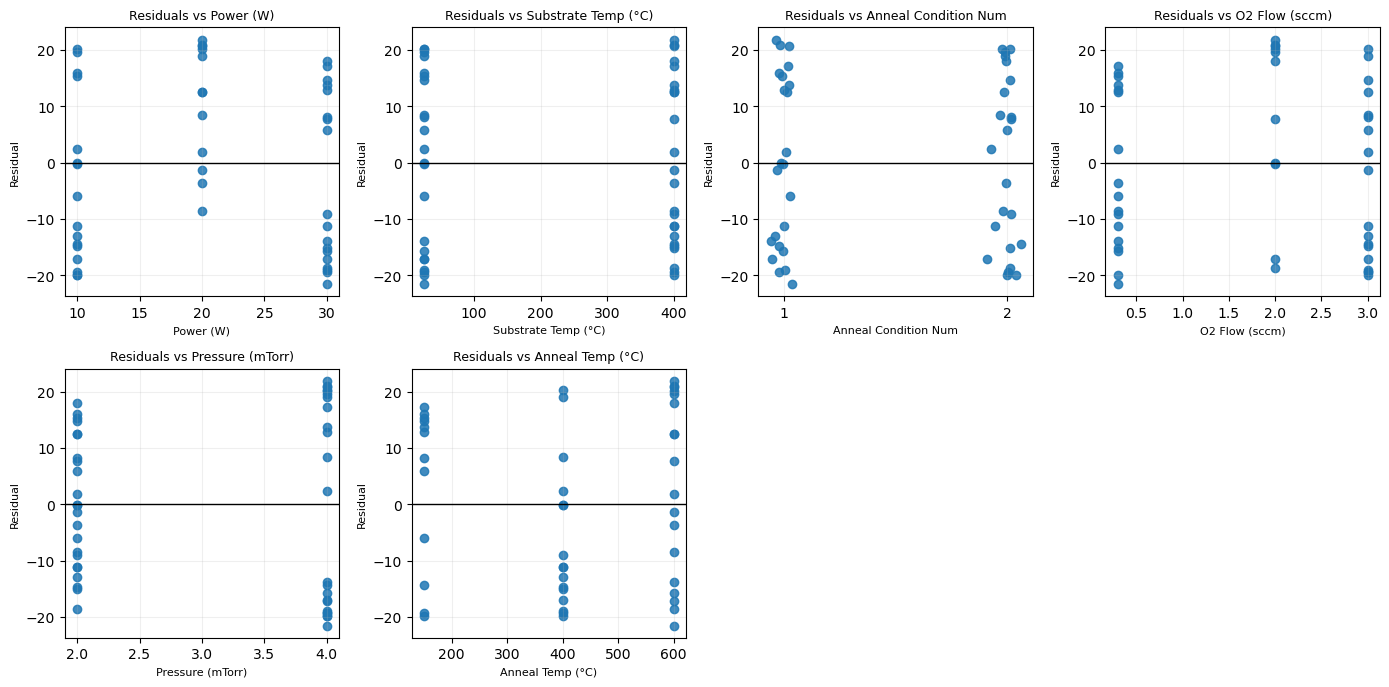

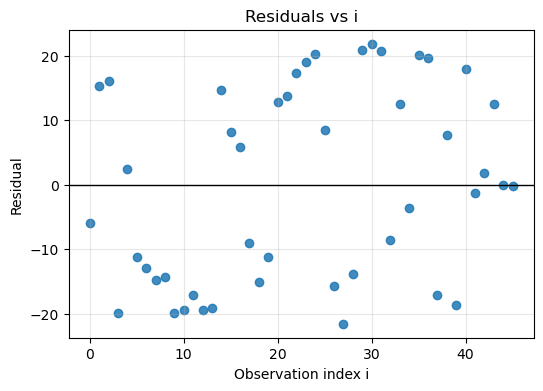

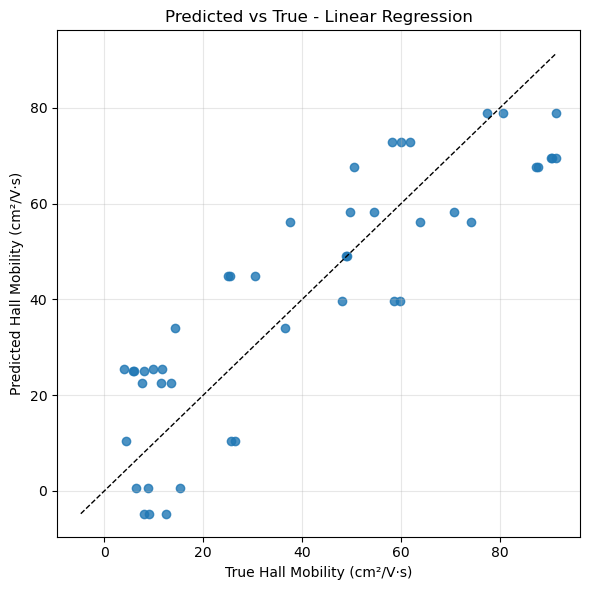

In [12]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# If you still have A, B, C, D, E, F from earlier Taguchi code, uncomment and run once:
# del A, B, C, D, E, F

predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",   # categorical
    #"Anneal Condition",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Height01",
    "Height02",
    "Height03",
]
target = "Hall Mobility (cm^2/V·s)"

# ----------------------------------
# Choose predictors to exclude
# ----------------------------------
# Put any names from `predictors` here to remove them from the model
exclude_for_model = {
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Height01",
    "Height02",
    "Height03",
    #"Anneal Condition Num",
}

# drop rows with missing data in any of these
df_use = master_df[predictors + [target]].dropna()

# ----------------------------------
# Build formula programmatically
# ----------------------------------
terms = []
for col in predictors:
    if col in exclude_for_model:
        continue

    if col == "Anneal Condition":
        # categorical
        terms.append("C(Q('Anneal Condition'))")
    else:
        terms.append(f"Q('{col}')")

rhs = " + ".join(terms)
formula = f"Q('{target}') ~ {rhs}"

print("Formula used:")
print(formula)

model = smf.ols(formula=formula, data=df_use).fit()
print(model.summary())

# =========================
# Residual plots per predictor
# =========================

resid = model.resid

# If you want residuals for all predictors (even excluded) use:
# pred_cols = predictors
# If you want residuals only for predictors included in the model, use:
pred_cols = [col for col in predictors if col not in exclude_for_model]

n = len(pred_cols)
n_rows = 3
n_cols = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, pred_cols):
    x = df_use[col].values
    y = resid.values

    if col == "Anneal Condition Num":
        # jitter for categorical
        x_plot = x.astype(float) + np.random.normal(0, 0.03, size=len(x))
        ax.scatter(x_plot, y, alpha=0.85)
        ax.set_xticks(sorted(np.unique(x)))
    else:
        ax.scatter(x, y, alpha=0.85)

    ax.axhline(0, color="k", linewidth=1)
    ax.set_title(f"Residuals vs {col}", fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel("Residual", fontsize=8)
    ax.grid(alpha=0.2)

# hide unused axes if any
for i in range(len(pred_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# =========================
# Residuals vs index (like the slide)
# =========================
plt.figure(figsize=(6, 4))
plt.scatter(np.arange(len(resid)), resid, alpha=0.85)
plt.axhline(0, color="k", linewidth=1)
plt.xlabel("Observation index i")
plt.ylabel("Residual")
plt.title("Residuals vs i")
plt.grid(alpha=0.3)
plt.show()

summary = model.summary2()

# Extract main tables
coef_table = summary.tables[1]    # coefficients table
info_table = summary.tables[0]    # model info (R^2, etc.)

# Save them into Excel (different sheets)
with pd.ExcelWriter("output/ols_model_summary.xlsx") as writer:
    info_table.to_excel(writer, sheet_name="Model_Info")
    coef_table.to_excel(writer, sheet_name="Coefficients")


################################
# Get true and predicted
################################

y_true = df_use[target].values               # true Hall Mobility
y_pred = model.fittedvalues.values           # or model.predict(df_use)
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.8)
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "k--", linewidth=1)
plt.xlabel("True Hall Mobility (cm²/V·s)")
plt.ylabel("Predicted Hall Mobility (cm²/V·s)")
plt.title("Predicted vs True - Linear Regression")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [13]:
# print(model.params.index)
# print(sorted(df_use["Anneal Condition Num"].unique()))


In [14]:
from statsmodels.stats.anova import anova_lm

# =========================
# ANOVA table (Type II) + clean names
# =========================

def clean_term_name(term: str) -> str:
    """
    Remove patsy's Q(...) and C(Q(...)) wrappers,
    keeping the original variable name (with units).
    """
    # e.g. "Q('Power (W)')" -> "Power (W)"
    if term.startswith("Q('") and term.endswith("')"):
        return term[3:-2]

    # e.g. "C(Q('Anneal Condition Num'))" -> "Anneal Condition Num"
    if term.startswith("C(Q('") and term.endswith("'))"):
        return term[5:-3]

    # leave anything else as is (e.g. "Residual")
    return term

anova_table = anova_lm(model, typ=2)

# apply cleaning to the index (row names)
anova_table.index = [clean_term_name(t) for t in anova_table.index]

print("\n=== ANOVA table (Type II, cleaned names) ===")
print(anova_table)
anova_table.to_excel("output/anova_test.xlsx")



=== ANOVA table (Type II, cleaned names) ===
                            sum_sq    df          F        PR(>F)
Power (W)              7234.751592   1.0  27.777312  5.318226e-06
Substrate Temp (°C)    2775.522744   1.0  10.656422  2.287157e-03
Anneal Condition Num      1.714171   1.0   0.006581  9.357566e-01
O2 Flow (sccm)         3571.788854   1.0  13.713628  6.576478e-04
Pressure (mTorr)         33.999446   1.0   0.130538  7.198244e-01
Anneal Temp (°C)      15306.606355   1.0  58.768623  2.656087e-09
Residual              10157.761386  39.0        NaN           NaN


## manually selected model with only significant factors

Formula used:
Q('Hall Mobility (cm^2/V·s)') ~ Q('Power (W)') + Q('Substrate Temp (°C)') + Q('O2 Flow (sccm)') + Q('Pressure (mTorr)') + Q('Anneal Temp (°C)') + C(Q('Anneal Condition Num')) + Q('Substrate Temp (°C)'):Q('O2 Flow (sccm)') + Q('Power (W)'):Q('O2 Flow (sccm)') + Q('Power (W)'):C(Q('Anneal Condition Num'))
                                  OLS Regression Results                                 
Dep. Variable:     Q('Hall Mobility (cm^2/V·s)')   R-squared:                       0.818
Model:                                       OLS   Adj. R-squared:                  0.773
Method:                            Least Squares   F-statistic:                     18.45
Date:                           Tue, 28 Apr 2026   Prob (F-statistic):           3.75e-11
Time:                                   06:58:45   Log-Likelihood:                -185.51
No. Observations:                             47   AIC:                             391.0
Df Residuals:                                 37   

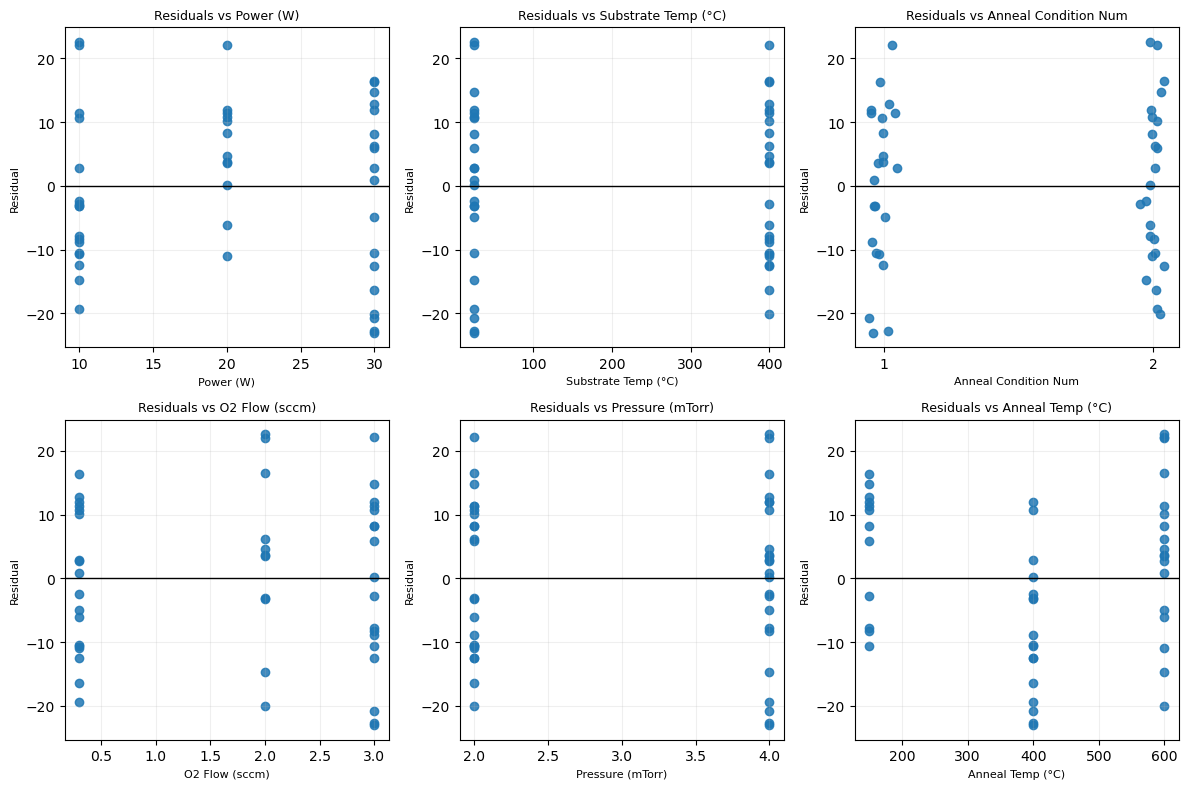

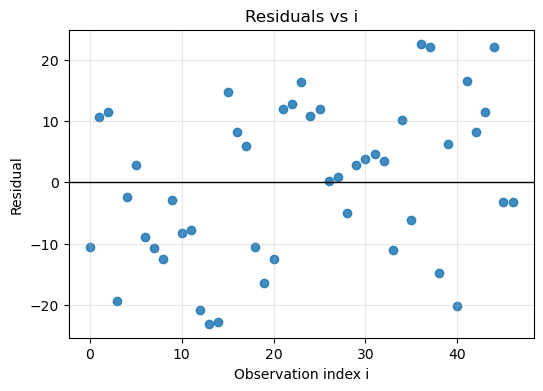

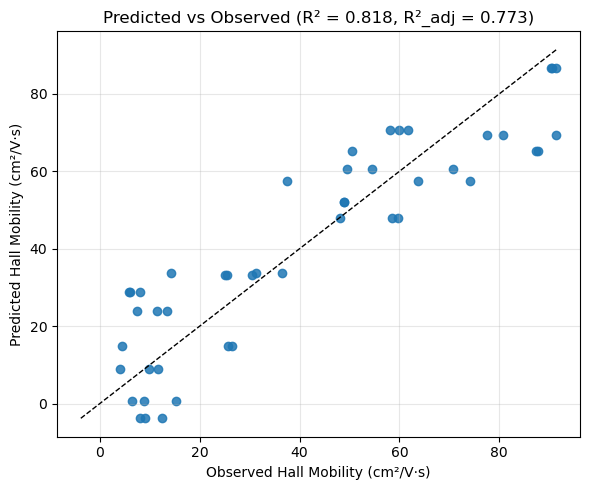

In [15]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
#del A, B, C, D, E, F    

target = "Hall Mobility (cm^2/V·s)"

# ----------------------------------
# Process predictors used in ANOVA
# ----------------------------------
process_predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",   # categorical
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
]

# Data subset: only these columns for now
df_use = master_df[process_predictors + [target]].dropna()

# ----------------------------------
# Build formula with:
#   - all main effects
#   - only selected interaction terms
# ----------------------------------

# main effects
main_terms = [
    "Q('Power (W)')",
    "Q('Substrate Temp (°C)')",
    "Q('O2 Flow (sccm)')",
    "Q('Pressure (mTorr)')",
    "Q('Anneal Temp (°C)')",
    "C(Q('Anneal Condition Num'))",   # categorical
]

# interaction terms you highlighted in the ANOVA
interaction_terms = [
    # Substrate Temp × O2 Flow
    "Q('Substrate Temp (°C)'):Q('O2 Flow (sccm)')",

    # Power × O2 Flow
    "Q('Power (W)'):Q('O2 Flow (sccm)')",

    # Power × Anneal Condition Num (categorical)
    "Q('Power (W)'):C(Q('Anneal Condition Num'))",
]


rhs = " + ".join(main_terms + interaction_terms)
formula = f"Q('{target}') ~ {rhs}"

print("Formula used:")
print(formula)

model = smf.ols(formula=formula, data=df_use).fit()
print(model.summary())

# =========================
# Residual plots per predictor (main effects only)
# =========================
resid = model.resid
pred_cols = process_predictors  # only the six process factors

n = len(pred_cols)
n_rows = 2
n_cols = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, pred_cols):
    x = df_use[col].values
    y = resid.values

    if col == "Anneal Condition Num":
        # jitter for categorical
        x_plot = x.astype(float) + np.random.normal(0, 0.03, size=len(x))
        ax.scatter(x_plot, y, alpha=0.85)
        ax.set_xticks(sorted(np.unique(x)))
    else:
        ax.scatter(x, y, alpha=0.85)

    ax.axhline(0, color="k", linewidth=1)
    ax.set_title(f"Residuals vs {col}", fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel("Residual", fontsize=8)
    ax.grid(alpha=0.2)

# hide unused axes if any
for i in range(len(pred_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# =========================
# Residuals vs index
# =========================
plt.figure(figsize=(6, 4))
plt.scatter(np.arange(len(resid)), resid, alpha=0.85)
plt.axhline(0, color="k", linewidth=1)
plt.xlabel("Observation index i")
plt.ylabel("Residual")
plt.title("Residuals vs i")
plt.grid(alpha=0.3)
plt.show()

# =========================
# Predicted vs observed plot
# =========================
y_true = df_use[target]
y_pred = model.fittedvalues

plt.figure(figsize=(6, 5))
plt.scatter(y_true, y_pred, alpha=0.85)
plt.xlabel("Observed Hall Mobility (cm²/V·s)")
plt.ylabel("Predicted Hall Mobility (cm²/V·s)")
plt.title("Predicted vs Observed")
r2 = model.rsquared
r2_adj = model.rsquared_adj
plt.title(f"Predicted vs Observed (R² = {r2:.3f}, R²_adj = {r2_adj:.3f})")

# 45-degree reference line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "k--", linewidth=1)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



# Interaction terms and anova

In here I am including the main effects (6) and the interaction terms giving a total of 21 coefficients

In [2]:
# import numpy as np
# import pandas as pd
# import statsmodels.formula.api as smf
# from statsmodels.stats.anova import anova_lm
# import matplotlib.pyplot as plt

# predictors = [
#     "Power (W)",
#     "Substrate Temp (°C)",
#     "Anneal Condition Num",   # categorical
#     "O2 Flow (sccm)",
#     "Pressure (mTorr)",
#     "Anneal Temp (°C)",
# ]
# target = "Hall Mobility (cm^2/V·s)"

# df_use = master_df[predictors + [target]].dropna()

# # -------------------------
# # Build formula with ALL 2-way interactions
# # -------------------------
# rhs = (
#     "Q('Power (W)')"
#     " + Q('Substrate Temp (°C)')"
#     " + C(Q('Anneal Condition Num'))"
#     " + Q('O2 Flow (sccm)')"
#     " + Q('Pressure (mTorr)')"
#     " + Q('Anneal Temp (°C)')"
# )

# # ** 2 means: include all main effects and all 2-way interactions
# formula = f"Q('Hall Mobility (cm^2/V·s)') ~ ({rhs}) ** 2"
# print("Formula:", formula)

# # -------------------------
# # Fit model
# # -------------------------
# model = smf.ols(formula=formula, data=df_use).fit()
# print(model.summary())

# # -------------------------
# # ANOVA (Type II) with cleaned names
# # -------------------------
# def _clean_single(term: str) -> str:
#     term = term.strip()
#     if term.startswith("Q('") and term.endswith("')"):
#         return term[3:-2]      # drop Q('  ')
#     if term.startswith("C(Q('") and term.endswith("'))"):
#         return term[5:-3]      # drop C(Q('  '))
#     return term

# def clean_term_name(term: str) -> str:
#     # Handle interactions like "Q('Power (W)'):Q('Substrate Temp (°C)')"
#     if ":" in term:
#         parts = term.split(":")
#         clean_parts = [_clean_single(p) for p in parts]
#         return " × ".join(clean_parts)  # nicer symbol for interaction
#     else:
#         return _clean_single(term)

# anova_table = anova_lm(model, typ=2)
# anova_table.index = [clean_term_name(t) for t in anova_table.index]

# print("\n=== ANOVA table (Type II, with all 2-way interactions, cleaned names) ===")
# print(anova_table)

# # If you want to export:
# anova_table.to_excel("output/anova_all_2way_interactions.xlsx")


In [3]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pred_vs_observed(model, df, target_col, title_prefix="Predicted vs Observed"):
    """
    Scatter plot of predicted vs observed values for a fitted statsmodels OLS model.

    Parameters
    ----------
    model : statsmodels.regression.linear_model.RegressionResultsWrapper
        Fitted OLS model (result of smf.ols(...).fit()).
    df : pandas.DataFrame
        Data used for prediction (can be training data or new data).
    target_col : str
        Name of the column in df that contains the true response values.
    title_prefix : str, optional
        Text to put at the beginning of the plot title.
    """
    # True values and predictions
    y_true = df[target_col]
    y_pred = model.predict(df)

    plt.figure(figsize=(5, 5))
    plt.scatter(y_true, y_pred, alpha=0.85)

    # 45-degree reference line
    lims = [
        np.nanmin([y_true.min(), y_pred.min()]),
        np.nanmax([y_true.max(), y_pred.max()])
    ]
    plt.plot(lims, lims, linestyle="--", linewidth=1)
    plt.xlim(lims)
    plt.ylim(lims)

    # Handle R^2 if available (for new-data predictions it is still the training R^2)
    try:
        r2 = model.rsquared
        r2_adj = model.rsquared_adj
        title = f"{title_prefix} (R² = {r2:.3f}, R_adj = {r2_adj:.3f})"
    except AttributeError:
        title = title_prefix

    plt.xlabel("Observed Hall Mobility (cm²/V·s)")
    plt.ylabel("Predicted Hall Mobility (cm²/V·s)")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_pred_vs_observed(model, df_use, target_col=target)

NameError: name 'model' is not defined

## Calculating cooks distance for outlier point

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import OLSInfluence

infl = OLSInfluence(model)

h = infl.hat_matrix_diag                    # leverage h_ii
r_std = infl.resid_studentized_internal     # standardized residuals r_i
r_ = infl.resid
p_eff = int(model.df_model) + 1             # effective #params incl. intercept

# manual Cook's D using standardized residuals
cooks_manual = (r_std**2 * h) / (p_eff * (1.0 - h))

# statsmodels Cook's D for comparison
cooks_sm, _ = infl.cooks_distance

X = model.model.exog
resid = model.resid
h = infl.hat_matrix_diag

n = len(resid)
p_eff = int(model.df_model) + 1          # same as above
df_resid = model.df_resid               # effective residual df
MSE = np.sum(resid**2) / df_resid       # > 0

cooks_manual2 = (resid**2 / (p_eff * MSE)) * (h / (1.0 - h)**2)


compare = pd.DataFrame({
    "cooks_manual": cooks_manual,
    "cooks_statsmodels": cooks_sm,
})
print(compare)


    cooks_manual  cooks_statsmodels
0       0.022925           0.022925
1       0.023378           0.023378
2       0.026536           0.026536
3       0.061313           0.061313
4       0.000928           0.000928
5       0.001293           0.001293
6       0.009340           0.009340
7       0.013519           0.013519
8       0.018469           0.018469
9       0.001886           0.001886
10      0.016409           0.016409
11      0.014496           0.014496
12      0.072829           0.072829
13      0.089445           0.089445
14      0.087208           0.087208
15      0.037026           0.037026
16      0.011459           0.011459
17      0.005892           0.005892
18      0.013753           0.013753
19      0.033888           0.033888
20      0.019829           0.019829
21      0.030305           0.030305
22      0.034883           0.034883
23      0.056556           0.056556
24      0.013364           0.013364
25      0.016510           0.016510
26      0.000003           0

4/n cutoff for Cook's distance: 0.0851

Points with Cook's D > 4/n:
    idx  leverage  std_resid   cooks_d
13   13   0.20979  -1.835509  0.089445
14   14   0.20979  -1.812408  0.087208


/tmp/ipykernel_2496411/3475557036.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for region, grp in diag.groupby("region"):


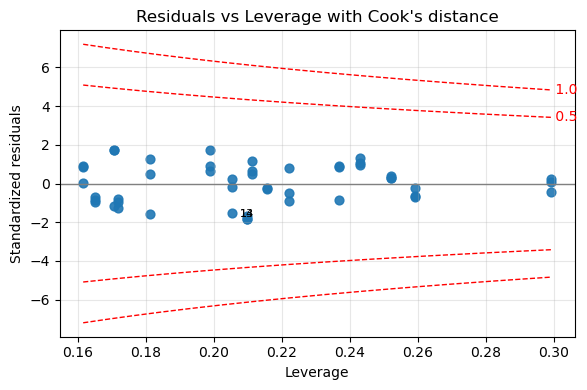

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import OLSInfluence

# ---------------------------------
# 1) Influence measures
# ---------------------------------
infl = OLSInfluence(model)
leverage  = infl.hat_matrix_diag
std_resid = infl.resid_studentized_internal
cooks_d, _ = infl.cooks_distance

# k used in Cook's D formula inside statsmodels
k = model.model.exog.shape[1]

# sample size
n = len(df_use)
cutoff_4_over_n = 4 / n
print(f"4/n cutoff for Cook's distance: {cutoff_4_over_n:.4f}")

# ---------------------------------
# 2) Build diagnostics table
# ---------------------------------
diag = pd.DataFrame({
    "idx": np.arange(len(df_use)),
    "leverage": leverage,
    "std_resid": std_resid,
    "cooks_d": cooks_d,
})

# classify by Cook's D
diag["region"] = pd.cut(
    diag["cooks_d"],
    bins=[-np.inf, 0.5, 1.0, np.inf],
    labels=["D < 0.5", "0.5 <= D < 1.0", "D >= 1.0"],
)

# flag observations above 4/n
diag["above_4_over_n"] = diag["cooks_d"] > cutoff_4_over_n

print("\nPoints with Cook's D > 4/n:")
print(diag.loc[diag["above_4_over_n"], ["idx", "leverage", "std_resid", "cooks_d"]])

# ---------------------------------
# 3) Plot: Residuals vs Leverage with Cook's contours
# ---------------------------------
fig, ax = plt.subplots(figsize=(6, 4))

color_map = {
    "D < 0.5": "tab:blue",
    "0.5 <= D < 1.0": "tab:orange",
    "D >= 1.0": "tab:red",
}

for region, grp in diag.groupby("region"):
    ax.scatter(
        grp["leverage"],
        grp["std_resid"],
        label=region,
        alpha=0.9,
        s=40,
        color=color_map[region],
    )

# optionally label the 4/n points on the plot
for _, row in diag[diag["above_4_over_n"]].iterrows():
    ax.text(row["leverage"], row["std_resid"], str(int(row["idx"])),
            fontsize=8, ha="center", va="bottom")

ax.set_xlabel("Leverage")
ax.set_ylabel("Standardized residuals")
ax.set_title("Residuals vs Leverage with Cook's distance")

# Cook's distance contours that match statsmodels
lev_grid = np.linspace(leverage.min(), leverage.max(), 200)
lev_grid = lev_grid[(lev_grid > 0) & (lev_grid < 1)]

for d in [0.5, 1.0]:
    r_grid = np.sqrt(d * k * (1 - lev_grid) / lev_grid)
    ax.plot(lev_grid,  r_grid, "r--", linewidth=1)
    ax.plot(lev_grid, -r_grid, "r--", linewidth=1)
    ax.text(lev_grid[-1], r_grid[-1], f" {d}", color="r", va="center")

ax.axhline(0, color="grey", lw=1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Coefficient of variation without this point

Rows dropped: 0


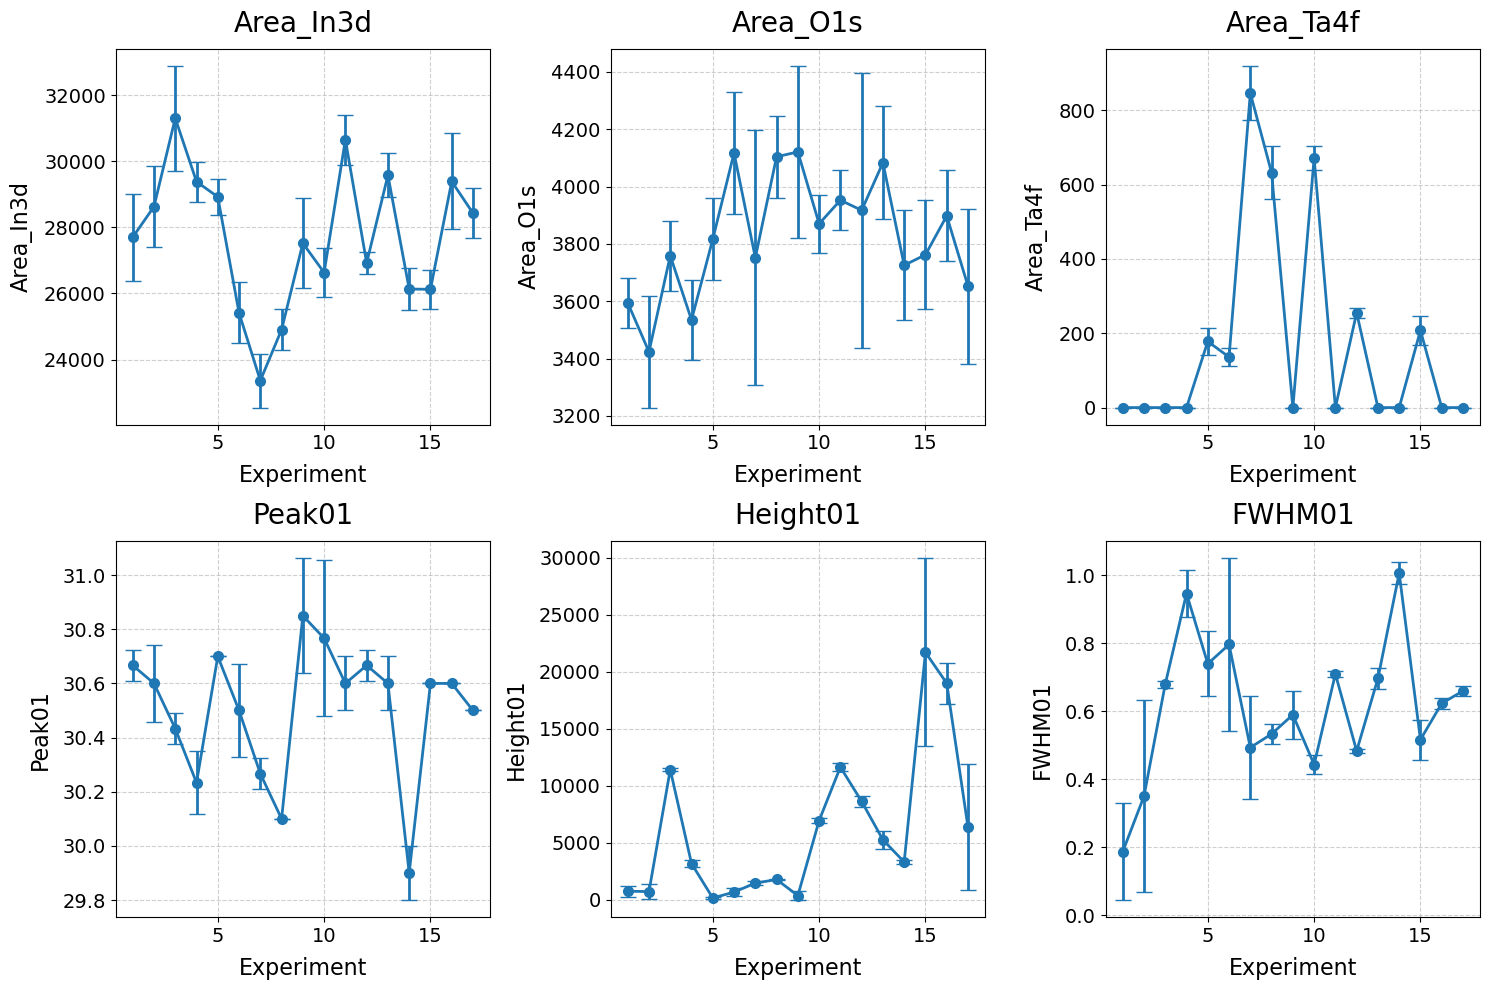

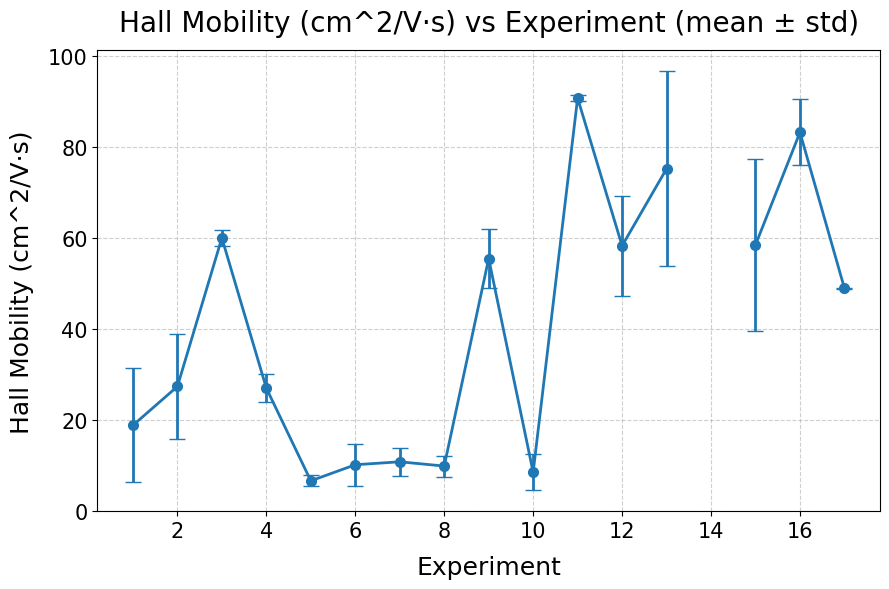

Coefficient of variation per experiment (percent):


,CV_%_Area_In3d,CV_%_Area_O1s,CV_%_Area_Ta4f,CV_%_Peak01,CV_%_Height01,CV_%_FWHM01,CV_%_Hall Mobility (cm^2/V·s)
Experiment,,,,,,,
1,4.762,2.454,nan,0.188,61.957,76.202,66.396
2,4.295,5.680,nan,0.462,92.257,80.812,42.427
3,5.074,3.237,nan,0.190,1.339,1.471,3.000
4,2.043,3.940,nan,0.382,9.652,7.190,11.264
5,1.916,3.764,20.419,0.000,34.032,12.891,18.470
6,3.639,5.132,17.890,0.568,56.718,31.862,45.191
7,3.497,11.835,8.691,0.191,11.845,30.764,27.956
8,2.481,3.469,11.211,0.000,4.629,5.728,23.420
9,4.953,7.291,nan,0.688,105.509,11.985,11.708


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 0) Drop the specific row (Experiment 1, replicate with 49.5 mobility, O2, 10 W, 25 °C, etc.)
mask_outlier = (
    (master_df["Experiment"] == 1) &
    (master_df["Power (W)"] == 10) &
    (master_df["Substrate Temp (°C)"] == 25) &
    (master_df["O2 Flow (sccm)"] == 0.3) &
    (master_df["Pressure (mTorr)"] == 2) &
    (master_df["Anneal Temp (°C)"] == 150) &
    (master_df["Hall Mobility (cm^2/V·s)"] == 49.5)
)

print("Rows dropped:", mask_outlier.sum())

df_clean = master_df.loc[~mask_outlier].copy()

# 1) columns we want to analyze
cols_to_agg = [
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Peak01",
    "Height01",
    "FWHM01",
    "Hall Mobility (cm^2/V·s)",
]

# keep only those that exist
cols_to_agg = [c for c in cols_to_agg if c in df_clean.columns]

# 2) group by experiment and compute mean and std
grp_mean = df_clean.groupby("Experiment")[cols_to_agg].mean(numeric_only=True)
grp_std  = df_clean.groupby("Experiment")[cols_to_agg].std(numeric_only=True)

# separate hall mobility if present
hall_col = "Hall Mobility (cm^2/V·s)"
has_hall = hall_col in cols_to_agg

# variables to plot in the 3x2 grid (exclude hall mobility)
grid_cols = [c for c in cols_to_agg if c != hall_col]

# 3) make a 2x3 figure for XPS features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, col in zip(axes, grid_cols):
    x = grp_mean.index.values
    y = grp_mean[col].values
    yerr = grp_std[col].values

    ax.errorbar(x, y, yerr=yerr, fmt="o-", capsize=6, markersize=7, linewidth=2)
    ax.set_title(col, fontsize=20, pad=12)
    ax.set_xlabel("Experiment", fontsize=16, labelpad=8)
    ax.set_ylabel(col, fontsize=16, labelpad=8)
    ax.tick_params(axis="both", which="major", labelsize=14)
    ax.grid(True, linestyle="--", alpha=0.6)

# hide any unused axes
for i in range(len(grid_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# 3b) plot hall mobility separately
if has_hall:
    plt.figure(figsize=(9, 6))
    x = grp_mean.index.values
    y = grp_mean[hall_col].values
    yerr = grp_std[hall_col].values

    plt.errorbar(x, y, yerr=yerr, fmt="o-", capsize=6, markersize=7, linewidth=2)
    plt.title(f"{hall_col} vs Experiment (mean ± std)", fontsize=20, pad=14)
    plt.xlabel("Experiment", fontsize=18, labelpad=10)
    plt.ylabel(hall_col, fontsize=18, labelpad=10)
    plt.tick_params(axis="both", which="major", labelsize=15)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

# 4) coefficient of variation (CV = std / mean) as percent
cv_df = (grp_std / grp_mean.replace(0, np.nan)) * 100
cv_df = cv_df.add_prefix("CV_%_")

print("Coefficient of variation per experiment (percent):")
display(cv_df.style.format("{:.3f}").background_gradient(cmap="Blues"))

cv_df.to_excel("output/cv_percetage_no_outlier.xlsx", index_label=False)


## Re-fitting the model without the detected cooks distance outlier 

High Cook's distance points:
    Power (W)  Substrate Temp (°C)  Anneal Condition Num  O2 Flow (sccm)  \
13         30                   25                     1             3.0   
14         30                   25                     1             3.0   

    Pressure (mTorr)  Anneal Temp (°C)  Hall Mobility (cm^2/V·s)   cooks_d  
13                 4               400                      5.78  0.089445  
14                 4               400                      6.07  0.087208  
                                  OLS Regression Results                                 
Dep. Variable:     Q('Hall Mobility (cm^2/V·s)')   R-squared:                       0.853
Model:                                       OLS   Adj. R-squared:                  0.816
Method:                            Least Squares   F-statistic:                     22.64
Date:                           Tue, 28 Apr 2026   Prob (F-statistic):           4.43e-12
Time:                                   06:58:47   Log-Likeli

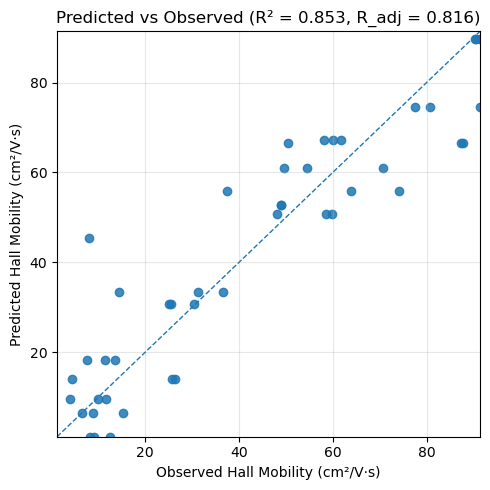

In [ ]:
from statsmodels.stats.outliers_influence import OLSInfluence

# -------------------------
# 1) Get Cook's distance
# -------------------------
influence = OLSInfluence(model)
cooks_d = influence.cooks_distance[0]   # array of D_i

# Put Cook's D back on the data frame (same index order)
df_cd = df_use.copy()
df_cd["cooks_d"] = cooks_d

# Rule-of-thumb cutoff (you can also use 4/(n - k - 1), here 4/n is fine)
n = df_cd.shape[0]
cutoff = 4 / n

high_cd = df_cd["cooks_d"] > cutoff
print("High Cook's distance points:")
print(df_cd.loc[high_cd])

# -------------------------
# 2) Drop the high-D point(s) and refit
# -------------------------
df_refit = df_cd.loc[~high_cd].drop(columns="cooks_d")

model_refit = smf.ols(formula=formula, data=df_refit).fit()
print(model_refit.summary())

anova_refit = anova_lm(model_refit, typ=2)
anova_refit.index = [clean_term_name(t) for t in anova_refit.index]
print("\n=== ANOVA after removing high Cook's distance point(s) ===")
anova_refit.to_excel("output/anova_no_high_cooksd.xlsx")
print(anova_refit)
plot_pred_vs_observed(model_refit, df_refit, target_col=target)



### not significant predictors to consider removing:

In [ ]:
# =========================
# Non-significant predictors (by ANOVA, after refit)
# =========================

alpha = 0.05  # significance level; change if you want (e.g. 0.10)

# anova_refit already computed in the previous cell
# Drop the Residual row and keep terms with p-value > alpha
nonsig_terms = (
    anova_refit
    .drop(index=["Residual"], errors="ignore")
    .loc[anova_refit["PR(>F)"] > alpha]
)

print(f"Non-significant terms at alpha = {alpha}:")
if nonsig_terms.empty:
    print("  None – all terms are significant at this level.")
else:
    print(nonsig_terms[["df", "F", "PR(>F)"]])


Non-significant terms at alpha = 0.05:
                                              df        F    PR(>F)
Q('Power (W)'):C(Q('Anneal Condition Num'))  1.0  2.74142  0.106718


## Residuals vs predicted plot

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import math

# def plot_residuals_vs_predictors(
#     model,
#     df,
#     predictors,
#     categorical_cols=None,
#     jitter_std=0.0,
#     include_index_plot=True,
#     title_prefix="Residuals vs predictors"
# ):
#     """
#     Make residuals vs predictor plots for a fitted statsmodels OLS model.

#     Parameters
#     ----------
#     model : statsmodels RegressionResultsWrapper
#         Fitted OLS model (from smf.ols(...).fit()).
#     df : pandas.DataFrame
#         Data frame used for the residual plots (same structure as used to fit).
#     predictors : list of str
#         Column names in df to use as predictors on the x-axes.
#     categorical_cols : list of str or None
#         Columns that should be treated as categorical and jittered on x.
#         Example: ["Anneal Condition Num"].
#     jitter_std : float
#         Standard deviation of normal noise added to categorical x for jitter.
#     include_index_plot : bool
#         If True, also plot residuals vs observation index.
#     title_prefix : str
#         Optional prefix for a super-title (not required).
#     """
#     if categorical_cols is None:
#         categorical_cols = []

#     # Residuals from the model (on this data)
#     resid = model.resid

#     # Layout for subplots
#     n = len(predictors)
#     n_cols = 2
#     n_rows = math.ceil(n / n_cols)

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(6, 3 * n_rows))
#     axes = np.atleast_1d(axes).flatten()

#     for ax, col in zip(axes, predictors):
#         x = df[col].values
#         y = resid.values

#         if col in categorical_cols:
#             # jitter categorical levels on x-axis
#             x_plot = x.astype(float) + np.random.normal(0, jitter_std, size=len(x))
#             ax.scatter(x_plot, y, alpha=0.85)
#             ax.set_xticks(sorted(np.unique(x)))
#         else:
#             ax.scatter(x, y, alpha=0.85)

#         ax.axhline(0, color="k", linewidth=1)
#         ax.set_xlabel(col, fontsize=10)
#         ax.set_ylabel("Residual", fontsize=10)
#         ax.grid(alpha=0.2)

#     # Hide any unused axes
#     for i in range(len(predictors), len(axes)):
#         axes[i].set_visible(False)

#     if title_prefix:
#         fig.suptitle(title_prefix, fontsize=12, y=1.02)

#     plt.tight_layout()
#     plt.show()

#     # Optional residuals vs index plot
#     if include_index_plot:
#         plt.figure(figsize=(5, 5))
#         plt.scatter(np.arange(len(resid)), resid, alpha=0.85)
#         plt.axhline(0, color="k", linewidth=1)
#         plt.xlabel("Observation index")
#         plt.ylabel("Residual")
#         plt.title("Residuals vs index")
#         plt.grid(alpha=0.3)
#         plt.tight_layout()
#         plt.show()

# plot_residuals_vs_predictors(
#     model=model,
#     df=df_use,
#     predictors=predictors,  # your existing list
#     categorical_cols=["Anneal Condition Num"],
#     title_prefix="Residual diagnostics - full model"
# )



KeyError: 'Area_In3d'

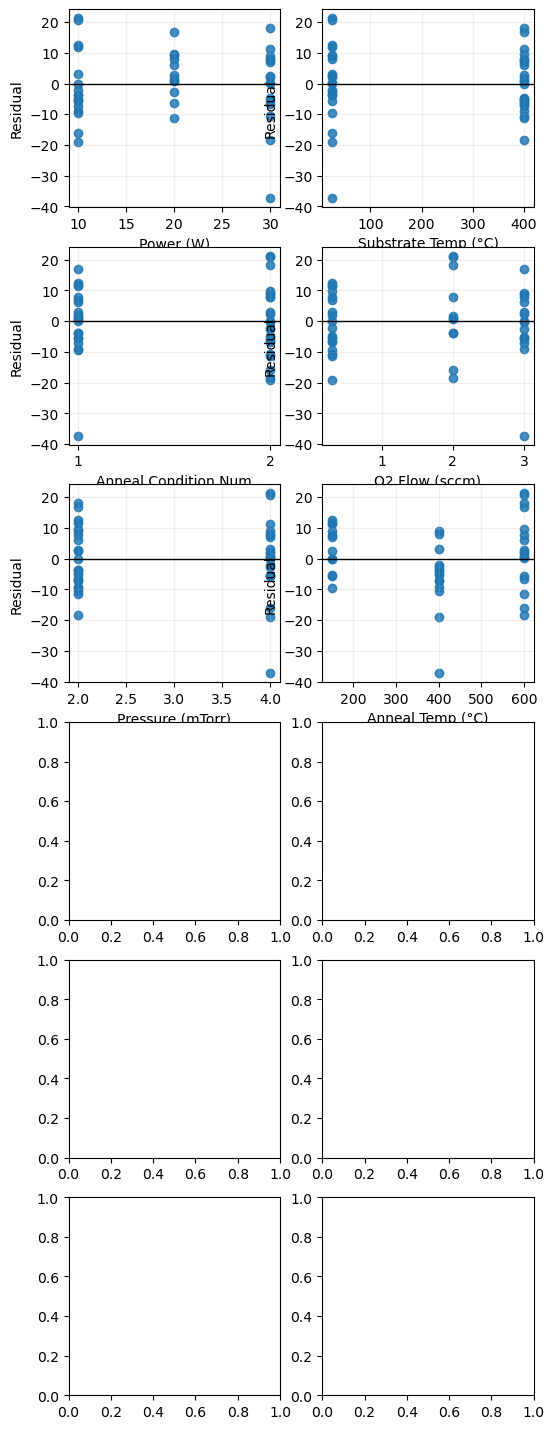

In [ ]:
# plot_residuals_vs_predictors(
#     model=model_refit,
#     df=df_refit,
#     predictors=predictors,
#     categorical_cols=["Anneal Condition Num"],
#     title_prefix="Residual diagnostics - refit model"
# )


## Threshold based on p-value pval_threshold = 0.10

In [ ]:
# Get Type II ANOVA table
anova_table = anova_lm(model, typ=2)
anova_table.index = [clean_term_name(t) for t in anova_table.index]

alpha = 0.10  # p-value threshold

terms_to_keep = []
terms_not_sig = []

for term in anova_table.index:
    if term == "Residual":
        continue

    pval = anova_table.loc[term, "PR(>F)"]

    if pval < alpha:
        terms_to_keep.append(term)
    else:
        terms_not_sig.append(term)

print(f"Using alpha = {alpha}")
print("\nStatistically significant terms (p < alpha):")
for t in terms_to_keep:
    print(f"  - {t} (p = {anova_table.loc[t, 'PR(>F)']:.4f})")

print("\nNot statistically significant terms (p ≥ alpha):")
for t in terms_not_sig:
    print(f"  - {t} (p = {anova_table.loc[t, 'PR(>F)']:.4f})")


Using alpha = 0.1

Statistically significant terms (p < alpha):
  - Power (W) (p = 0.0000)
  - Q('Power (W)'):C(Q('Anneal Condition Num')) (p = 0.0233)
  - Substrate Temp (°C) (p = 0.0001)
  - O2 Flow (sccm) (p = 0.0006)
  - Pressure (mTorr) (p = 0.0391)
  - Anneal Temp (°C) (p = 0.0000)
  - Substrate Temp (°C)'):Q('O2 Flow (sccm) (p = 0.0517)
  - Power (W)'):Q('O2 Flow (sccm) (p = 0.0485)

Not statistically significant terms (p ≥ alpha):
  - Anneal Condition Num (p = 0.2745)


Reduced model formula:
Q('Hall Mobility (cm^2/V·s)') ~ C(Q('Anneal Condition Num')) + Q('Anneal Temp (°C)') + Q('O2 Flow (sccm)') + Q('Power (W)') + Q('Pressure (mTorr)') + Q('Substrate Temp (°C)') + Q('Power (W)'):C(Q('Anneal Condition Num')) + Q('Substrate Temp (°C)'):C(Q('Anneal Condition Num')) + C(Q('Anneal Condition Num')):Q('O2 Flow (sccm)') + Q('Power (W)'):Q('Substrate Temp (°C)') + Q('Power (W)'):Q('O2 Flow (sccm)') + Q('Power (W)'):Q('Pressure (mTorr)') + Q('Substrate Temp (°C)'):Q('O2 Flow (sccm)') + Q('Substrate Temp (°C)'):Q('Pressure (mTorr)') + Q('O2 Flow (sccm)'):Q('Anneal Temp (°C)') + Q('Pressure (mTorr)'):Q('Anneal Temp (°C)')
                                  OLS Regression Results                                 
Dep. Variable:     Q('Hall Mobility (cm^2/V·s)')   R-squared:                       0.932
Model:                                       OLS   Adj. R-squared:                  0.898
Method:                            Least Squares   F-statistic:            

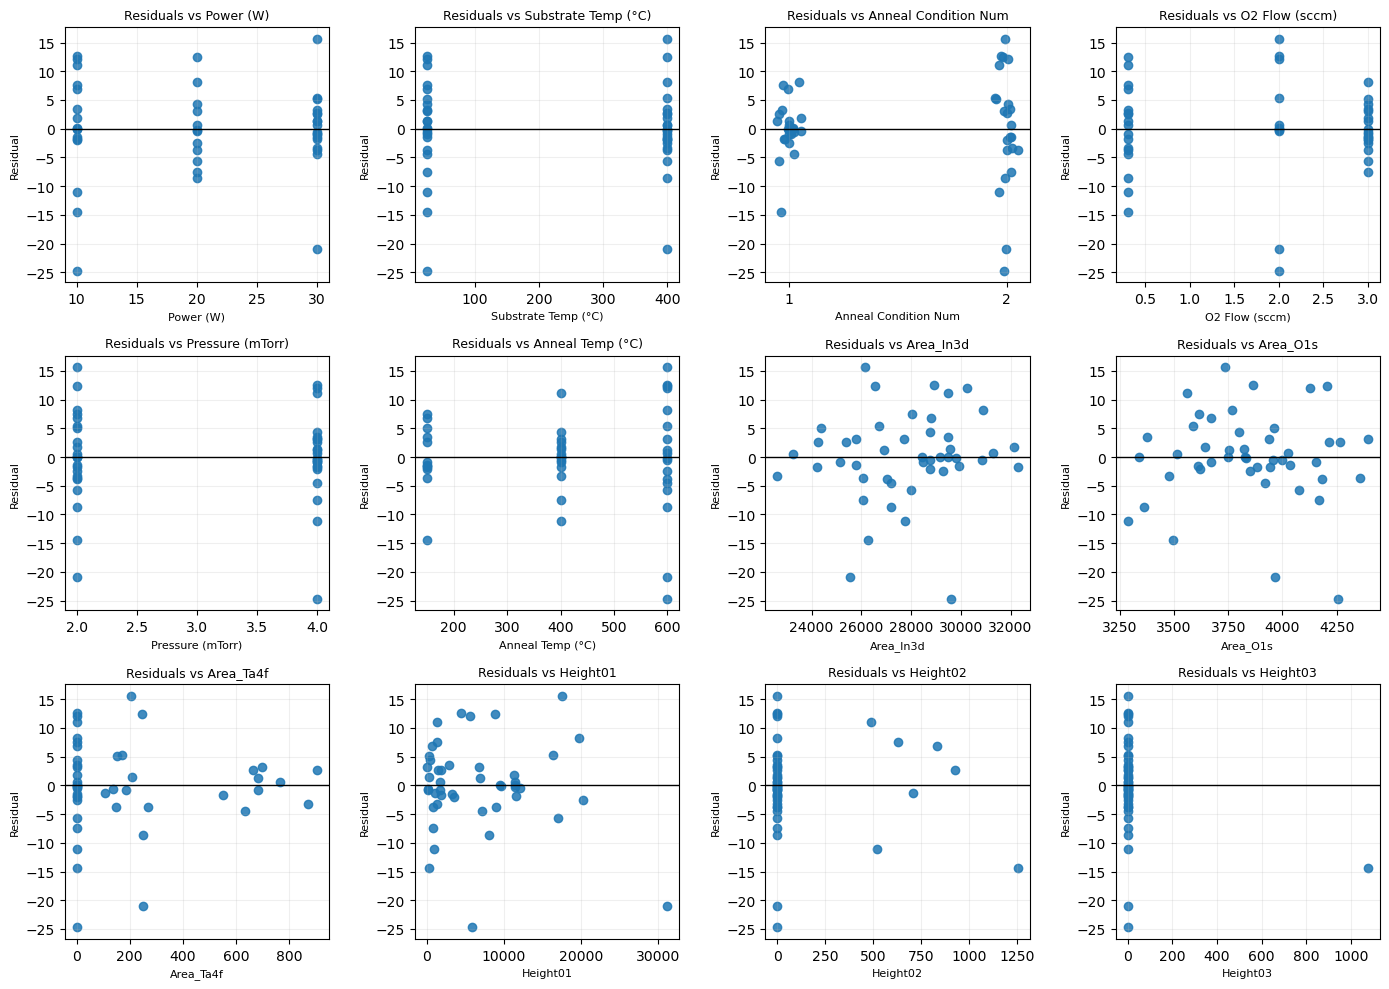

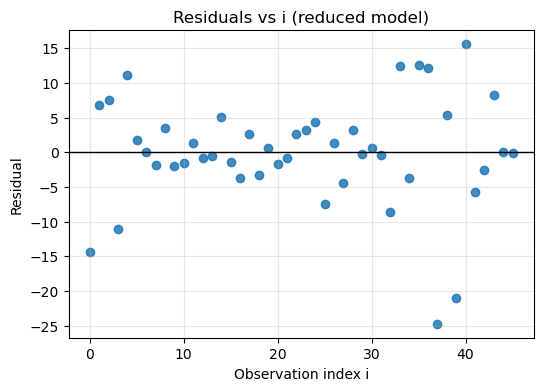

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import matplotlib.pyplot as plt

predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",   # categorical
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Height01",
    "Height02",
    "Height03",
]
target = "Hall Mobility (cm^2/V·s)"

df_use = master_df[predictors + [target]].dropna()

# =====================================================
# Terms you decided to keep
# =====================================================
kept_terms = [
    "Anneal Condition Num",
    "Power (W)",
    "Power (W) × Anneal Condition Num",
    "Substrate Temp (°C)",
    "Substrate Temp (°C) × Anneal Condition Num",
    "O2 Flow (sccm)",
    "Anneal Condition Num × O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
    "Power (W) × Substrate Temp (°C)",
    "Power (W) × O2 Flow (sccm)",
    "Power (W) × Pressure (mTorr)",
    "Substrate Temp (°C) × O2 Flow (sccm)",
    "Substrate Temp (°C) × Pressure (mTorr)",
    "O2 Flow (sccm) × Anneal Temp (°C)",
    "Pressure (mTorr) × Anneal Temp (°C)",
]

# Map from cleaned names to patsy expressions
name_to_patsy = {
    "Power (W)": "Q('Power (W)')",
    "Substrate Temp (°C)": "Q('Substrate Temp (°C)')",
    "Anneal Condition Num": "C(Q('Anneal Condition Num'))",
    "O2 Flow (sccm)": "Q('O2 Flow (sccm)')",
    "Pressure (mTorr)": "Q('Pressure (mTorr)')",
    "Anneal Temp (°C)": "Q('Anneal Temp (°C)')",
}

# Build main effect terms (keep all main effects from kept_terms)
main_effect_names = sorted({t for t in kept_terms if "×" not in t})
main_terms_patsy = [name_to_patsy[t] for t in main_effect_names]

# Build interaction terms in patsy syntax
interaction_names = [t for t in kept_terms if "×" in t]
interaction_terms_patsy = []
for t in interaction_names:
    left, right = [x.strip() for x in t.split("×")]
    left_patsy = name_to_patsy[left]
    right_patsy = name_to_patsy[right]
    interaction_terms_patsy.append(f"{left_patsy}:{right_patsy}")

# =====================================================
# Build reduced formula
# =====================================================
rhs_terms = main_terms_patsy + interaction_terms_patsy
formula_reduced = (
    "Q('Hall Mobility (cm^2/V·s)') ~ " + " + ".join(rhs_terms)
)

print("Reduced model formula:")
print(formula_reduced)

# =====================================================
# Fit reduced model
# =====================================================
model_red = smf.ols(formula=formula_reduced, data=df_use).fit()
print(model_red.summary())

# =====================================================
# ANOVA for reduced model (with cleaned names)
# =====================================================

def _clean_single(term: str) -> str:
    term = term.strip()
    if term.startswith("Q('") and term.endswith("')"):
        return term[3:-2]
    if term.startswith("C(Q('") and term.endswith("'))"):
        return term[5:-3]
    return term

def clean_term_name(term: str) -> str:
    if ":" in term:
        parts = term.split(":")
        clean_parts = [_clean_single(p) for p in parts]
        return " × ".join(clean_parts)
    else:
        return _clean_single(term)

anova_red = anova_lm(model_red, typ=2)
anova_red.index = [clean_term_name(t) for t in anova_red.index]

print("\n=== Reduced model ANOVA (Type II, cleaned names) ===")
print(anova_red)

# =====================================================
# Residual plots per predictor (same as before)
# =====================================================
resid = model_red.resid
pred_cols = predictors

n = len(pred_cols)
n_rows = 3
n_cols = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, pred_cols):
    x = df_use[col].values
    y = resid.values

    if col == "Anneal Condition Num":
        x_plot = x.astype(float) + np.random.normal(0, 0.03, size=len(x))
        ax.scatter(x_plot, y, alpha=0.85)
        ax.set_xticks(sorted(np.unique(x)))
    else:
        ax.scatter(x, y, alpha=0.85)

    ax.axhline(0, color="k", linewidth=1)
    ax.set_title(f"Residuals vs {col}", fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel("Residual", fontsize=8)
    ax.grid(alpha=0.2)

for i in range(len(pred_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(np.arange(len(resid)), resid, alpha=0.85)
plt.axhline(0, color="k", linewidth=1)
plt.xlabel("Observation index i")
plt.ylabel("Residual")
plt.title("Residuals vs i (reduced model)")
plt.grid(alpha=0.3)
plt.show()


# Bayesian optimization

In [28]:
import pandas as pd
import numpy as np
import torch
from botorch.models import SingleTaskGP
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import qExpectedImprovement
from botorch.optim import optimize_acqf

# columns
knob_cols = [
    "Power (W)",
    "Substrate Temp (°C)",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Condition Num",   # 0 or 1
    "Anneal Temp (°C)",
]
target_col = "Hall Mobility (cm^2/V·s)"

# 1) drop rows with missing knobs or missing target
df_bo = master_df[knob_cols + [target_col]].copy()
df_bo = df_bo.dropna(subset=knob_cols + [target_col])

# 2) build X and y
X = df_bo[knob_cols].astype(float).values
y = df_bo[target_col].astype(float).values.reshape(-1, 1)

# 3) normalize X to [0,1]
x_min = X.min(axis=0)
x_max = X.max(axis=0)
X_norm = (X - x_min) / (x_max - x_min + 1e-8)

# 4) make tensors
train_X = torch.tensor(X_norm, dtype=torch.double)
train_Y = torch.tensor(y, dtype=torch.double)

# 5) fit GP
model = SingleTaskGP(train_X, train_Y)
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll)
print("GP fitted OK, n =", train_X.shape[0])

best_f = train_Y.max()

# 2) build acquisition
q = 1  # number of points to propose at once
acqf = qExpectedImprovement(model=model, best_f=best_f)

# 3) optimize acquisition in [0, 1]^d
bounds = torch.stack(
    [
        torch.zeros(train_X.shape[1], dtype=torch.double),
        torch.ones(train_X.shape[1], dtype=torch.double),
    ]
)

candidate, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=q,
    num_restarts=10,
    raw_samples=64,
)

# 4) unnormalize back to real space
candidate_np = candidate.detach().numpy()

suggestions = []
for row in candidate_np:
    # unnormalize
    real = row * (x_max - x_min) + x_min

    # round the categorical variable
    # find its index
    anneal_idx = knob_cols.index("Anneal Condition Num")
    real[anneal_idx] = round(real[anneal_idx])  # 0 or 1

    suggestions.append(dict(zip(knob_cols, real)))

# 5) print suggestions
for i, s in enumerate(suggestions, 1):
    print(f"Suggested point {i}:")
    for k, v in s.items():
        print(f"  {k}: {v:.3f}")


GP fitted OK, n = 47
Suggested point 1:
  Power (W): 16.448
  Substrate Temp (°C): 400.000
  O2 Flow (sccm): 2.459
  Pressure (mTorr): 4.000
  Anneal Condition Num: 2.000
  Anneal Temp (°C): 600.000


/data/zhq7531/envs/ml_gp_env/lib/python3.13/site-packages/botorch/acquisition/monte_carlo.py:396: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


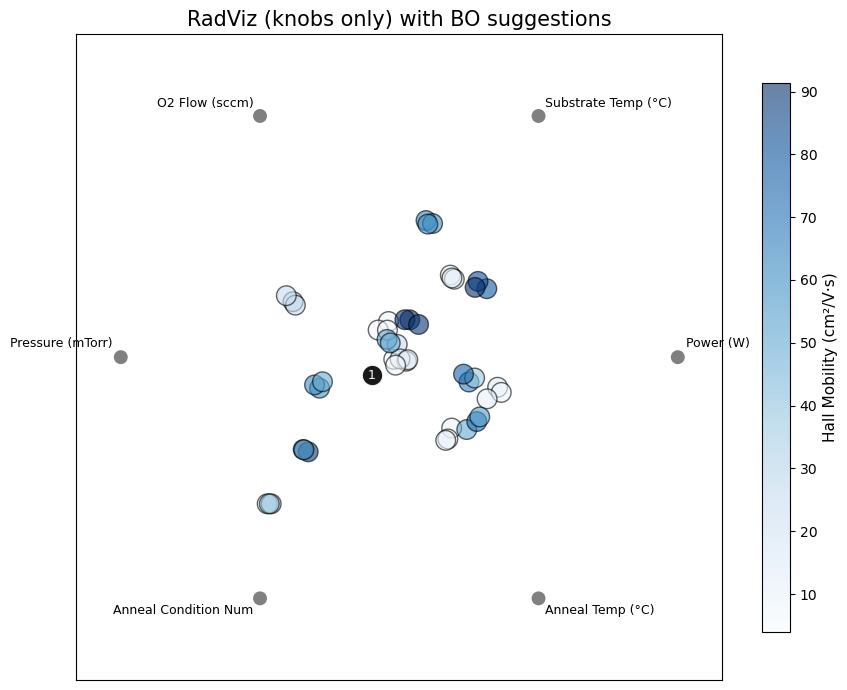

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import radviz

target_col = "Hall Mobility (cm^2/V·s)"

# -------------------------------------------------
# 1) Use only knob parameters for RadViz
# -------------------------------------------------
predictors_knobs = [
    c for c in knob_cols
    if c in master_df.columns and np.issubdtype(master_df[c].dtype, np.number)
]

cols_for_radviz = predictors_knobs + [target_col]
df_radviz = master_df[cols_for_radviz].dropna().copy()

# Bin Hall mobility just to satisfy pandas.radviz (we will hide these points)
df_radviz["HallMobilityBin"] = pd.qcut(
    df_radviz[target_col],
    q=3,
    labels=["Low μ", "Med μ", "High μ"],
)

df_radviz_plot = df_radviz[predictors_knobs + ["HallMobilityBin"]].copy()

# -------------------------------------------------
# 2) Optional jitter in each predictor to break ties (input space)
# -------------------------------------------------
np.random.seed(0)
jitter_strength = 0.02

for col in predictors_knobs:
    vals = df_radviz_plot[col].to_numpy(dtype=float)
    col_range = vals.max() - vals.min()
    if col_range == 0:
        continue
    noise = np.random.normal(0.0, jitter_strength * col_range, size=vals.shape)
    df_radviz_plot[col] = vals + noise

# -------------------------------------------------
# 3) Draw RadViz frame and anchors
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 7))
radviz(df_radviz_plot, class_column="HallMobilityBin", ax=ax)

# Remove legend created by radviz
leg = ax.get_legend()
if leg is not None:
    leg.remove()

# Hide the class scatter that radviz drew
for coll in ax.collections:
    coll.set_alpha(0)

ax.set_title("RadViz (knobs only) with BO suggestions", fontsize=15)
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])

# Pull text labels slightly outward and shrink font
for txt in ax.texts:
    x, y = txt.get_position()
    r = np.sqrt(x**2 + y**2)
    if r > 0:
        new_r = 1.03
        scale = new_r / r
        txt.set_position((x * scale, y * scale))
        txt.set_fontsize(9)

# -------------------------------------------------
# 4) Compute RadViz coordinates for existing data
# -------------------------------------------------
X = df_radviz[predictors_knobs].to_numpy(dtype=float)

X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_range = X_max - X_min
X_range[X_range == 0] = 1.0
X_norm = (X - X_min) / X_range

n_samples, n_features = X_norm.shape
angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False)
anchors = np.stack([np.cos(angles), np.sin(angles)], axis=1)

den = X_norm.sum(axis=1)
den[den == 0] = 1e-12
coords = (X_norm @ anchors) / den[:, None]

x_rv = coords[:, 0]
y_rv = coords[:, 1]
hall_vals = df_radviz[target_col].to_numpy(dtype=float)

# ---------- NEW: jitter in RadViz coordinates for background points ----------
rng_bg = np.random.default_rng(123)
rv_jitter = 0.02  # adjust if you want more / less spread
x_rv_j = x_rv + rng_bg.normal(0.0, rv_jitter, size=x_rv.shape)
y_rv_j = y_rv + rng_bg.normal(0.0, rv_jitter, size=y_rv.shape)

# Continuous Hall mobility background
sc = ax.scatter(
    x_rv_j,
    y_rv_j,
    c=hall_vals,
    cmap="Blues",
    s=200,
    alpha=0.6,
    edgecolor="k",
    zorder=2,
)

cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label("Hall Mobility (cm²/V·s)", fontsize=11)

# -------------------------------------------------
# 5) Overlay BO suggested points as black dots
# -------------------------------------------------
suggest_df = pd.DataFrame(suggestions)

# Keep only the knob columns used in RadViz
cand_X = suggest_df[predictors_knobs].astype(float).to_numpy()

cand_norm = (cand_X - X_min) / X_range
den_cand = cand_norm.sum(axis=1)
den_cand[den_cand == 0] = 1e-12
coords_cand = (cand_norm @ anchors) / den_cand[:, None]

x_cand = coords_cand[:, 0]
y_cand = coords_cand[:, 1]

# ---------- NEW: small jitter for suggested points too ----------
rng_cand = np.random.default_rng(456)
cand_jitter = 0.015
x_cand_j = x_cand + rng_cand.normal(0.0, cand_jitter, size=x_cand.shape)
y_cand_j = y_cand + rng_cand.normal(0.0, cand_jitter, size=y_cand.shape)

ax.scatter(
    x_cand_j,
    y_cand_j,
    c="k",
    s=220,
    alpha=0.9,
    edgecolor="white",
    linewidths=1.0,
    zorder=5,
)

# Optional: label suggested points 1, 2, 3
for i, (xc, yc) in enumerate(zip(x_cand_j, y_cand_j), start=1):
    ax.text(
        xc,
        yc,
        str(i),
        color="white",
        fontsize=9,
        ha="center",
        va="center",
        zorder=6,
    )

plt.tight_layout()
plt.show()


# LVGP

In [30]:
print(master_df.columns.tolist())

['Experiment', 'Trial', 'Power (W)', 'Substrate Temp (°C)', 'O2 Flow (sccm)', 'Pressure (mTorr)', 'Anneal Condition', 'Anneal Temp (°C)', 'Hall Mobility (cm^2/V·s)', 'Anneal Condition Num', 'In3d_p1', 'In3d_p2', 'O1s_p1', 'Ta4f_p1', 'Ta4f_p2', 'Area_In3d', 'Area_O1s', 'Area_Ta4f', 'Peak01', 'Peak02', 'Peak03', 'Height01', 'Height02', 'Height03', 'FWHM01', 'FWHM02', 'FWHM03']


In [31]:
import pandas as pd
import numpy as np
import torch

from botorch.models import SingleTaskGP
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_mll

knob_cols = [
    "Power (W)",
    "Substrate Temp (°C)",
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Condition Num",   # 0 or 1
    "Anneal Temp (°C)",
]
target_col = "Hall Mobility (cm^2/V·s)"

# 1) Clean data: drop rows with missing knobs or target
df_bo = master_df[knob_cols + [target_col]].copy()
df_bo = df_bo.dropna(subset=knob_cols + [target_col])

# Make sure anneal condition is 0/1 numeric
df_bo["Anneal Condition Num"] = df_bo["Anneal Condition Num"].astype(float)

# 2) Build X and y
X = df_bo[knob_cols].values.astype(float)
y = df_bo[target_col].values.astype(float).reshape(-1, 1)

# 3) Normalize X to [0,1] for each dimension
x_min = X.min(axis=0)
x_max = X.max(axis=0)
X_norm = (X - x_min) / (x_max - x_min + 1e-8)

train_X = torch.tensor(X_norm, dtype=torch.double)
train_Y = torch.tensor(y, dtype=torch.double)

# 4) Fit GP
model = SingleTaskGP(train_X, train_Y)
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll)

print("GP fitted, n =", train_X.shape[0])


GP fitted, n = 47


In [32]:
from botorch.acquisition import qExpectedImprovement
from botorch.optim import optimize_acqf

# 1) Best Hall mobility observed so far
best_f = train_Y.max()

# 2) EI acquisition function
acqf = qExpectedImprovement(model=model, best_f=best_f)

d = train_X.shape[1]  # number of inputs
bounds = torch.stack(
    [torch.zeros(d, dtype=torch.double),
     torch.ones(d, dtype=torch.double)]
)

# 3) Optimize EI in [0,1]^d (continuous)
q = 4  # number of points to suggest
candidate, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=q,
    num_restarts=10,
    raw_samples=64,
)
print(candidate)
# 4) Unnormalize to real units
candidate_np = candidate.detach().numpy()[0]
suggested = candidate_np * (x_max - x_min) + x_min

# 5) Round ONLY the anneal condition to 0 or 1
anneal_idx = knob_cols.index("Anneal Condition Num")
suggested[anneal_idx] = round(suggested[anneal_idx])  # 0 or 1

# 6) Pack suggestions in a readable dict
suggestion = dict(zip(knob_cols, suggested))

print("Suggested next experiment:")
for k, v in suggestion.items():
    print(f"  {k}: {v:.3f}")


/data/zhq7531/envs/ml_gp_env/lib/python3.13/site-packages/botorch/acquisition/monte_carlo.py:396: NumericsWarning: qExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qExpectedImprovement 	 --> 	 qLogExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)


tensor([[0.3215, 1.0000, 0.7363, 0.0000, 1.0000, 1.0000],
        [0.2109, 1.0000, 0.6704, 1.0000, 0.0000, 1.0000],
        [0.2199, 0.4936, 1.0000, 1.0000, 0.0000, 1.0000],
        [0.3451, 1.0000, 0.8402, 1.0000, 1.0000, 1.0000]], dtype=torch.float64)
Suggested next experiment:
  Power (W): 16.430
  Substrate Temp (°C): 400.000
  O2 Flow (sccm): 2.288
  Pressure (mTorr): 2.000
  Anneal Condition Num: 2.000
  Anneal Temp (°C): 600.000


# Trees 

In [33]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, root_mean_squared_error

# -------------------------------
# 0) Same setup as your OLS code
# -------------------------------
predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",   # categorical (treated as numeric codes here)
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Height01",
    "Height02",
    "Height03",
]
target = "Hall Mobility (cm^2/V·s)"

exclude_for_model = {
    "Area_In3d",
    "Area_O1s",
    "Area_Ta4f",
    "Height01",
    "Height02",
    "Height03",
    # you currently keep "Anneal Condition Num" in the model
}

# build clean df
df_use = master_df[predictors + [target]].dropna()

# ------------------------------------------
# 1) Select features
# ------------------------------------------
feature_cols = [col for col in predictors if col not in exclude_for_model]
X = df_use[feature_cols].values
y = df_use[target].values

print("Features used:", feature_cols)

# ------------------------------------------
# 2) Fit regression tree on ALL data
# ------------------------------------------
tree_reg = DecisionTreeRegressor(
    max_depth=3,        # tweak as you like
    min_samples_leaf=3,
    random_state=0,
)
tree_reg.fit(X, y)

# ------------------------------------------
# 3) In-sample performance
# ------------------------------------------
y_pred = tree_reg.predict(X)

rmse_in = root_mean_squared_error(y, y_pred)
r2_in = r2_score(y, y_pred)

print(f"In-sample RMSE = {rmse_in:.3f}")
print(f"In-sample R²   = {r2_in:.3f}")

# ------------------------------------------
# 4) Cross-validated performance (no explicit test split)
# ------------------------------------------
cv_r2 = cross_val_score(tree_reg, X, y, cv=5, scoring="r2")
cv_rmse = -cross_val_score(
    tree_reg, X, y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

print("\nCV R² (5-fold):", np.round(cv_r2, 3), " | mean =", cv_r2.mean().round(3))
print("CV RMSE (5-fold):", np.round(cv_rmse, 3), " | mean =", cv_rmse.mean().round(3))

# ------------------------------------------
# 5) Feature importances
# ------------------------------------------
importances = tree_reg.feature_importances_
imp_df = pd.DataFrame(
    {"feature": feature_cols, "importance": importances}
).sort_values("importance", ascending=False)

print("\nFeature importances")
print(imp_df.to_string(index=False))


Features used: ['Power (W)', 'Substrate Temp (°C)', 'Anneal Condition Num', 'O2 Flow (sccm)', 'Pressure (mTorr)', 'Anneal Temp (°C)']
In-sample RMSE = 10.248
In-sample R²   = 0.880

CV R² (5-fold): [-1.330e-01 -3.234e+01  2.050e-01 -1.700e-02 -2.496e+00]  | mean = -6.956
CV RMSE (5-fold): [19.984 35.105 19.758 25.955 32.089]  | mean = 26.578

Feature importances
             feature  importance
           Power (W)    0.447364
    Anneal Temp (°C)    0.408232
Anneal Condition Num    0.105584
      O2 Flow (sccm)    0.038820
 Substrate Temp (°C)    0.000000
    Pressure (mTorr)    0.000000


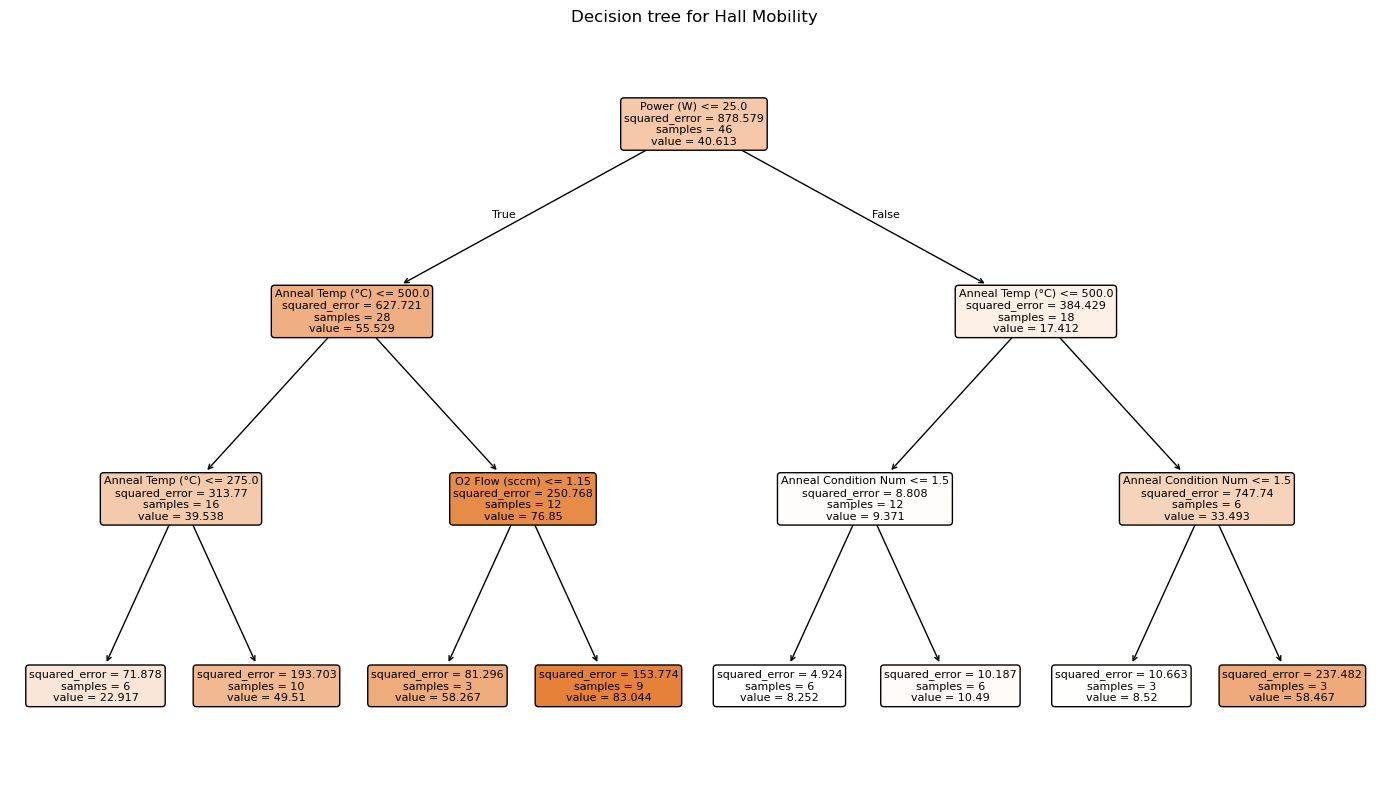

In [34]:
import matplotlib.pyplot as plt
from sklearn import tree

# ------------------------------------------
# Plot the decision tree
# ------------------------------------------
plt.figure(figsize=(14, 8))

tree.plot_tree(
    tree_reg,
    feature_names=feature_cols,
    filled=True,          # color leaves by value
    rounded=True,
    fontsize=8
)

plt.title("Decision tree for Hall Mobility")
plt.tight_layout()
plt.show()


Number of candidate alphas: 13

CPTABLE (like rpart$cptable):
     alpha  n_leaves  depth   cv_rmse  rel_error
  0.000000        15      5 31.699920   1.051733
  0.013636        15      5 31.400262   1.041791
  0.335589        12      5 31.435016   1.042944
  0.670145        11      5 31.574703   1.047579
  1.850580        11      5 31.574703   1.047579
  2.174819         9      4 31.574703   1.047579
  6.019758         9      4 31.574703   1.047579
 22.051047         7      3 31.874360   1.057521
 30.029589         6      3 32.022216   1.062426
 57.652612         6      3 30.187491   1.001554
 65.973742         5      3 30.140644   1.000000
207.536297         2      1 34.607096   1.148187
346.058983         1      0 37.266560   1.236422

Best alpha (min CV RMSE): 65.973742, leaves = 5, cv_rmse = 30.141


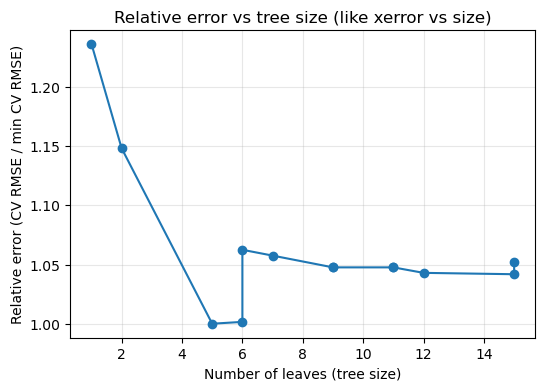

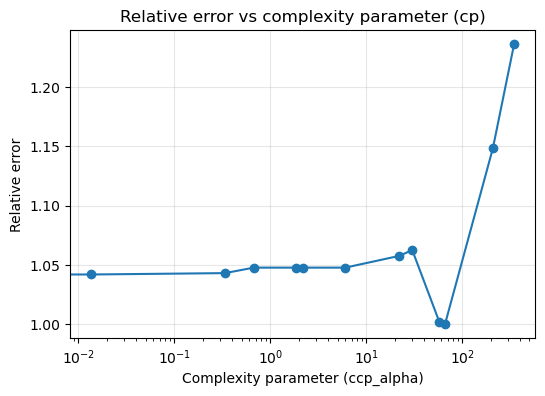

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

# ------------------------------------------
# 0) Cost-complexity pruning path
# ------------------------------------------
base_tree = DecisionTreeRegressor(
    random_state=0,
    min_samples_leaf=3,
    # do NOT set max_depth here, let pruning control complexity
)

path = base_tree.cost_complexity_pruning_path(X, y)
ccp_alphas = path.ccp_alphas  # like cp in rpart
impurities = path.impurities

print("Number of candidate alphas:", len(ccp_alphas))

# ------------------------------------------
# 1) Fit a tree for each alpha and do CV
# ------------------------------------------
trees = []
cv_rmse_list = []
n_leaves_list = []
depth_list = []

for alpha in ccp_alphas:
    tree_reg = DecisionTreeRegressor(
        # random_state=15,
        min_samples_leaf=3,
        ccp_alpha=alpha,
    )
    # 5-fold CV RMSE
    cv_rmse = -cross_val_score(
        tree_reg,
        X,
        y,
        cv=3,
        scoring="neg_root_mean_squared_error",
    )
    cv_rmse_list.append(cv_rmse.mean())

    tree_reg.fit(X, y)
    trees.append(tree_reg)
    n_leaves = np.sum(tree_reg.tree_.children_left == -1)
    n_leaves_list.append(n_leaves)
    depth_list.append(tree_reg.get_depth())

cv_rmse_array = np.array(cv_rmse_list)

# relative error: CV RMSE relative to the *smallest* CV RMSE
best_rmse = cv_rmse_array.min()
rel_error = cv_rmse_array / best_rmse

# ------------------------------------------
# 2) Build a cptable-like summary
# ------------------------------------------
cptable = pd.DataFrame({
    "alpha": ccp_alphas,
    "n_leaves": n_leaves_list,
    "depth": depth_list,
    "cv_rmse": cv_rmse_array,
    "rel_error": rel_error,
})

# find best (min CV error)
best_idx = np.argmin(cv_rmse_array)
best_alpha = ccp_alphas[best_idx]
best_n_leaves = n_leaves_list[best_idx]

print("\nCPTABLE (like rpart$cptable):")
print(cptable.head(15).to_string(index=False))  # show first 15 rows

print(f"\nBest alpha (min CV RMSE): {best_alpha:.6f}, "
      f"leaves = {best_n_leaves}, "
      f"cv_rmse = {best_rmse:.3f}")

# ------------------------------------------
# 3) Plots similar to R: relative error vs size and vs cp
# ------------------------------------------

# (a) relative error vs number of leaves
plt.figure(figsize=(6, 4))
plt.plot(n_leaves_list, rel_error, marker="o")
plt.xlabel("Number of leaves (tree size)")
plt.ylabel("Relative error (CV RMSE / min CV RMSE)")
plt.title("Relative error vs tree size (like xerror vs size)")
plt.grid(alpha=0.3)
plt.show()

# (b) relative error vs complexity parameter alpha
plt.figure(figsize=(6, 4))
plt.plot(ccp_alphas, rel_error, marker="o")
plt.xlabel("Complexity parameter (ccp_alpha)")
plt.ylabel("Relative error")
plt.title("Relative error vs complexity parameter (cp)")
plt.grid(alpha=0.3)
plt.xscale("log")  # cp / alpha often looks better on log scale
plt.show()


Best-pruned tree:
  n_leaves: 5
  depth   : 3
R² (on all data) = 0.780


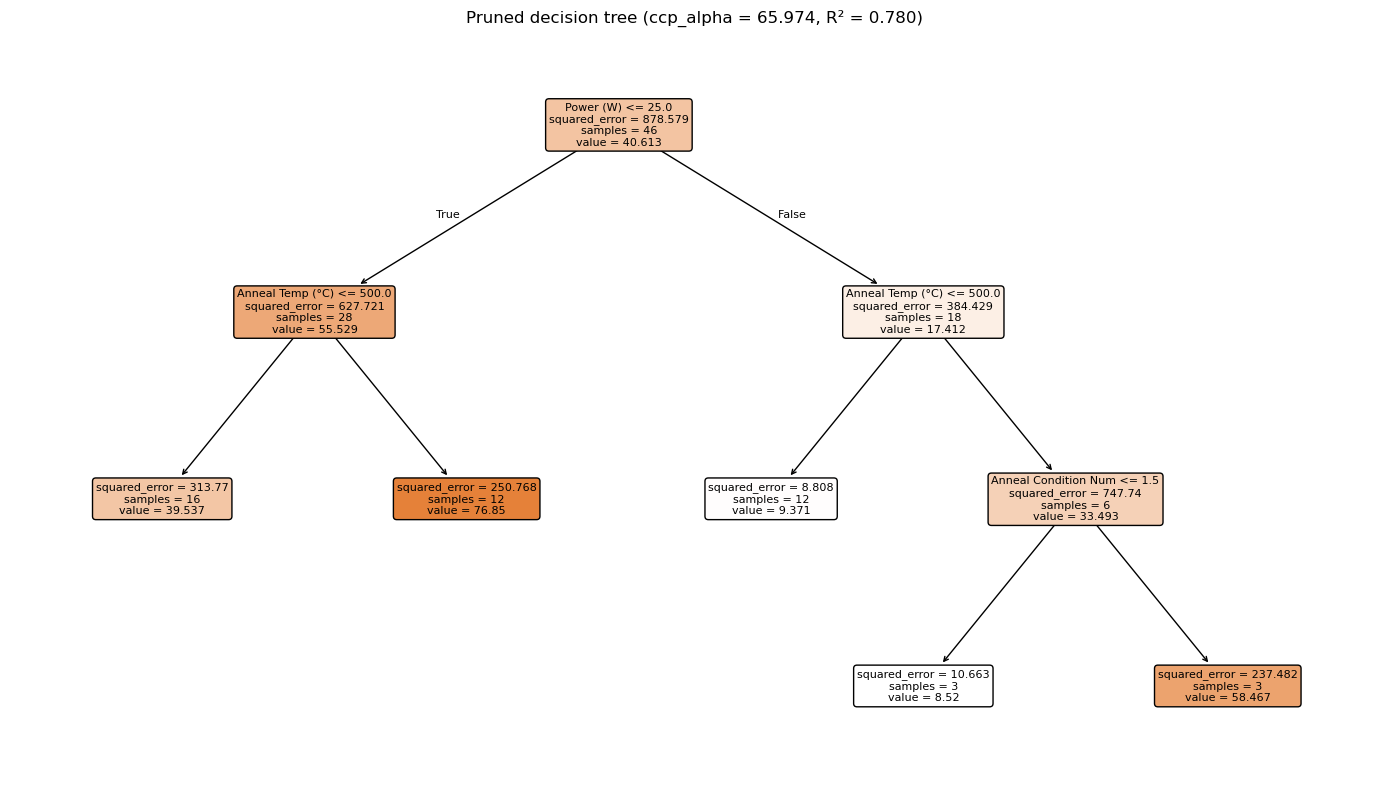


Feature importances:
             feature  importance
           Power (W)    0.504796
    Anneal Temp (°C)    0.376542
Anneal Condition Num    0.118662
 Substrate Temp (°C)    0.000000
      O2 Flow (sccm)    0.000000
    Pressure (mTorr)    0.000000


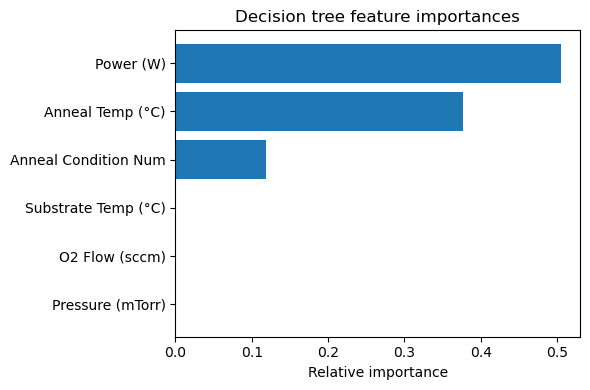

In [36]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
from sklearn.metrics import r2_score

# -------------------------------
# 1) Refit the best-pruned tree
# -------------------------------
best_alpha = 0  # or use the value you printed from cptable

# tree_best = DecisionTreeRegressor(
#     random_state=0,
#     min_samples_leaf=3,
#     ccp_alpha=best_alpha,
# )

best_tree = trees[best_idx]

# use the selected best tree and refit on all data
tree_best = best_tree
# tree_best.fit(X, y)

print("Best-pruned tree:")
print("  n_leaves:", np.sum(tree_best.tree_.children_left == -1))
print("  depth   :", tree_best.get_depth())

# ---- R² on all data ----
y_pred = tree_best.predict(X)
r2 = r2_score(y, y_pred)
print(f"R² (on all data) = {r2:.3f}")

# -------------------------------
# 2) Plot the pruned tree
# -------------------------------
plt.figure(figsize=(14, 8))

tree.plot_tree(
    tree_best,
    feature_names=feature_cols,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title(
    f"Pruned decision tree (ccp_alpha = {tree_best.ccp_alpha:.3f}, R² = {r2:.3f})"
)
plt.tight_layout()
plt.show()
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1) Get importances
importances = tree_best.feature_importances_   # one value per feature
imp_df = pd.DataFrame(
    {"feature": feature_cols, "importance": importances}
).sort_values("importance", ascending=False)

print("\nFeature importances:")
print(imp_df.to_string(index=False))

# 2) (Optional) Bar plot
plt.figure(figsize=(6, 4))
plt.barh(imp_df["feature"], imp_df["importance"])
plt.gca().invert_yaxis()  # most important on top
plt.xlabel("Relative importance")
plt.title("Decision tree feature importances")
plt.tight_layout()
plt.show()


In [37]:
print(trees[best_idx].ccp_alpha)

65.9737423007248


# Significant Predictors Analysis (ANOVA)

This section walks through an **ANOVA-based significance analysis** of the
predictors that influence `Hall Mobility (cm^2/V·s)`.

The workflow is:

1. **List every available predictor** so the dimensionality of the data is
   explicit (controllable process knobs, XPS features, XRD features).
2. Run ANOVA on the **controllable** predictors in two complementary ways:
   * **(A) Repeated samples** — keep every replicate as an independent row
     (n ≈ 51). This uses the full variance structure but treats replicates
     inside the same experiment as independent, which is the classical
     textbook ANOVA setup.
   * **(B) Averaged samples** — collapse each experiment to its mean
     (n = 17). This is the classical Design-of-Experiments view: each
     experiment gives one response.
3. Repeat (A) and (B) with **all predictors** (knobs + XPS + XRD) to see
   how richer feature sets change the significance picture.
4. Perform an **overfitting analysis** with leave-one-experiment-out
   cross-validation (only 17 experiments available), plus a learning
   curve of train-vs-test R² as complexity grows.


## 1. Listing all possible predictors

Before running any model, let's enumerate every column that could be used
as a predictor. This clarifies the dimensionality of the problem.


In [38]:
import pandas as pd
import numpy as np

target = "Hall Mobility (cm^2/V·s)"

controllable_predictors = [
    "Power (W)",
    "Substrate Temp (°C)",
    "Anneal Condition Num",   # categorical (0/1/2)
    "O2 Flow (sccm)",
    "Pressure (mTorr)",
    "Anneal Temp (°C)",
]

xps_predictors_all = [
    "Area_In3d", "Area_O1s", "Area_Ta4f",
    "In3d_p1", "In3d_p2",
    "O1s_p1",
    "Ta4f_p1", "Ta4f_p2",
    "In3d01", "In3d02", "O1s", "Ta4f01", "Ta4f02",
]
xps_predictors_all = [c for c in xps_predictors_all if c in master_df.columns]

xrd_predictors_all = [
    "Peak01", "Peak02", "Peak03",
    "Height01", "Height02", "Height03",
    "FWHM01", "FWHM02", "FWHM03",
]
xrd_predictors_all = [c for c in xrd_predictors_all if c in master_df.columns]

# The subset the user asked us to focus on for the "all predictors" run:
xps_focus = [c for c in ["Area_In3d", "Area_O1s", "Area_Ta4f"] if c in master_df.columns]
xrd_focus = [c for c in ["Height01", "Height02", "Height03"] if c in master_df.columns]

print("=" * 68)
print(f"master_df shape: {master_df.shape}")
print(f"Experiments:     {master_df['Experiment'].nunique()}")
print(f"Replicates/exp:  {sorted(master_df.groupby('Experiment').size().unique())}")
print("=" * 68)

def _print_block(name, cols):
    print(f"\n{name}  (n = {len(cols)})")
    for c in cols:
        miss = master_df[c].isna().sum() if c in master_df.columns else "--"
        print(f"  - {c:<25s}  missing={miss}")

_print_block("CONTROLLABLE predictors", controllable_predictors)
_print_block("XPS predictors (all)", xps_predictors_all)
_print_block("XRD predictors (all)", xrd_predictors_all)
_print_block("XPS subset used as 'all predictors' focus", xps_focus)
_print_block("XRD subset used as 'all predictors' focus", xrd_focus)

print(f"\nTARGET: {target}  "
      f"(missing = {master_df[target].isna().sum()})")

total_dim_all = len(controllable_predictors) + len(xps_predictors_all) + len(xrd_predictors_all)
total_dim_focus = len(controllable_predictors) + len(xps_focus) + len(xrd_focus)
print(f"\nDimensionality if *every* listed column were used : {total_dim_all} predictors")
print(f"Dimensionality of the focused 'all predictors' model: {total_dim_focus} predictors")
print("(Only 17 unique experiments, so models with many predictors are"
      " at high risk of overfitting.)")


master_df shape: (51, 27)
Experiments:     17
Replicates/exp:  [np.int64(3)]

CONTROLLABLE predictors  (n = 6)
  - Power (W)                  missing=0
  - Substrate Temp (°C)        missing=0
  - Anneal Condition Num       missing=0
  - O2 Flow (sccm)             missing=0
  - Pressure (mTorr)           missing=0
  - Anneal Temp (°C)           missing=0

XPS predictors (all)  (n = 8)
  - Area_In3d                  missing=1
  - Area_O1s                   missing=1
  - Area_Ta4f                  missing=1
  - In3d_p1                    missing=1
  - In3d_p2                    missing=1
  - O1s_p1                     missing=1
  - Ta4f_p1                    missing=19
  - Ta4f_p2                    missing=19

XRD predictors (all)  (n = 9)
  - Peak01                     missing=3
  - Peak02                     missing=44
  - Peak03                     missing=50
  - Height01                   missing=0
  - Height02                   missing=0
  - Height03                   missing=0
  -

## 2. ANOVA on the controllable predictors

We run Type-II ANOVA with main effects only (no interactions, so the
p-values are easier to read). The categorical `Anneal Condition Num`
is wrapped in `C(...)` so it is treated as a factor.

**Helper function** — computes OLS + ANOVA and returns a clean table.


In [39]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm


def _q(name):
    """Wrap a column name in Q('...') / C(Q('...')) for patsy."""
    return f"Q('{name}')"


def fit_ols_anova(df, target_col, predictors, categorical=("Anneal Condition Num",)):
    """Fit OLS with main-effects formula and return (model, anova_df)."""
    rhs_terms = []
    for p in predictors:
        if p in categorical:
            rhs_terms.append(f"C(Q('{p}'))")
        else:
            rhs_terms.append(_q(p))
    formula = f"{_q(target_col)} ~ " + " + ".join(rhs_terms)

    model = smf.ols(formula=formula, data=df).fit()
    aov = anova_lm(model, typ=2)

    # Clean the patsy wrappers out of the row names
    def _clean(term):
        if term.startswith("C(Q('") and term.endswith("'))"):
            return term[5:-3]
        if term.startswith("Q('") and term.endswith("')"):
            return term[3:-2]
        return term
    aov.index = [_clean(t) for t in aov.index]
    return model, aov


def anova_summary(aov_df):
    """Return a tidy, printable ANOVA summary with significance stars."""
    out = aov_df.copy()
    out["-log10(p)"] = -np.log10(out["PR(>F)"].clip(lower=1e-300))
    def _stars(p):
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        if p < 0.10:  return "."
        return ""
    out["sig"] = out["PR(>F)"].apply(_stars)
    return out[["sum_sq", "df", "F", "PR(>F)", "-log10(p)", "sig"]]


### 2A. Controllable predictors — *repeated samples*

Every replicate is one row (≈51 rows). This corresponds to the phrase
**"considering the repeated samples"**: the replicates are kept as
independent observations. Residual degrees of freedom are larger, so
tests look more powerful — but this setup ignores that the 3 replicates
inside an experiment are correlated (pseudoreplication caveat).


In [40]:
df_rep_ctrl = master_df[["Experiment"] + controllable_predictors + [target]].dropna().copy()
print(f"Rows used (repeated-samples controllable model): {len(df_rep_ctrl)}")
print(f"Unique experiments represented               : {df_rep_ctrl['Experiment'].nunique()}")

model_ctrl_rep, anova_ctrl_rep = fit_ols_anova(df_rep_ctrl, target, controllable_predictors)

print("\n--- ANOVA (Type II) — CONTROLLABLE predictors, REPEATED samples ---")
print(anova_summary(anova_ctrl_rep).round(4))
print(f"\nModel R² = {model_ctrl_rep.rsquared:.3f}, "
      f"Adj R² = {model_ctrl_rep.rsquared_adj:.3f}, "
      f"n = {int(model_ctrl_rep.nobs)}")


Rows used (repeated-samples controllable model): 47
Unique experiments represented               : 16

--- ANOVA (Type II) — CONTROLLABLE predictors, REPEATED samples ---
                          sum_sq    df        F  PR(>F)  -log10(p)  sig
Anneal Condition Num      2.9595   1.0   0.0116  0.9146     0.0388     
Power (W)              7399.6572   1.0  29.1190  0.0000     5.4781  ***
Substrate Temp (°C)    2826.7508   1.0  11.1238  0.0018     2.7335   **
O2 Flow (sccm)         3791.6803   1.0  14.9209  0.0004     3.3968  ***
Pressure (mTorr)         38.3200   1.0   0.1508  0.6998     0.1550     
Anneal Temp (°C)      15300.5001   1.0  60.2102  0.0000     8.7749  ***
Residual              10164.7174  40.0      NaN     NaN        NaN     

Model R² = 0.749, Adj R² = 0.711, n = 47


### 2B. Controllable predictors — *averaged samples*

Each experiment is collapsed to its **mean Hall mobility**, giving 17
rows. This is the classical DoE reading of the table. Residual df are
much smaller, so the test is more conservative, but every row is
genuinely independent.


In [41]:
# Collapse to per-experiment averages.
# Controllable knobs are constant within an experiment, so taking their mean
# just returns the same value; mean(target) removes replicate noise.
agg_cols = controllable_predictors + [target]
df_avg_ctrl = (
    master_df.dropna(subset=controllable_predictors + [target])
             .groupby("Experiment", as_index=False)[agg_cols]
             .mean(numeric_only=True)
)
print(f"Rows used (averaged controllable model): {len(df_avg_ctrl)}")

model_ctrl_avg, anova_ctrl_avg = fit_ols_anova(df_avg_ctrl, target, controllable_predictors)

print("\n--- ANOVA (Type II) — CONTROLLABLE predictors, AVERAGED samples ---")
print(anova_summary(anova_ctrl_avg).round(4))
print(f"\nModel R² = {model_ctrl_avg.rsquared:.3f}, "
      f"Adj R² = {model_ctrl_avg.rsquared_adj:.3f}, "
      f"n = {int(model_ctrl_avg.nobs)}")


Rows used (averaged controllable model): 16

--- ANOVA (Type II) — CONTROLLABLE predictors, AVERAGED samples ---
                         sum_sq   df        F  PR(>F)  -log10(p) sig
Anneal Condition Num     0.9967  1.0   0.0036  0.9532     0.0208    
Power (W)             2520.0861  1.0   9.2091  0.0141     1.8496   *
Substrate Temp (°C)    972.0375  1.0   3.5521  0.0921     1.0357   .
O2 Flow (sccm)        1264.2952  1.0   4.6201  0.0601     1.2212   .
Pressure (mTorr)        13.1919  1.0   0.0482  0.8311     0.0803    
Anneal Temp (°C)      5104.0510  1.0  18.6516  0.0019     2.7129  **
Residual              2462.8657  9.0      NaN     NaN        NaN    

Model R² = 0.805, Adj R² = 0.674, n = 16


### 2C. Side-by-side comparison (controllable)

Two visualisations make the comparison clear:

* **-log₁₀(p)** per predictor — higher bar = more significant.
* **F-statistic** per predictor — larger F = larger explained variance
  relative to residual.

Dashed guides at `p = 0.05` and `p = 0.10` make it easy to see which
predictors clear the significance bar under each approach.


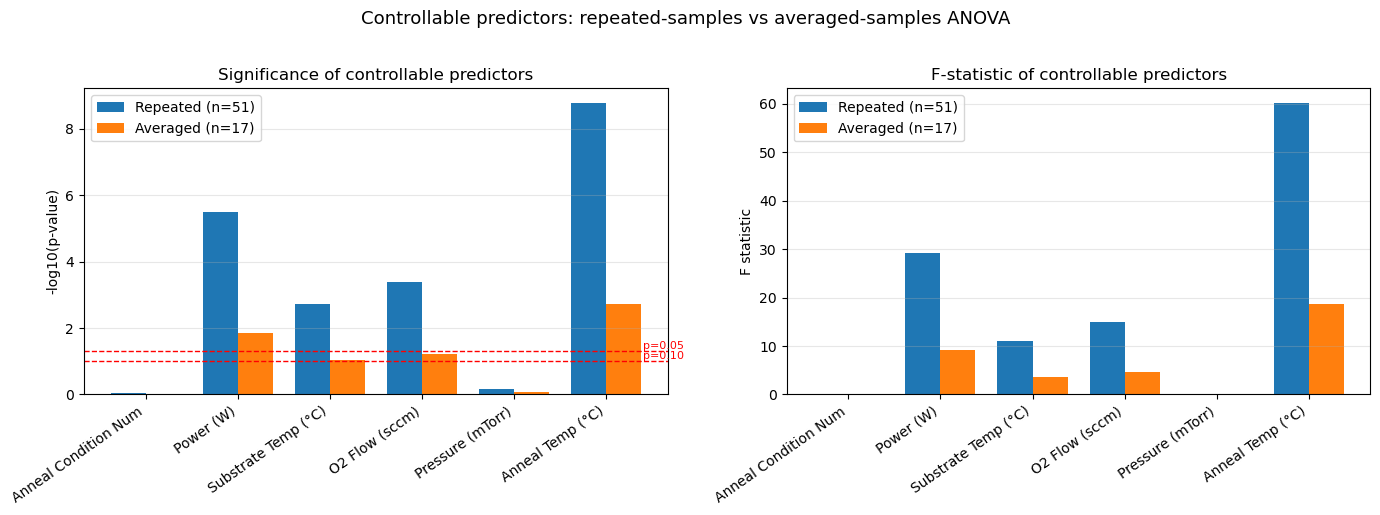

In [42]:
import matplotlib.pyplot as plt

def _bar_two(ax, df_rep, df_avg, value_col, title, ref_lines=()):
    terms = [t for t in df_rep.index if t != "Residual"]
    x = np.arange(len(terms))
    w = 0.38
    ax.bar(x - w/2, df_rep.loc[terms, value_col], width=w,
           label="Repeated (n=51)", color="#1f77b4")
    ax.bar(x + w/2, df_avg.loc[terms, value_col], width=w,
           label="Averaged (n=17)",  color="#ff7f0e")
    ax.set_xticks(x)
    ax.set_xticklabels(terms, rotation=35, ha="right")
    ax.set_title(title)
    for y, lab in ref_lines:
        ax.axhline(y, ls="--", color="red", lw=1)
        ax.text(len(terms)-0.6, y, lab, color="red", va="bottom", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

aov_rep = anova_summary(anova_ctrl_rep)
aov_avg = anova_summary(anova_ctrl_avg)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
_bar_two(axes[0], aov_rep, aov_avg, "-log10(p)",
         "Significance of controllable predictors",
         ref_lines=[(-np.log10(0.05), "p=0.05"),
                    (-np.log10(0.10), "p=0.10")])
axes[0].set_ylabel("-log10(p-value)")

_bar_two(axes[1], aov_rep, aov_avg, "F",
         "F-statistic of controllable predictors")
axes[1].set_ylabel("F statistic")

plt.suptitle("Controllable predictors: repeated-samples vs averaged-samples ANOVA",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 3. ANOVA on **all** predictors (controllable + XPS + XRD)

Out of curiosity, we enrich the model with the XPS and XRD features the
user highlighted:

* **XPS** — `Area_In3d`, `Area_O1s`, `Area_Ta4f`
* **XRD** — `Height01`, `Height02`, `Height03`

These features **do vary inside an experiment**, so the repeated-samples
model now has genuine within-experiment information to use.


In [43]:
all_predictors = controllable_predictors + xps_focus + xrd_focus
print("All predictors used:", all_predictors)
print(f"Total number of predictors: {len(all_predictors)}")

# Repeated-samples version
df_rep_all = master_df[["Experiment"] + all_predictors + [target]].dropna().copy()
print(f"\nRows used (repeated, all predictors):  {len(df_rep_all)}")
print(f"Unique experiments represented      :  {df_rep_all['Experiment'].nunique()}")

model_all_rep, anova_all_rep = fit_ols_anova(df_rep_all, target, all_predictors)
print("\n--- ANOVA — ALL predictors, REPEATED samples ---")
print(anova_summary(anova_all_rep).round(4))
print(f"\nModel R² = {model_all_rep.rsquared:.3f}, "
      f"Adj R² = {model_all_rep.rsquared_adj:.3f}, "
      f"n = {int(model_all_rep.nobs)}")


All predictors used: ['Power (W)', 'Substrate Temp (°C)', 'Anneal Condition Num', 'O2 Flow (sccm)', 'Pressure (mTorr)', 'Anneal Temp (°C)', 'Area_In3d', 'Area_O1s', 'Area_Ta4f', 'Height01', 'Height02', 'Height03']
Total number of predictors: 12

Rows used (repeated, all predictors):  46
Unique experiments represented      :  16

--- ANOVA — ALL predictors, REPEATED samples ---
                         sum_sq    df        F  PR(>F)  -log10(p)  sig
Anneal Condition Num   242.4476   1.0   1.3782  0.2488     0.6041     
Power (W)              584.8615   1.0   3.3247  0.0773     1.1117    .
Substrate Temp (°C)   3657.6471   1.0  20.7919  0.0001     4.1735  ***
O2 Flow (sccm)          26.8658   1.0   0.1527  0.6985     0.1559     
Pressure (mTorr)        22.1246   1.0   0.1258  0.7251     0.1396     
Anneal Temp (°C)      4611.5632   1.0  26.2145  0.0000     4.8877  ***
Area_In3d              239.0625   1.0   1.3590  0.2521     0.5985     
Area_O1s              1331.3904   1.0   7.5683  0.00

In [44]:
# Averaged-samples version: average XPS/XRD inside each experiment too.
df_avg_all = (
    master_df.dropna(subset=all_predictors + [target])
             .groupby("Experiment", as_index=False)[all_predictors + [target]]
             .mean(numeric_only=True)
)
print(f"Rows used (averaged, all predictors): {len(df_avg_all)}")

# With only 17 rows and 6+6 = 12 numeric terms (plus categorical levels),
# the OLS model is already near-saturated — that is part of the point.
model_all_avg, anova_all_avg = fit_ols_anova(df_avg_all, target, all_predictors)
print("\n--- ANOVA — ALL predictors, AVERAGED samples ---")
print(anova_summary(anova_all_avg).round(4))
print(f"\nModel R² = {model_all_avg.rsquared:.3f}, "
      f"Adj R² = {model_all_avg.rsquared_adj:.3f}, "
      f"n = {int(model_all_avg.nobs)}, "
      f"Residual df = {int(model_all_avg.df_resid)}")


Rows used (averaged, all predictors): 16

--- ANOVA — ALL predictors, AVERAGED samples ---
                        sum_sq   df       F  PR(>F)  -log10(p) sig
Anneal Condition Num  211.7971  1.0  2.2610  0.2297     0.6388    
Power (W)             592.2594  1.0  6.3224  0.0866     1.0625   .
Substrate Temp (°C)   791.3405  1.0  8.4477  0.0622     1.2064   .
O2 Flow (sccm)         53.7573  1.0  0.5739  0.5038     0.2977    
Pressure (mTorr)       78.4634  1.0  0.8376  0.4276     0.3690    
Anneal Temp (°C)      630.3627  1.0  6.7292  0.0808     1.0926   .
Area_In3d             284.7428  1.0  3.0397  0.1796     0.7457    
Area_O1s              553.0725  1.0  5.9041  0.0933     1.0299   .
Area_Ta4f             417.7983  1.0  4.4601  0.1251     0.9026    
Height01                2.1184  1.0  0.0226  0.8900     0.0506    
Height02                3.0567  1.0  0.0326  0.8682     0.0614    
Height03                1.7831  1.0  0.0190  0.8990     0.0462    
Residual              281.0270  3.0   

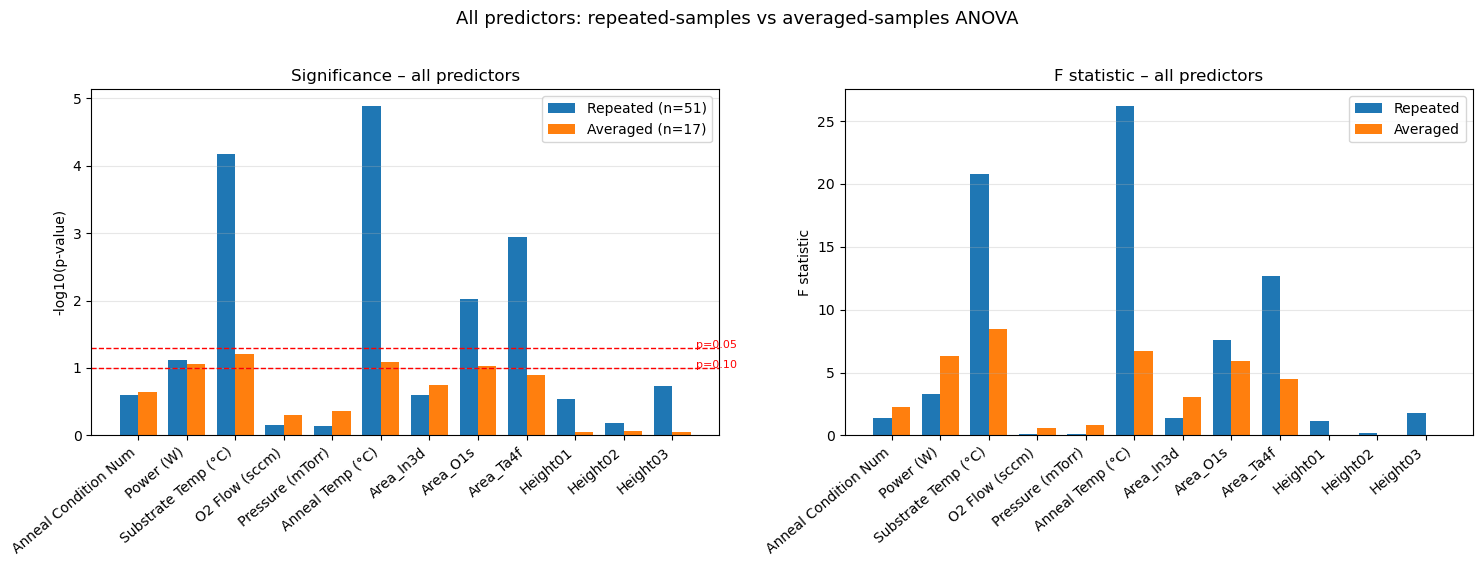

In [45]:
aov_rep_all = anova_summary(anova_all_rep)
aov_avg_all = anova_summary(anova_all_avg)

# Align on the union of terms (both tables might have slightly different rows)
terms = [t for t in aov_rep_all.index if t != "Residual"]
for t in aov_avg_all.index:
    if t != "Residual" and t not in terms:
        terms.append(t)

def _safe(df, term, col):
    return df.loc[term, col] if term in df.index else np.nan

rep_vals_logp = [_safe(aov_rep_all, t, "-log10(p)") for t in terms]
avg_vals_logp = [_safe(aov_avg_all, t, "-log10(p)") for t in terms]
rep_vals_F    = [_safe(aov_rep_all, t, "F")         for t in terms]
avg_vals_F    = [_safe(aov_avg_all, t, "F")         for t in terms]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
x = np.arange(len(terms)); w = 0.38
axes[0].bar(x - w/2, rep_vals_logp, w, label="Repeated (n=51)",  color="#1f77b4")
axes[0].bar(x + w/2, avg_vals_logp, w, label="Averaged (n=17)",   color="#ff7f0e")
axes[0].set_xticks(x); axes[0].set_xticklabels(terms, rotation=40, ha="right")
axes[0].axhline(-np.log10(0.05), ls="--", color="red", lw=1)
axes[0].text(len(terms)-0.5, -np.log10(0.05), "p=0.05", color="red", fontsize=8)
axes[0].axhline(-np.log10(0.10), ls="--", color="red", lw=1)
axes[0].text(len(terms)-0.5, -np.log10(0.10), "p=0.10", color="red", fontsize=8)
axes[0].set_ylabel("-log10(p-value)")
axes[0].set_title("Significance – all predictors")
axes[0].grid(axis="y", alpha=0.3); axes[0].legend()

axes[1].bar(x - w/2, rep_vals_F, w, color="#1f77b4", label="Repeated")
axes[1].bar(x + w/2, avg_vals_F, w, color="#ff7f0e", label="Averaged")
axes[1].set_xticks(x); axes[1].set_xticklabels(terms, rotation=40, ha="right")
axes[1].set_ylabel("F statistic")
axes[1].set_title("F statistic – all predictors")
axes[1].grid(axis="y", alpha=0.3); axes[1].legend()

plt.suptitle("All predictors: repeated-samples vs averaged-samples ANOVA",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


### 3A. How does the "significant predictor" verdict change?

The four models we just fit give four verdicts. The table below lists
every predictor once and reports the p-value under each model, so the
change in the significance story is visible at a glance.


In [46]:
def _pvals(aov, terms):
    return {t: (aov.loc[t, "PR(>F)"] if t in aov.index else np.nan) for t in terms}

all_terms_union = []
for aov in (anova_ctrl_rep, anova_ctrl_avg, anova_all_rep, anova_all_avg):
    for t in aov.index:
        if t != "Residual" and t not in all_terms_union:
            all_terms_union.append(t)

summary = pd.DataFrame(index=all_terms_union)
summary["ctrl / repeated"] = _pvals(anova_ctrl_rep, all_terms_union)
summary["ctrl / averaged"] = _pvals(anova_ctrl_avg, all_terms_union)
summary["all / repeated"]  = _pvals(anova_all_rep,  all_terms_union)
summary["all / averaged"]  = _pvals(anova_all_avg,  all_terms_union)
summary = summary.round(4)
print("p-values of each predictor under the 4 models")
print(summary.fillna("—"))

# Save to output
out_path = "output/anova_significance_comparison.xlsx"
summary.to_excel(out_path)
print(f"\nSaved -> {out_path}")


p-values of each predictor under the 4 models
                     ctrl / repeated ctrl / averaged  all / repeated  \
Anneal Condition Num          0.9146          0.9532          0.2488   
Power (W)                        0.0          0.0141          0.0773   
Substrate Temp (°C)           0.0018          0.0921          0.0001   
O2 Flow (sccm)                0.0004          0.0601          0.6985   
Pressure (mTorr)              0.6998          0.8311          0.7251   
Anneal Temp (°C)                 0.0          0.0019          0.0000   
Area_In3d                          —               —          0.2521   
Area_O1s                           —               —          0.0096   
Area_Ta4f                          —               —          0.0011   
Height01                           —               —          0.2842   
Height02                           —               —          0.6519   
Height03                           —               —          0.1878   

                 

## 4. Overfitting analysis

With only **17 unique experiments**, every model is at real risk of
fitting noise. We check three things:

1. **Adjusted R² vs R²** — a classic quick tell: large gap ⇒ overfit.
2. **Leave-one-experiment-out (LOEO) cross-validation** — the
   most honest test given a 17-point dataset. We drop *all replicates*
   of one experiment at a time, fit on the remaining 16 experiments,
   predict the held-out one, and report test R² / RMSE.
3. **Complexity sweep** — greedily add predictors in order of averaged-
   model significance and track train R² and LOEO test R² as the model
   grows. An overfit model has train R² rising while test R² stalls or
   drops.

A hold-out split (e.g., 4 of 17 experiments) is also shown for
reference, but LOEO uses the data much more efficiently and is the
recommended read.


In [47]:
from sklearn.metrics import r2_score, mean_squared_error

def leave_one_experiment_out(df_rows, predictors, target_col, categorical=("Anneal Condition Num",)):
    """
    LOEO CV: each experiment is held out as the test fold.
    df_rows can contain replicates (then every replicate of the held-out
    experiment goes to the test fold).
    Returns dict with y_true, y_pred (arrays aligned to held-out rows),
    fold_experiments, train_r2_list, test_r2_list.
    """
    exps = sorted(df_rows["Experiment"].unique())
    y_true_all, y_pred_all, fold_exp = [], [], []
    train_r2, test_r2 = [], []

    for e in exps:
        train_df = df_rows[df_rows["Experiment"] != e]
        test_df  = df_rows[df_rows["Experiment"] == e]
        if len(test_df) == 0:
            continue
        try:
            model, _ = fit_ols_anova(train_df, target_col, predictors, categorical)
            y_hat_train = model.predict(train_df)
            y_hat_test  = model.predict(test_df)
        except Exception as exc:
            print(f"  fold {e}: fit failed ({exc}); skipping")
            continue

        y_true_all.extend(test_df[target_col].values)
        y_pred_all.extend(y_hat_test.values)
        fold_exp.extend([e] * len(test_df))
        train_r2.append(r2_score(train_df[target_col], y_hat_train))
        test_r2.append(r2_score(test_df[target_col], y_hat_test)
                       if len(test_df) > 1 else np.nan)

    y_true_all = np.array(y_true_all); y_pred_all = np.array(y_pred_all)
    overall_r2   = r2_score(y_true_all, y_pred_all)
    overall_rmse = mean_squared_error(y_true_all, y_pred_all) ** 0.5
    return dict(
        y_true=y_true_all, y_pred=y_pred_all, fold_exp=np.array(fold_exp),
        train_r2=np.array(train_r2), per_fold_test_r2=np.array(test_r2),
        overall_test_r2=overall_r2, overall_test_rmse=overall_rmse,
    )

# Build the 4 scenarios
scenarios = {
    "ctrl / repeated": (df_rep_ctrl, controllable_predictors),
    "ctrl / averaged": (df_avg_ctrl.assign(Experiment=df_avg_ctrl["Experiment"].astype(int)),
                         controllable_predictors),
    "all  / repeated": (df_rep_all, all_predictors),
    "all  / averaged": (df_avg_all.assign(Experiment=df_avg_all["Experiment"].astype(int)),
                         all_predictors),
}

# In-sample metrics
insample_rows = []
for name, (df_s, preds) in scenarios.items():
    m, _ = fit_ols_anova(df_s, target, preds)
    insample_rows.append({
        "scenario": name, "n": int(m.nobs), "p": len(preds),
        "R2": round(m.rsquared, 3),
        "AdjR2": round(m.rsquared_adj, 3),
        "gap_R2-AdjR2": round(m.rsquared - m.rsquared_adj, 3),
    })
insample = pd.DataFrame(insample_rows)
print("In-sample fit quality (large gap R² - Adj-R² => overfitting)")
print(insample.to_string(index=False))


In-sample fit quality (large gap R² - Adj-R² => overfitting)
       scenario  n  p    R2  AdjR2  gap_R2-AdjR2
ctrl / repeated 47  6 0.749  0.711         0.038
ctrl / averaged 16  6 0.805  0.674         0.130
all  / repeated 46 12 0.856  0.804         0.052
all  / averaged 16 12 0.978  0.889         0.089


Leave-one-experiment-out cross-validation ...
  ctrl / repeated       test R² =  0.200   test RMSE = 26.26   mean train R² = 0.759
  ctrl / averaged       test R² =  0.234   test RMSE = 24.56   mean train R² = 0.815
  all  / repeated       test R² =  0.503   test RMSE = 20.90   mean train R² = 0.862
  all  / averaged       test R² =  0.209   test RMSE = 25.02   mean train R² = 0.983


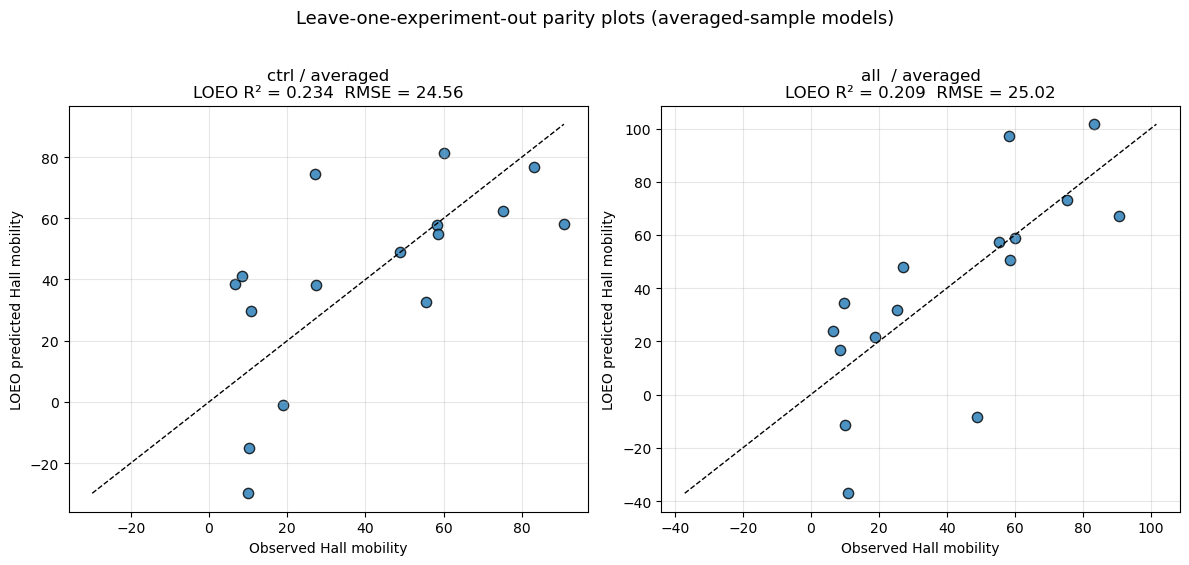

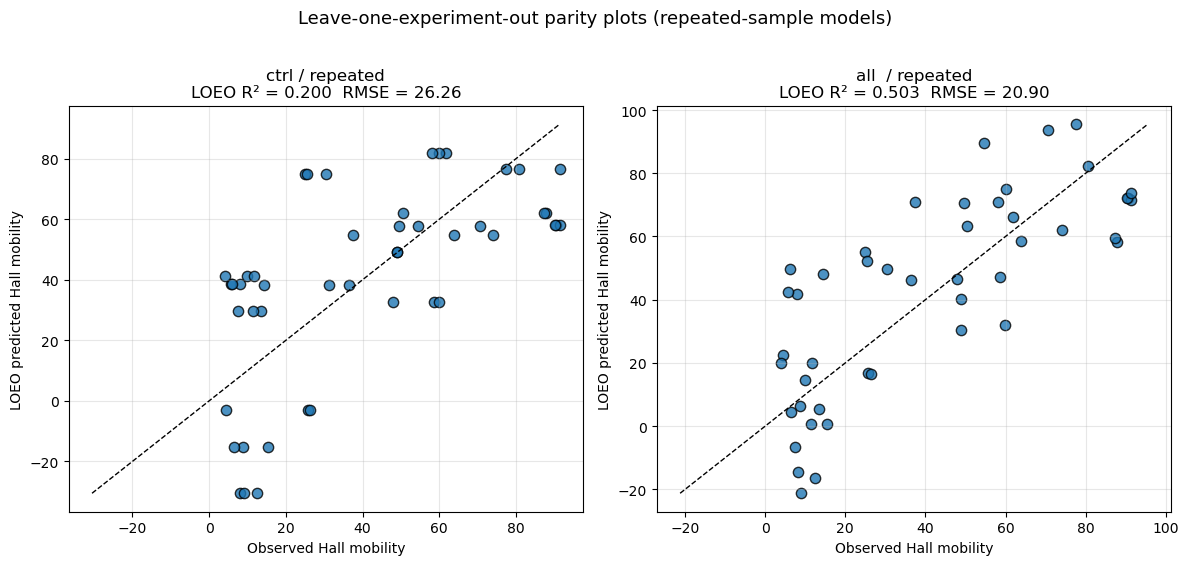

In [48]:
import warnings
cv_results = {}
print("Leave-one-experiment-out cross-validation ...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for name, (df_s, preds) in scenarios.items():
        cv_results[name] = leave_one_experiment_out(df_s, preds, target)
        r = cv_results[name]
        print(f"  {name:20s}  test R\u00b2 = {r['overall_test_r2']: .3f}   "
              f"test RMSE = {r['overall_test_rmse']:.2f}   "
              f"mean train R\u00b2 = {np.nanmean(r['train_r2']):.3f}")

# Parity plot: observed vs predicted on the held-out folds
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, key in zip(axes, ["ctrl / averaged", "all  / averaged"]):
    r = cv_results[key]
    ax.scatter(r["y_true"], r["y_pred"], s=55, alpha=0.8, edgecolor="k")
    lo = min(r["y_true"].min(), r["y_pred"].min())
    hi = max(r["y_true"].max(), r["y_pred"].max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_xlabel("Observed Hall mobility")
    ax.set_ylabel("LOEO predicted Hall mobility")
    ax.set_title(f"{key}\nLOEO R\u00b2 = {r['overall_test_r2']:.3f}  "
                 f"RMSE = {r['overall_test_rmse']:.2f}")
    ax.grid(alpha=0.3)
plt.suptitle("Leave-one-experiment-out parity plots (averaged-sample models)",
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, key in zip(axes, ["ctrl / repeated", "all  / repeated"]):
    r = cv_results[key]
    ax.scatter(r["y_true"], r["y_pred"], s=55, alpha=0.8, edgecolor="k")
    lo = min(r["y_true"].min(), r["y_pred"].min())
    hi = max(r["y_true"].max(), r["y_pred"].max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_xlabel("Observed Hall mobility")
    ax.set_ylabel("LOEO predicted Hall mobility")
    ax.set_title(f"{key}\nLOEO R\u00b2 = {r['overall_test_r2']:.3f}  "
                 f"RMSE = {r['overall_test_rmse']:.2f}")
    ax.grid(alpha=0.3)
plt.suptitle("Leave-one-experiment-out parity plots (repeated-sample models)",
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


Predictors ordered by averaged-sample p-value (most significant first):
   1. Substrate Temp (°C)        p=0.062
   2. Anneal Temp (°C)           p=0.081
   3. Power (W)                  p=0.087
   4. Area_O1s                   p=0.093
   5. Area_Ta4f                  p=0.125
   6. Area_In3d                  p=0.180
   7. Anneal Condition Num       p=0.230
   8. Pressure (mTorr)           p=0.428
   9. O2 Flow (sccm)             p=0.504
  10. Height02                   p=0.868
  11. Height01                   p=0.890
  12. Height03                   p=0.899


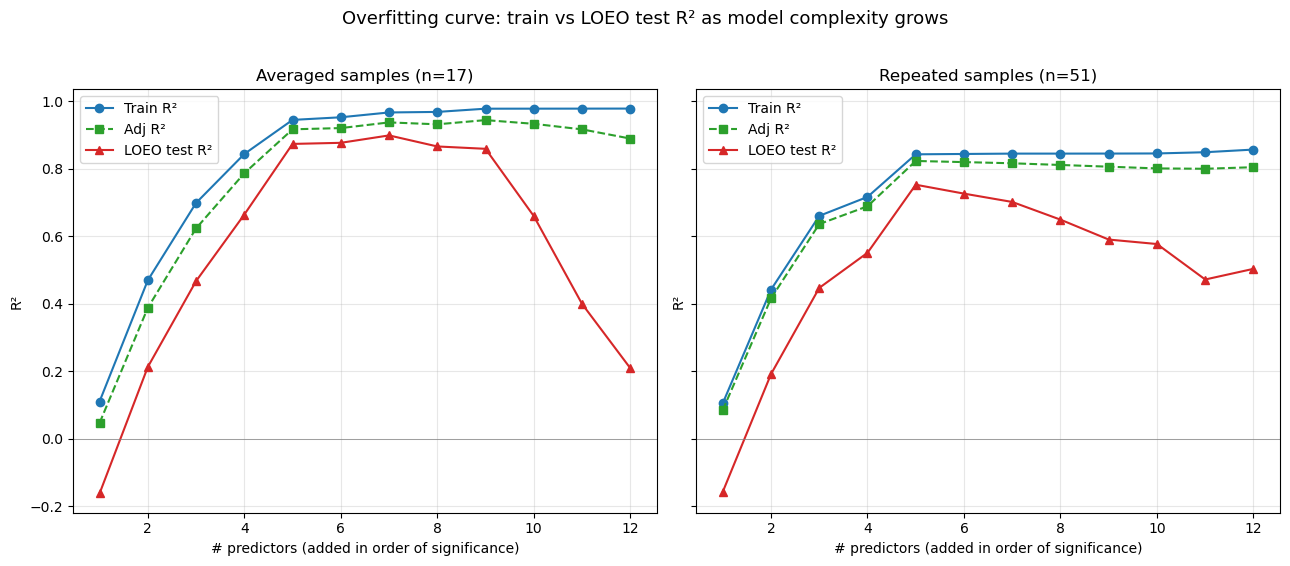


Averaged-sample overfitting signal:
 n_predictors  train_R2  adj_R2  LOEO_test_R2  gap_train-test
            1     0.110   0.046        -0.163           0.272
            2     0.469   0.387         0.212           0.257
            3     0.698   0.623         0.467           0.232
            4     0.843   0.786         0.664           0.179
            5     0.944   0.916         0.873           0.071
            6     0.952   0.920         0.876           0.076
            7     0.966   0.937         0.898           0.068
            8     0.968   0.931         0.866           0.102
            9     0.977   0.944         0.859           0.119
           10     0.978   0.933         0.659           0.318
           11     0.978   0.916         0.399           0.578
           12     0.978   0.889         0.209           0.769


In [49]:
# Complexity sweep: add predictors one-by-one in order of ANOVA
# significance on the averaged-samples model, then track train R² and
# LOEO test R². This is the clearest overfitting visual for tabular OLS.

# Rank predictors by p-value from the averaged "all predictors" model
rank_df = anova_all_avg.drop(index="Residual", errors="ignore").sort_values("PR(>F)")
ranked_preds = [t for t in rank_df.index if t in all_predictors]
print("Predictors ordered by averaged-sample p-value (most significant first):")
for i, p in enumerate(ranked_preds, 1):
    print(f"  {i:2d}. {p:<25s}  p={rank_df.loc[p, 'PR(>F)']:.3f}")

def _complexity_curve(df_source, target_col, ranked):
    n_pred, train_r2, test_r2, adj_r2 = [], [], [], []
    for k in range(1, len(ranked) + 1):
        sub = ranked[:k]
        try:
            m, _ = fit_ols_anova(df_source, target_col, sub)
            cv = leave_one_experiment_out(df_source, sub, target_col)
            train_r2.append(m.rsquared)
            adj_r2.append(m.rsquared_adj)
            test_r2.append(cv["overall_test_r2"])
        except Exception:
            train_r2.append(np.nan); adj_r2.append(np.nan); test_r2.append(np.nan)
        n_pred.append(k)
    return np.array(n_pred), np.array(train_r2), np.array(adj_r2), np.array(test_r2)

# Use the averaged dataframe (most trustworthy because rows are independent)
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    k_avg, tr_avg, adj_avg, te_avg = _complexity_curve(df_avg_all, target, ranked_preds)
# And the repeated-samples dataframe for comparison
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    k_rep, tr_rep, adj_rep, te_rep = _complexity_curve(df_rep_all, target, ranked_preds)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
for ax, (kk, tr, adj, te, title) in zip(
    axes,
    [(k_avg, tr_avg, adj_avg, te_avg, "Averaged samples (n=17)"),
     (k_rep, tr_rep, adj_rep, te_rep, "Repeated samples (n=51)")],
):
    ax.plot(kk, tr,  "o-", label="Train R²", color="#1f77b4")
    ax.plot(kk, adj, "s--", label="Adj R²",  color="#2ca02c")
    ax.plot(kk, te,  "^-", label="LOEO test R²", color="#d62728")
    ax.axhline(0, color="grey", lw=0.5)
    ax.set_xlabel("# predictors (added in order of significance)")
    ax.set_ylabel("R²")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle("Overfitting curve: train vs LOEO test R² as model complexity grows",
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# Print the gap so the takeaway is concrete
print("\nAveraged-sample overfitting signal:")
print(pd.DataFrame({
    "n_predictors": k_avg, "train_R2": tr_avg.round(3),
    "adj_R2": adj_avg.round(3), "LOEO_test_R2": te_avg.round(3),
    "gap_train-test": (tr_avg - te_avg).round(3),
}).to_string(index=False))


In [50]:
# Final fixed hold-out sanity check: randomly hold out 4 of 17 experiments
# (with a fixed seed for reproducibility) and report train/test R\u00b2.
# NOTE: With only 13 training experiments, the 'all-predictors' model has
# almost as many parameters as observations. When that happens we skip
# the affected scenario with a warning.
import warnings
rng = np.random.default_rng(42)
exps_all = sorted(df_avg_all["Experiment"].astype(int).unique())
test_exps = sorted(rng.choice(exps_all, size=4, replace=False).tolist())
train_exps = [e for e in exps_all if e not in test_exps]
print(f"Hold-out test experiments: {test_exps}")
print(f"Train experiments        : {train_exps}")

holdout_rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for name, (df_s, preds) in scenarios.items():
        df_train = df_s[df_s["Experiment"].isin(train_exps)]
        df_test  = df_s[df_s["Experiment"].isin(test_exps)]
        try:
            m, _ = fit_ols_anova(df_train, target, preds)
            y_pred_tr = m.predict(df_train)
            y_pred_te = m.predict(df_test)
            r2_tr = r2_score(df_train[target], y_pred_tr)
            r2_te = r2_score(df_test[target],  y_pred_te)
            rmse_te = mean_squared_error(df_test[target], y_pred_te) ** 0.5
            holdout_rows.append({
                "scenario": name,
                "n_train": len(df_train), "n_test": len(df_test),
                "train_R2": round(r2_tr, 3),
                "test_R2":  round(r2_te, 3),
                "test_RMSE": round(rmse_te, 2),
            })
        except Exception as exc:
            holdout_rows.append({
                "scenario": name,
                "n_train": len(df_train), "n_test": len(df_test),
                "train_R2": np.nan, "test_R2": np.nan, "test_RMSE": np.nan,
            })
            print(f"  [skip] {name}: {exc.__class__.__name__}: {exc}")

holdout = pd.DataFrame(holdout_rows)
print("\nFixed-seed hold-out (4 experiments out of 17):")
print(holdout.to_string(index=False))


Hold-out test experiments: [2, 8, 10, 11]
Train experiments        : [np.int64(1), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(9), np.int64(12), np.int64(13), np.int64(15), np.int64(16), np.int64(17)]
  [skip] all  / averaged: ValueError: r_matrix performs f_test for using dimensions that are asymptotically non-normal

Fixed-seed hold-out (4 experiments out of 17):
       scenario  n_train  n_test  train_R2  test_R2  test_RMSE
ctrl / repeated       35      12     0.850   -0.312      38.83
ctrl / averaged       12       4     0.935   -0.265      37.70
all  / repeated       35      11     0.889   -0.218      39.06
all  / averaged       12       4       NaN      NaN        NaN


### Interpretation tips

* **Repeated vs averaged** — on the controllable-only models, the
  p-values under the *repeated* approach look artificially small
  because replicates are treated as independent (pseudoreplication).
  The *averaged* model is the honest one for controllable knobs, since
  those knobs don't vary between replicates. Whenever a term is
  significant under *both* views, the signal is robust.

* **All predictors** — with 12 predictors and only 17 experiments, the
  averaged model is close to saturated. Expect train R² near 1.0 but
  shaky LOEO R² — that's the overfitting signature to watch for in the
  complexity-sweep plot.

* **What to trust as "significant"** — terms that (a) survive the
  averaged-model p-value threshold *and* (b) keep their sign / magnitude
  when the hold-out fold rotates. Use the LOEO parity plots and the
  complexity sweep together with the p-values, not in isolation.


# Gaussian Process (GP) Regression — Preliminary Analysis

## Predictors used
All **controllable process parameters** plus **XPS areas** and **XRD heights**:

| Group | Features |
|---|---|
| Controllable | Power (W), Substrate Temp (°C), Anneal Condition Num, O₂ Flow (sccm), Pressure (mTorr), Anneal Temp (°C) |
| XPS areas | Area\_In3d, Area\_O1s, Area\_Ta4f |
| XRD heights | Height01, Height02, Height03 |

---

## Evaluation metrics (mathematical definitions)

> **Reading the table below:** for every metric we list its formula, what an ideal model would produce, and the practical direction of improvement.

### 1. MAE — Mean Absolute Error
$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$
Average magnitude of errors in the same units as the target. Robust to outliers.
**Ideal value:** 0 (perfect predictions). **Direction:** lower is better. **Range:** $[0, +\infty)$.

### 2. RRMSE — Relative Root-Mean-Square Error
$$\text{RRMSE} = \frac{\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}}{\bar{y}}$$
RMSE normalised by the mean of observations; multiply by 100 for %. Allows comparing across datasets with different scales.
**Ideal value:** 0. **Direction:** lower is better. **Rule of thumb:** < 10 % excellent, 10–20 % good, 20–30 % fair, > 30 % poor.

### 3. R² — Coefficient of Determination
$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$
Proportion of variance in the target explained by the model.
**Ideal value:** 1. **Direction:** higher is better. **Range:** $(-\infty, 1]$. $R^2 = 0$ means "no better than predicting the mean"; **negative values are possible out-of-sample** and indicate the model is worse than the mean.

### 4. Coverage (PICP — Prediction Interval Coverage Probability)
$$\text{PICP}_{\alpha} = \frac{1}{n}\sum_{i=1}^{n}\mathbf{1}\!\left[y_i \in [\hat{l}_i^{(\alpha)},\, \hat{u}_i^{(\alpha)}]\right]$$
Fraction of observations falling inside the $(1-\alpha)$ prediction interval.
**Ideal value:** $1 - \alpha$ (e.g. **0.95** for a 95 % PI). **Direction:** as close to nominal as possible — **higher is *not* better**. PICP much above 0.95 means the GP is over-conservative (intervals too wide); PICP below 0.95 means over-confident (intervals too narrow). **Range:** $[0, 1]$.

### 5. IS — Interval Score (proper scoring rule, Gneiting & Raftery 2007)
$$\text{IS}_{\alpha} = \frac{1}{n}\sum_{i=1}^{n}\!\left[(u_i - l_i) + \frac{2}{\alpha}(l_i - y_i)\,\mathbf{1}[y_i < l_i] + \frac{2}{\alpha}(y_i - u_i)\,\mathbf{1}[y_i > u_i]\right]$$
Simultaneously rewards **sharp** intervals (small $u-l$) and **penalises misses** with a $2/\alpha$ factor.
**Ideal value:** 0 (a perfect oracle would produce zero-width intervals containing every point — unattainable in practice). **Direction:** lower is better. **Practical lower bound** for a calibrated model is the average MPIW, since a calibrated model with no misses scores exactly its MPIW. **Range:** $[0, +\infty)$.

### 6. MPIW — Mean Prediction Interval Width
$$\text{MPIW} = \frac{1}{n}\sum_{i=1}^{n}(u_i - l_i)$$
Average width of prediction intervals — a measure of **sharpness**.
**Ideal value:** as small as possible **while keeping PICP ≈ $1-\alpha$**. **Direction:** lower is better, but only meaningful when read together with coverage. A model with MPIW = 0 and PICP = 0 is useless.

### 7. NLL — Negative Log-Likelihood (Gaussian)
$$\text{NLL} = \frac{1}{n}\sum_{i=1}^{n}\left[\frac{(y_i-\hat{y}_i)^2}{2\hat{\sigma}_i^2} + \frac{1}{2}\ln(2\pi\hat{\sigma}_i^2)\right]$$
Evaluates the **full predictive distribution** (mean and variance). A GP that is over-confident (underestimates $\hat{\sigma}$) blows up the first term; one that is under-confident (huge $\hat{\sigma}$) blows up the second term.
**Ideal value:** $-\infty$ in theory (perfect mean with $\hat{\sigma} \to 0$). **In practice:** lower is better, and the minimum achievable depends on irreducible noise — for a perfectly calibrated GP it equals $\frac{1}{2}\ln(2\pi e \sigma_{\text{noise}}^2)$. **Range:** $(-\infty, +\infty)$ — negative values are perfectly fine.

### 8. CRPS — Continuous Ranked Probability Score
$$\text{CRPS} = \frac{1}{n}\sum_{i=1}^{n}\int_{-\infty}^{+\infty}\!\left[F_i(z) - \mathbf{1}[z \geq y_i]\right]^2 dz$$
For a Gaussian predictive distribution this reduces to a closed form involving $\phi$ (pdf) and $\Phi$ (cdf) of the standard normal. Jointly assesses calibration and sharpness.
**Ideal value:** 0 (perfect probabilistic forecast — point mass at the true value). **Direction:** lower is better. **Units:** same as the target (cm²/V·s here), so it is interpretable. **Range:** $[0, +\infty)$.

### Quick-reference summary

| Metric | Ideal | Direction | Notes |
|---|---|---|---|
| MAE | 0 | ↓ lower | same units as target |
| RRMSE | 0 | ↓ lower | scale-free, % of mean |
| R² | 1 | ↑ higher | can go negative on test data |
| Coverage (PICP) | 1 − α (e.g. 0.95) | → match nominal | over- *and* under-coverage are both bad |
| IS | 0 (≥ MPIW) | ↓ lower | combines sharpness + miss penalty |
| MPIW | small *and* PICP ≈ 1−α | ↓ lower (conditionally) | meaningless without PICP |
| NLL | as low as possible | ↓ lower | negative values OK |
| CRPS | 0 | ↓ lower | same units as target |

---

## Validation strategy — Leave-One-Experiment-Out (LOEO)

With only ~17 unique experiments, a random train/test split wastes data and introduces high variance. We use **LOEO-CV**:

1. For each experiment $e$, train the GP on all rows from the remaining $n-1$ experiments.
2. Predict every replicate of the held-out experiment $e$.
3. Aggregate predictions across all folds to compute the metrics above.

We report **both training and LOEO metrics** so the **train → validation gap** is visible — that gap is the canonical signature of overfitting (expected to be large given the dataset size). LOEO is the same protocol used in the OLS section, so results are directly comparable.

---

## Predictor importance via ARD kernel

The GP uses an **Anisotropic Matérn-5/2** (ARD) kernel:
$$k(\mathbf{x},\mathbf{x}') = \sigma_f^2 \exp\!\left(-\frac{1}{2}\sum_{j=1}^{p}\frac{(x_j - x_j')^2}{\ell_j^2}\right)$$

Each predictor $j$ has its own length scale $\ell_j$ learned by maximising the marginal likelihood.
A **small $\ell_j$** means the GP output changes rapidly along dimension $j$ → that predictor is **more important**.
We report $1/\ell_j$ normalised to sum to 1 as a relative importance measure.

**Caveat:** length scales are confounded with input scaling. All predictors are normalised to $[0, 1]$ (via BoTorch's `Normalize` input transform) before fitting, so the length scales are directly comparable across features.

We also report **permutation importance** (model-agnostic): shuffling one feature at a time and measuring the increase in MAE across LOEO folds.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.stats import norm
from sklearn.metrics import r2_score

from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood

torch.set_default_dtype(torch.double)

# ── 0. Config ─────────────────────────────────────────────────────────────────
target = "Hall Mobility (cm^2/V\u00b7s)"
alpha_ci = 0.05        # 95 % prediction interval

controllable = [
    "Power (W)", "Substrate Temp (\u00b0C)", "Anneal Condition Num",
    "O2 Flow (sccm)", "Pressure (mTorr)", "Anneal Temp (\u00b0C)",
]
xps_areas   = [c for c in ["Area_In3d", "Area_O1s", "Area_Ta4f"]  if c in master_df.columns]
xrd_heights = [c for c in ["Height01", "Height02", "Height03"]    if c in master_df.columns]
gp_features = controllable + xps_areas + xrd_heights

print("GP features:", gp_features)
print(f"Total: {len(gp_features)} features")

# ── 1. Working dataframe ──────────────────────────────────────────────────────
df_gp = master_df[["Experiment"] + gp_features + [target]].dropna().copy().reset_index(drop=True)
print(f"\nRows: {len(df_gp)}  |  Unique experiments: {df_gp['Experiment'].nunique()}")

n_feat = len(gp_features)
experiments = sorted(df_gp["Experiment"].unique())

# ── 2. Helper: fit a SingleTaskGP with ARD Matern-5/2 ────────────────────────
def fit_botorch_gp(X_np, y_np):
    """Fit BoTorch SingleTaskGP with input Normalize + outcome Standardize.

    SingleTaskGP defaults: Matern-5/2 kernel with ARD (one length-scale per input)
    plus a learned Gaussian likelihood (homoscedastic noise).
    """
    train_X = torch.tensor(X_np, dtype=torch.double)
    train_Y = torch.tensor(y_np, dtype=torch.double).view(-1, 1)
    model = SingleTaskGP(
        train_X, train_Y,
        input_transform=Normalize(d=train_X.shape[-1]),
        outcome_transform=Standardize(m=1),
    )
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)
    return model

def gp_predict(model, X_np):
    """Posterior mean and predictive std (incl. observation noise) on raw X."""
    model.eval()
    with torch.no_grad():
        post = model.posterior(torch.tensor(X_np, dtype=torch.double),
                               observation_noise=True)
        mu    = post.mean.view(-1).cpu().numpy()
        sigma = post.variance.clamp_min(1e-12).sqrt().view(-1).cpu().numpy()
    return mu, sigma

def compute_metrics(y_true, y_pred, y_std, alpha=alpha_ci):
    """Return all 8 metrics as a dict."""
    z = norm.ppf(1 - alpha / 2)
    lo, hi = y_pred - z * y_std, y_pred + z * y_std

    pen_lo = np.maximum(0.0, lo - y_true)
    pen_hi = np.maximum(0.0, y_true - hi)
    std_r  = (y_true - y_pred) / y_std

    return {
        "MAE"     : np.mean(np.abs(y_true - y_pred)),
        "RRMSE"   : np.sqrt(np.mean((y_true - y_pred)**2)) / np.mean(y_true),
        "R\u00b2": r2_score(y_true, y_pred),
        "Coverage": np.mean((y_true >= lo) & (y_true <= hi)),
        "IS\u2080.\u2080\u2085": np.mean((hi - lo) + (2/alpha)*pen_lo + (2/alpha)*pen_hi),
        "MPIW"    : np.mean(hi - lo),
        "NLL"     : np.mean(0.5 * std_r**2 + 0.5 * np.log(2 * np.pi * y_std**2)),
        "CRPS"    : np.mean(y_std * (std_r * (2*norm.cdf(std_r) - 1)
                                     + 2*norm.pdf(std_r) - 1/np.sqrt(np.pi))
                            - (y_true - y_pred) * (2*norm.cdf(std_r) - 1)),
    }

# ── 3. LOEO-CV ────────────────────────────────────────────────────────────────
y_true_all, y_pred_all, y_std_all, exp_labels = [], [], [], []

for exp in experiments:
    mask_test  = df_gp["Experiment"] == exp
    mask_train = ~mask_test

    X_tr = df_gp.loc[mask_train, gp_features].values.astype(float)
    y_tr = df_gp.loc[mask_train, target].values.astype(float)
    X_te = df_gp.loc[mask_test,  gp_features].values.astype(float)
    y_te = df_gp.loc[mask_test,  target].values.astype(float)

    model_f = fit_botorch_gp(X_tr, y_tr)
    mu, sigma = gp_predict(model_f, X_te)

    y_true_all.extend(y_te.tolist())
    y_pred_all.extend(mu.tolist())
    y_std_all.extend(sigma.tolist())
    exp_labels.extend([exp] * len(y_te))

y_true = np.array(y_true_all)
y_pred = np.array(y_pred_all)
y_std  = np.array(y_std_all)

# ── 4. Training metrics (full-data GP, predicting back its own training rows) ─
X_full = df_gp[gp_features].values.astype(float)
y_full = df_gp[target].values.astype(float)
model_full = fit_botorch_gp(X_full, y_full)        # reused later for ARD importance

y_pred_tr, y_std_tr = gp_predict(model_full, X_full)
y_true_tr = y_full

# ── 5. Side-by-side metrics table ─────────────────────────────────────────────
m_train = compute_metrics(y_true_tr, y_pred_tr, y_std_tr)
m_loeo  = compute_metrics(y_true,    y_pred,    y_std)

z = norm.ppf(1 - alpha_ci / 2)   # used in plots below
units = "cm\u00b2/V\u00b7s"

# Build a pretty table
rows = []
for k in ["MAE", "RRMSE", "R\u00b2", "Coverage",
          "IS\u2080.\u2080\u2085", "MPIW", "NLL", "CRPS"]:
    rows.append({"Metric": k, "Training": m_train[k], "LOEO (validation)": m_loeo[k]})
metrics_df = pd.DataFrame(rows)

# Add a "gap" column (validation \u2212 training, larger \u2192 more overfit) for error-style metrics
err_metrics = {"MAE", "RRMSE", "IS\u2080.\u2080\u2085", "MPIW", "NLL", "CRPS"}
metrics_df["Gap (val \u2212 train)"] = [
    (r["LOEO (validation)"] - r["Training"]) if r["Metric"] in err_metrics
    else (r["Training"] - r["LOEO (validation)"])      # for R\u00b2 / Coverage, training \u2212 val
    for _, r in metrics_df.iterrows()
]

print("\n" + "="*72)
print(f"{'BoTorch SingleTaskGP \u2014 Training vs LOEO Validation':^72}")
print("="*72)
print(metrics_df.to_string(index=False, float_format="%.4f"))
print("\n* For error metrics (MAE, RRMSE, IS, MPIW, NLL, CRPS) the gap is val \u2212 train.")
print("* For R\u00b2 and Coverage the gap is train \u2212 val (positive = overfitting).")
print("* A near-zero training MAE/RRMSE with a much larger LOEO value is the textbook")
print(f"  signature of overfitting \u2014 expected for a GP with only {len(experiments)} experiments.")

# ── 6. Save metrics + per-row predictions to Excel ───────────────────────────
from pathlib import Path
Path("output").mkdir(exist_ok=True)

# Per-row LOEO predictions (one row per replicate prediction)
preds_loeo_df = pd.DataFrame({
    "Experiment"  : exp_labels,
    "y_observed"  : y_true,
    "y_predicted" : y_pred,
    "y_std"       : y_std,
    "PI_lower_95" : y_pred - z * y_std,
    "PI_upper_95" : y_pred + z * y_std,
    "abs_error"   : np.abs(y_true - y_pred),
})

# Per-row training predictions
preds_train_df = pd.DataFrame({
    "Experiment"  : df_gp["Experiment"].values,
    "y_observed"  : y_true_tr,
    "y_predicted" : y_pred_tr,
    "y_std"       : y_std_tr,
    "PI_lower_95" : y_pred_tr - z * y_std_tr,
    "PI_upper_95" : y_pred_tr + z * y_std_tr,
    "abs_error"   : np.abs(y_true_tr - y_pred_tr),
})

# Small config sheet so the file is self-describing
config_df = pd.DataFrame({
    "Setting": [
        "Target", "GP backend", "Kernel", "Input transform",
        "Outcome transform", "Validation", "n rows", "n experiments",
        "n features", "Confidence level (1 - alpha)",
    ],
    "Value": [
        target, "BoTorch SingleTaskGP", "Mat\u00e9rn-5/2 (ARD)", "Normalize to [0, 1]",
        "Standardize (mean 0, var 1)", "Leave-One-Experiment-Out (LOEO)",
        len(df_gp), df_gp["Experiment"].nunique(),
        n_feat, 1 - alpha_ci,
    ],
})
features_df = pd.DataFrame({"Feature": gp_features,
                            "Group": ["Controllable" if f in controllable
                                      else "XPS area" if f in xps_areas
                                      else "XRD height" for f in gp_features]})

excel_path = "output/gp_metrics.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    metrics_df.to_excel(writer, sheet_name="metrics_summary", index=False)
    preds_loeo_df.to_excel(writer, sheet_name="loeo_predictions", index=False)
    preds_train_df.to_excel(writer, sheet_name="train_predictions", index=False)
    features_df.to_excel(writer, sheet_name="features", index=False)
    config_df.to_excel(writer, sheet_name="config", index=False)

print(f"\nSaved metrics workbook \u2192 {excel_path}")
print("  sheets: metrics_summary, loeo_predictions, train_predictions, features, config")


GP features: ['Power (W)', 'Substrate Temp (°C)', 'Anneal Condition Num', 'O2 Flow (sccm)', 'Pressure (mTorr)', 'Anneal Temp (°C)', 'Area_In3d', 'Area_O1s', 'Area_Ta4f', 'Height01', 'Height02', 'Height03']
Total: 12 features

Rows: 46  |  Unique experiments: 16

           BoTorch SingleTaskGP — Training vs LOEO Validation           
  Metric  Training  LOEO (validation)  Gap (val − train)
     MAE    3.0479            19.9369            16.8890
   RRMSE    0.1064             0.6417             0.5352
      R²    0.9787             0.2270             0.7517
Coverage    1.0000             0.7174             0.2826
  IS₀.₀₅   30.0095           254.7917           224.7822
    MPIW   30.0095            69.9580            39.9484
     NLL    3.1195             5.7605             2.6410
    CRPS    1.1057            -0.9134            -2.0191

* For error metrics (MAE, RRMSE, IS, MPIW, NLL, CRPS) the gap is val − train.
* For R² and Coverage the gap is train − val (positive = overfitting).
*

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.stats import norm
from sklearn.metrics import r2_score

from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood

torch.set_default_dtype(torch.double)

# ── 0. Config ─────────────────────────────────────────────────────────────────
target = "Hall Mobility (cm^2/V·s)"
alpha_ci = 0.05        # 95 % prediction interval

controllable = [
    "Power (W)", "Substrate Temp (°C)", "Anneal Condition Num",
    "O2 Flow (sccm)", "Pressure (mTorr)", "Anneal Temp (°C)",
]
xps_areas   = [c for c in ["Area_In3d", "Area_O1s", "Area_Ta4f"]  if c in master_df.columns]
xrd_heights = [c for c in ["Height01", "Height02", "Height03"]    if c in master_df.columns]
gp_features = controllable + xps_areas + xrd_heights

# If the repeated samples have exactly identical GP feature rows, keep this as gp_features.
# If your replicates are defined by process settings only and XPS/XRD vary slightly per trial,
# change this to controllable.
replicate_key_cols = gp_features

min_noise_var = 1e-6   # numerical floor for observation-noise variance

print("GP features:", gp_features)
print(f"Total: {len(gp_features)} features")
print("Replicate key columns:", replicate_key_cols)

# ── 1. Working dataframe ──────────────────────────────────────────────────────
df_gp = master_df[["Experiment"] + gp_features + [target]].dropna().copy().reset_index(drop=True)
print(f"\nRows: {len(df_gp)}  |  Unique experiments: {df_gp['Experiment'].nunique()}")

n_feat = len(gp_features)
experiments = sorted(df_gp["Experiment"].unique())

# ── 2. Helper: estimate repeated-sample noise + fit noisy SingleTaskGP ───────
def estimate_yvar_from_replicates(
    df,
    feature_cols,
    target_col,
    key_cols=None,
    min_var=1e-6,
):
    """Estimate observation-noise variance from repeated samples.

    Returns
    -------
    yvar_per_row : np.ndarray, shape (n,)
        Observation-noise variance assigned to each raw row.
        This is variance, not standard deviation.
    stats : pd.DataFrame
        One row per repeated-design group with n_rep and obs_yvar.
    pooled_var : float
        Training-only fallback noise variance used for groups with n_rep == 1.

    Notes
    -----
    BoTorch expects train_Yvar to contain observation-noise variances in the
    same units as Y^2. For repeated samples, we estimate that variance from the
    sample variance within each repeated-design group. Groups with only one
    observation cannot provide a variance, so they receive a pooled estimate
    based only on the current training fold.
    """
    if key_cols is None:
        key_cols = feature_cols

    stats = (
        df.groupby(key_cols, dropna=False)[target_col]
          .agg(n_rep="count", sample_var="var")
          .reset_index()
    )

    # Pooled fallback from repeated groups only. This avoids using validation data in LOEO.
    pooled_var = stats.loc[stats["n_rep"] > 1, "sample_var"].mean()

    # If the current training fold has no repeated groups, use a small data-scale fallback.
    if not np.isfinite(pooled_var) or pooled_var <= 0:
        y = df[target_col].to_numpy(dtype=float)
        data_var = np.nanvar(y, ddof=1) if len(y) > 1 else min_var
        pooled_var = max(1e-4 * data_var, min_var)

    stats["obs_yvar"] = stats["sample_var"].where(stats["n_rep"] > 1, pooled_var)
    stats["obs_yvar"] = stats["obs_yvar"].fillna(pooled_var).clip(lower=min_var)

    df_with_noise = df.merge(stats[key_cols + ["n_rep", "obs_yvar"]], on=key_cols, how="left")
    yvar_per_row = df_with_noise["obs_yvar"].to_numpy(dtype=float)
    yvar_per_row = np.clip(yvar_per_row, min_var, np.inf)

    return yvar_per_row, stats, float(pooled_var)


def fit_botorch_noisy_gp(X_np, y_np, yvar_np):
    """Fit BoTorch SingleTaskGP with known observation noise via train_Yvar.

    This is the noisy-GP version of the original fit_botorch_gp.
    train_Yvar must be variance, not standard deviation.
    """
    train_X = torch.tensor(X_np, dtype=torch.double)
    train_Y = torch.tensor(y_np, dtype=torch.double).view(-1, 1)
    train_Yvar = torch.tensor(yvar_np, dtype=torch.double).view(-1, 1).clamp_min(min_noise_var)

    model = SingleTaskGP(
        train_X,
        train_Y,
        # train_Yvar=train_Yvar,
        input_transform=Normalize(d=train_X.shape[-1]),
        outcome_transform=Standardize(m=1),
    )
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)
    return model


def gp_predict(model, X_np, obs_noise_var=None):
    """Posterior mean and std on raw X.

    By default this returns latent-function uncertainty. If obs_noise_var is
    supplied, it adds measurement noise in raw target units, so the interval is
    a prediction interval for a future noisy observation.
    """
    model.eval()
    X = torch.tensor(X_np, dtype=torch.double)

    with torch.no_grad():
        post = model.posterior(X, observation_noise=False)
        mu = post.mean.view(-1).cpu().numpy()
        var = post.variance.clamp_min(1e-12).view(-1).cpu().numpy()

    if obs_noise_var is not None:
        obs_noise_var = np.asarray(obs_noise_var, dtype=float).reshape(-1)
        if len(obs_noise_var) == 1:
            obs_noise_var = np.full_like(var, obs_noise_var.item(), dtype=float)
        var = var + np.clip(obs_noise_var, min_noise_var, np.inf)

    sigma = np.sqrt(np.clip(var, 1e-12, np.inf))
    return mu, sigma


def compute_metrics(y_true, y_pred, y_std, alpha=alpha_ci):
    """Return all 8 metrics as a dict."""
    y_std = np.clip(y_std, 1e-12, np.inf)
    z = norm.ppf(1 - alpha / 2)
    lo, hi = y_pred - z * y_std, y_pred + z * y_std

    pen_lo = np.maximum(0.0, lo - y_true)
    pen_hi = np.maximum(0.0, y_true - hi)
    std_r  = (y_true - y_pred) / y_std

    return {
        "MAE"     : np.mean(np.abs(y_true - y_pred)),
        "RRMSE"   : np.sqrt(np.mean((y_true - y_pred)**2)) / np.mean(y_true),
        "R²": r2_score(y_true, y_pred),
        "Coverage": np.mean((y_true >= lo) & (y_true <= hi)),
        "IS₀.₀₅": np.mean((hi - lo) + (2/alpha)*pen_lo + (2/alpha)*pen_hi),
        "MPIW"    : np.mean(hi - lo),
        "NLL"     : np.mean(0.5 * std_r**2 + 0.5 * np.log(2 * np.pi * y_std**2)),
        "CRPS"    : np.mean(y_std * (std_r * (2*norm.cdf(std_r) - 1)
                                     + 2*norm.pdf(std_r) - 1/np.sqrt(np.pi))
                            - (y_true - y_pred) * (2*norm.cdf(std_r) - 1)),
    }

# ── 3. LOEO-CV ────────────────────────────────────────────────────────────────
y_true_all, y_pred_all, y_std_all, exp_labels, obs_yvar_all = [], [], [], [], []

for exp in experiments:
    mask_test  = df_gp["Experiment"] == exp
    mask_train = ~mask_test

    df_train = df_gp.loc[mask_train].copy()
    df_test  = df_gp.loc[mask_test].copy()

    X_tr = df_train[gp_features].values.astype(float)
    y_tr = df_train[target].values.astype(float)
    X_te = df_test[gp_features].values.astype(float)
    y_te = df_test[target].values.astype(float)

    # Estimate observation noise from repeated samples in the training fold only.
    yvar_tr, noise_stats_fold, pooled_obs_var = estimate_yvar_from_replicates(
        df_train,
        feature_cols=gp_features,
        target_col=target,
        key_cols=replicate_key_cols,
        min_var=min_noise_var,
    )

    model_f = fit_botorch_noisy_gp(X_tr, y_tr, yvar_tr)

    # For validation rows, do not use the held-out replicate variance.
    # Use the training-fold pooled observation-noise variance as the prediction noise.
    obs_yvar_te = np.full(len(y_te), pooled_obs_var, dtype=float)
    mu, sigma = gp_predict(model_f, X_te, obs_noise_var=obs_yvar_te)

    y_true_all.extend(y_te.tolist())
    y_pred_all.extend(mu.tolist())
    y_std_all.extend(sigma.tolist())
    exp_labels.extend([exp] * len(y_te))
    obs_yvar_all.extend(obs_yvar_te.tolist())

y_true = np.array(y_true_all)
y_pred = np.array(y_pred_all)
y_std  = np.array(y_std_all)
obs_yvar_loeo = np.array(obs_yvar_all)

# ── 4. Training metrics (full-data GP, predicting back its own training rows) ─
X_full = df_gp[gp_features].values.astype(float)
y_full = df_gp[target].values.astype(float)

yvar_full, noise_stats_full, pooled_obs_var_full = estimate_yvar_from_replicates(
    df_gp,
    feature_cols=gp_features,
    target_col=target,
    key_cols=replicate_key_cols,
    min_var=min_noise_var,
)
model_full = fit_botorch_noisy_gp(X_full, y_full, yvar_full)  # reused later for ARD importance

# Since we compare to raw measured observations, add row-specific observation noise.
y_pred_tr, y_std_tr = gp_predict(model_full, X_full, obs_noise_var=yvar_full)
y_true_tr = y_full

# ── 5. Side-by-side metrics table ─────────────────────────────────────────────
m_train = compute_metrics(y_true_tr, y_pred_tr, y_std_tr)
m_loeo  = compute_metrics(y_true,    y_pred,    y_std)

z = norm.ppf(1 - alpha_ci / 2)   # used in plots below
units = "cm²/V·s"

rows = []
for k in ["MAE", "RRMSE", "R²", "Coverage", "IS₀.₀₅", "MPIW", "NLL", "CRPS"]:
    rows.append({"Metric": k, "Training": m_train[k], "LOEO (validation)": m_loeo[k]})
metrics_df = pd.DataFrame(rows)

err_metrics = {"MAE", "RRMSE", "IS₀.₀₅", "MPIW", "NLL", "CRPS"}
metrics_df["Gap (val − train)"] = [
    (r["LOEO (validation)"] - r["Training"]) if r["Metric"] in err_metrics
    else (r["Training"] - r["LOEO (validation)"])
    for _, r in metrics_df.iterrows()
]

print("\n" + "="*78)
print(f"{'BoTorch noisy SingleTaskGP(train_Yvar) — Training vs LOEO Validation':^78}")
print("="*78)
print(metrics_df.to_string(index=False, float_format="%.4f"))
print("\n* This model uses train_Yvar estimated from repeated samples.")
print("* train_Yvar is an observation-noise variance, not a standard deviation.")
print("* LOEO prediction intervals use only training-fold noise estimates to avoid leakage.")
print(f"* Full-data pooled observation variance fallback: {pooled_obs_var_full:.6g}")

# ── 6. Save metrics + per-row predictions to Excel ───────────────────────────
from pathlib import Path
Path("output").mkdir(exist_ok=True)

preds_loeo_df = pd.DataFrame({
    "Experiment"        : exp_labels,
    "y_observed"        : y_true,
    "y_predicted"       : y_pred,
    "y_std"             : y_std,
    "obs_noise_var_used": obs_yvar_loeo,
    "PI_lower_95"       : y_pred - z * y_std,
    "PI_upper_95"       : y_pred + z * y_std,
    "abs_error"         : np.abs(y_true - y_pred),
})

preds_train_df = pd.DataFrame({
    "Experiment"        : df_gp["Experiment"].values,
    "y_observed"        : y_true_tr,
    "y_predicted"       : y_pred_tr,
    "y_std"             : y_std_tr,
    "obs_noise_var_used": yvar_full,
    "PI_lower_95"       : y_pred_tr - z * y_std_tr,
    "PI_upper_95"       : y_pred_tr + z * y_std_tr,
    "abs_error"         : np.abs(y_true_tr - y_pred_tr),
})

config_df = pd.DataFrame({
    "Setting": [
        "Target", "GP backend", "Noise model", "Kernel", "Input transform",
        "Outcome transform", "Validation", "n rows", "n experiments",
        "n features", "Replicate key columns", "Min noise variance",
        "Full-data pooled obs variance", "Confidence level (1 - alpha)",
    ],
    "Value": [
        target, "BoTorch SingleTaskGP(train_Yvar)",
        "Known observation noise estimated from repeated samples",
        "Matérn-5/2 (ARD)", "Normalize to [0, 1]",
        "Standardize (mean 0, var 1)", "Leave-One-Experiment-Out (LOEO)",
        len(df_gp), df_gp["Experiment"].nunique(), n_feat,
        ", ".join(replicate_key_cols), min_noise_var,
        pooled_obs_var_full, 1 - alpha_ci,
    ],
})
features_df = pd.DataFrame({
    "Feature": gp_features,
    "Group": ["Controllable" if f in controllable
              else "XPS area" if f in xps_areas
              else "XRD height" for f in gp_features],
})

excel_path = "output/noisy_gp_metrics.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    metrics_df.to_excel(writer, sheet_name="metrics_summary", index=False)
    preds_loeo_df.to_excel(writer, sheet_name="loeo_predictions", index=False)
    preds_train_df.to_excel(writer, sheet_name="train_predictions", index=False)
    noise_stats_full.to_excel(writer, sheet_name="noise_by_replicate_group", index=False)
    features_df.to_excel(writer, sheet_name="features", index=False)
    config_df.to_excel(writer, sheet_name="config", index=False)

print(f"\nSaved metrics workbook → {excel_path}")
print("  sheets: metrics_summary, loeo_predictions, train_predictions,")
print("          noise_by_replicate_group, features, config")


GP features: ['Power (W)', 'Substrate Temp (°C)', 'Anneal Condition Num', 'O2 Flow (sccm)', 'Pressure (mTorr)', 'Anneal Temp (°C)', 'Area_In3d', 'Area_O1s', 'Area_Ta4f', 'Height01', 'Height02', 'Height03']
Total: 12 features
Replicate key columns: ['Power (W)', 'Substrate Temp (°C)', 'Anneal Condition Num', 'O2 Flow (sccm)', 'Pressure (mTorr)', 'Anneal Temp (°C)', 'Area_In3d', 'Area_O1s', 'Area_Ta4f', 'Height01', 'Height02', 'Height03']

Rows: 46  |  Unique experiments: 16

     BoTorch noisy SingleTaskGP(train_Yvar) — Training vs LOEO Validation     
  Metric  Training  LOEO (validation)  Gap (val − train)
     MAE    3.0479            19.9369            16.8890
   RRMSE    0.1064             0.6417             0.5352
      R²    0.9787             0.2270             0.7517
Coverage    0.9348             0.7174             0.2174
  IS₀.₀₅   27.8265           280.3331           252.5065
    MPIW   18.0657            65.6552            47.5895
     NLL    2.9429             6.2585      

## noisy gp

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.stats import norm
from sklearn.metrics import r2_score

from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood

torch.set_default_dtype(torch.double)

# ── 0. Config ─────────────────────────────────────────────────────────────────
target = "Hall Mobility (cm^2/V·s)"
alpha_ci = 0.05        # 95 % prediction interval

controllable = [
    "Power (W)", "Substrate Temp (°C)", "Anneal Condition Num",
    "O2 Flow (sccm)", "Pressure (mTorr)", "Anneal Temp (°C)",
]
xps_areas   = [c for c in ["Area_In3d", "Area_O1s", "Area_Ta4f"]  if c in master_df.columns]
xrd_heights = [c for c in ["Height01", "Height02", "Height03"]    if c in master_df.columns]
gp_features = controllable + xps_areas + xrd_heights

# If the repeated samples have exactly identical GP feature rows, keep this as gp_features.
# If your replicates are defined by process settings only and XPS/XRD vary slightly per trial,
# change this to controllable.
replicate_key_cols = gp_features

min_noise_var = 1e-6   # numerical floor for observation-noise variance

print("GP features:", gp_features)
print(f"Total: {len(gp_features)} features")
print("Replicate key columns:", replicate_key_cols)

# ── 1. Working dataframe ──────────────────────────────────────────────────────
df_gp = master_df[["Experiment"] + gp_features + [target]].dropna().copy().reset_index(drop=True)
print(f"\nRows: {len(df_gp)}  |  Unique experiments: {df_gp['Experiment'].nunique()}")

n_feat = len(gp_features)
experiments = sorted(df_gp["Experiment"].unique())

# ── 2. Helper: estimate repeated-sample noise + fit noisy SingleTaskGP ───────
def estimate_yvar_from_replicates(
    df,
    feature_cols,
    target_col,
    key_cols=None,
    min_var=1e-6,
):
    """Estimate observation-noise variance from repeated samples.

    Returns
    -------
    yvar_per_row : np.ndarray, shape (n,)
        Observation-noise variance assigned to each raw row.
        This is variance, not standard deviation.
    stats : pd.DataFrame
        One row per repeated-design group with n_rep and obs_yvar.
    pooled_var : float
        Training-only fallback noise variance used for groups with n_rep == 1.

    Notes
    -----
    BoTorch expects train_Yvar to contain observation-noise variances in the
    same units as Y^2. For repeated samples, we estimate that variance from the
    sample variance within each repeated-design group. Groups with only one
    observation cannot provide a variance, so they receive a pooled estimate
    based only on the current training fold.
    """
    if key_cols is None:
        key_cols = feature_cols

    stats = (
        df.groupby(key_cols, dropna=False)[target_col]
          .agg(n_rep="count", sample_var="var")
          .reset_index()
    )

    # Pooled fallback from repeated groups only. This avoids using validation data in LOEO.
    pooled_var = stats.loc[stats["n_rep"] > 1, "sample_var"].mean()

    # If the current training fold has no repeated groups, use a small data-scale fallback.
    if not np.isfinite(pooled_var) or pooled_var <= 0:
        y = df[target_col].to_numpy(dtype=float)
        data_var = np.nanvar(y, ddof=1) if len(y) > 1 else min_var
        pooled_var = max(1e-4 * data_var, min_var)

    stats["obs_yvar"] = stats["sample_var"].where(stats["n_rep"] > 1, pooled_var)
    stats["obs_yvar"] = stats["obs_yvar"].fillna(pooled_var).clip(lower=min_var)

    df_with_noise = df.merge(stats[key_cols + ["n_rep", "obs_yvar"]], on=key_cols, how="left")
    yvar_per_row = df_with_noise["obs_yvar"].to_numpy(dtype=float)
    yvar_per_row = np.clip(yvar_per_row, min_var, np.inf)

    return yvar_per_row, stats, float(pooled_var)


def fit_botorch_noisy_gp(X_np, y_np, yvar_np):
    """Fit BoTorch SingleTaskGP with known observation noise via train_Yvar.

    This is the noisy-GP version of the original fit_botorch_gp.
    train_Yvar must be variance, not standard deviation.
    """
    train_X = torch.tensor(X_np, dtype=torch.double)
    train_Y = torch.tensor(y_np, dtype=torch.double).view(-1, 1)
    train_Yvar = torch.tensor(yvar_np, dtype=torch.double).view(-1, 1).clamp_min(min_noise_var)

    model = SingleTaskGP(
        train_X,
        train_Y,
        train_Yvar=train_Yvar,
        input_transform=Normalize(d=train_X.shape[-1]),
        outcome_transform=Standardize(m=1),
    )
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)
    return model


def gp_predict(model, X_np, obs_noise_var=None):
    """Posterior mean and std on raw X.

    By default this returns latent-function uncertainty. If obs_noise_var is
    supplied, it adds measurement noise in raw target units, so the interval is
    a prediction interval for a future noisy observation.
    """
    model.eval()
    X = torch.tensor(X_np, dtype=torch.double)

    with torch.no_grad():
        post = model.posterior(X, observation_noise=False)
        mu = post.mean.view(-1).cpu().numpy()
        var = post.variance.clamp_min(1e-12).view(-1).cpu().numpy()

    if obs_noise_var is not None:
        obs_noise_var = np.asarray(obs_noise_var, dtype=float).reshape(-1)
        if len(obs_noise_var) == 1:
            obs_noise_var = np.full_like(var, obs_noise_var.item(), dtype=float)
        var = var + np.clip(obs_noise_var, min_noise_var, np.inf)

    sigma = np.sqrt(np.clip(var, 1e-12, np.inf))
    return mu, sigma


def compute_metrics(y_true, y_pred, y_std, alpha=alpha_ci):
    """Return all 8 metrics as a dict."""
    y_std = np.clip(y_std, 1e-12, np.inf)
    z = norm.ppf(1 - alpha / 2)
    lo, hi = y_pred - z * y_std, y_pred + z * y_std

    pen_lo = np.maximum(0.0, lo - y_true)
    pen_hi = np.maximum(0.0, y_true - hi)
    std_r  = (y_true - y_pred) / y_std

    return {
        "MAE"     : np.mean(np.abs(y_true - y_pred)),
        "RRMSE"   : np.sqrt(np.mean((y_true - y_pred)**2)) / np.mean(y_true),
        "R²": r2_score(y_true, y_pred),
        "Coverage": np.mean((y_true >= lo) & (y_true <= hi)),
        "IS₀.₀₅": np.mean((hi - lo) + (2/alpha)*pen_lo + (2/alpha)*pen_hi),
        "MPIW"    : np.mean(hi - lo),
        "NLL"     : np.mean(0.5 * std_r**2 + 0.5 * np.log(2 * np.pi * y_std**2)),
        "CRPS"    : np.mean(y_std * (std_r * (2*norm.cdf(std_r) - 1)
                                     + 2*norm.pdf(std_r) - 1/np.sqrt(np.pi))
                            - (y_true - y_pred) * (2*norm.cdf(std_r) - 1)),
    }

# ── 3. LOEO-CV ────────────────────────────────────────────────────────────────
y_true_all, y_pred_all, y_std_all, exp_labels, obs_yvar_all = [], [], [], [], []

for exp in experiments:
    mask_test  = df_gp["Experiment"] == exp
    mask_train = ~mask_test

    df_train = df_gp.loc[mask_train].copy()
    df_test  = df_gp.loc[mask_test].copy()

    X_tr = df_train[gp_features].values.astype(float)
    y_tr = df_train[target].values.astype(float)
    X_te = df_test[gp_features].values.astype(float)
    y_te = df_test[target].values.astype(float)

    # Estimate observation noise from repeated samples in the training fold only.
    yvar_tr, noise_stats_fold, pooled_obs_var = estimate_yvar_from_replicates(
        df_train,
        feature_cols=gp_features,
        target_col=target,
        key_cols=replicate_key_cols,
        min_var=min_noise_var,
    )

    model_f = fit_botorch_noisy_gp(X_tr, y_tr, yvar_tr)

    # For validation rows, do not use the held-out replicate variance.
    # Use the training-fold pooled observation-noise variance as the prediction noise.
    obs_yvar_te = np.full(len(y_te), pooled_obs_var, dtype=float)
    mu, sigma = gp_predict(model_f, X_te, obs_noise_var=obs_yvar_te)

    y_true_all.extend(y_te.tolist())
    y_pred_all.extend(mu.tolist())
    y_std_all.extend(sigma.tolist())
    exp_labels.extend([exp] * len(y_te))
    obs_yvar_all.extend(obs_yvar_te.tolist())

y_true = np.array(y_true_all)
y_pred = np.array(y_pred_all)
y_std  = np.array(y_std_all)
obs_yvar_loeo = np.array(obs_yvar_all)

# ── 4. Training metrics (full-data GP, predicting back its own training rows) ─
X_full = df_gp[gp_features].values.astype(float)
y_full = df_gp[target].values.astype(float)

yvar_full, noise_stats_full, pooled_obs_var_full = estimate_yvar_from_replicates(
    df_gp,
    feature_cols=gp_features,
    target_col=target,
    key_cols=replicate_key_cols,
    min_var=min_noise_var,
)
model_full = fit_botorch_noisy_gp(X_full, y_full, yvar_full)  # reused later for ARD importance

# Since we compare to raw measured observations, add row-specific observation noise.
y_pred_tr, y_std_tr = gp_predict(model_full, X_full, obs_noise_var=yvar_full)
y_true_tr = y_full

# ── 5. Side-by-side metrics table ─────────────────────────────────────────────
m_train = compute_metrics(y_true_tr, y_pred_tr, y_std_tr)
m_loeo  = compute_metrics(y_true,    y_pred,    y_std)

z = norm.ppf(1 - alpha_ci / 2)   # used in plots below
units = "cm²/V·s"

rows = []
for k in ["MAE", "RRMSE", "R²", "Coverage", "IS₀.₀₅", "MPIW", "NLL", "CRPS"]:
    rows.append({"Metric": k, "Training": m_train[k], "LOEO (validation)": m_loeo[k]})
metrics_df = pd.DataFrame(rows)

err_metrics = {"MAE", "RRMSE", "IS₀.₀₅", "MPIW", "NLL", "CRPS"}
metrics_df["Gap (val − train)"] = [
    (r["LOEO (validation)"] - r["Training"]) if r["Metric"] in err_metrics
    else (r["Training"] - r["LOEO (validation)"])
    for _, r in metrics_df.iterrows()
]

print("\n" + "="*78)
print(f"{'BoTorch noisy SingleTaskGP(train_Yvar) — Training vs LOEO Validation':^78}")
print("="*78)
print(metrics_df.to_string(index=False, float_format="%.4f"))
print("\n* This model uses train_Yvar estimated from repeated samples.")
print("* train_Yvar is an observation-noise variance, not a standard deviation.")
print("* LOEO prediction intervals use only training-fold noise estimates to avoid leakage.")
print(f"* Full-data pooled observation variance fallback: {pooled_obs_var_full:.6g}")

# ── 6. Save metrics + per-row predictions to Excel ───────────────────────────
from pathlib import Path
Path("output").mkdir(exist_ok=True)

preds_loeo_df = pd.DataFrame({
    "Experiment"        : exp_labels,
    "y_observed"        : y_true,
    "y_predicted"       : y_pred,
    "y_std"             : y_std,
    "obs_noise_var_used": obs_yvar_loeo,
    "PI_lower_95"       : y_pred - z * y_std,
    "PI_upper_95"       : y_pred + z * y_std,
    "abs_error"         : np.abs(y_true - y_pred),
})

preds_train_df = pd.DataFrame({
    "Experiment"        : df_gp["Experiment"].values,
    "y_observed"        : y_true_tr,
    "y_predicted"       : y_pred_tr,
    "y_std"             : y_std_tr,
    "obs_noise_var_used": yvar_full,
    "PI_lower_95"       : y_pred_tr - z * y_std_tr,
    "PI_upper_95"       : y_pred_tr + z * y_std_tr,
    "abs_error"         : np.abs(y_true_tr - y_pred_tr),
})

config_df = pd.DataFrame({
    "Setting": [
        "Target", "GP backend", "Noise model", "Kernel", "Input transform",
        "Outcome transform", "Validation", "n rows", "n experiments",
        "n features", "Replicate key columns", "Min noise variance",
        "Full-data pooled obs variance", "Confidence level (1 - alpha)",
    ],
    "Value": [
        target, "BoTorch SingleTaskGP(train_Yvar)",
        "Known observation noise estimated from repeated samples",
        "Matérn-5/2 (ARD)", "Normalize to [0, 1]",
        "Standardize (mean 0, var 1)", "Leave-One-Experiment-Out (LOEO)",
        len(df_gp), df_gp["Experiment"].nunique(), n_feat,
        ", ".join(replicate_key_cols), min_noise_var,
        pooled_obs_var_full, 1 - alpha_ci,
    ],
})
features_df = pd.DataFrame({
    "Feature": gp_features,
    "Group": ["Controllable" if f in controllable
              else "XPS area" if f in xps_areas
              else "XRD height" for f in gp_features],
})

excel_path = "output/noisy_gp_metrics.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    metrics_df.to_excel(writer, sheet_name="metrics_summary", index=False)
    preds_loeo_df.to_excel(writer, sheet_name="loeo_predictions", index=False)
    preds_train_df.to_excel(writer, sheet_name="train_predictions", index=False)
    noise_stats_full.to_excel(writer, sheet_name="noise_by_replicate_group", index=False)
    features_df.to_excel(writer, sheet_name="features", index=False)
    config_df.to_excel(writer, sheet_name="config", index=False)

print(f"\nSaved metrics workbook → {excel_path}")
print("  sheets: metrics_summary, loeo_predictions, train_predictions,")
print("          noise_by_replicate_group, features, config")


GP features: ['Power (W)', 'Substrate Temp (°C)', 'Anneal Condition Num', 'O2 Flow (sccm)', 'Pressure (mTorr)', 'Anneal Temp (°C)', 'Area_In3d', 'Area_O1s', 'Area_Ta4f', 'Height01', 'Height02', 'Height03']
Total: 12 features
Replicate key columns: ['Power (W)', 'Substrate Temp (°C)', 'Anneal Condition Num', 'O2 Flow (sccm)', 'Pressure (mTorr)', 'Anneal Temp (°C)', 'Area_In3d', 'Area_O1s', 'Area_Ta4f', 'Height01', 'Height02', 'Height03']

Rows: 46  |  Unique experiments: 16

     BoTorch noisy SingleTaskGP(train_Yvar) — Training vs LOEO Validation     
  Metric  Training  LOEO (validation)  Gap (val − train)
     MAE    0.0071            22.8945            22.8874
   RRMSE    0.0003             0.7098             0.7095
      R²    1.0000             0.0541             0.9459
Coverage    1.0000             0.8043             0.1957
  IS₀.₀₅    1.6607           169.8450           168.1843
    MPIW    1.6607            92.7269            91.0662
     NLL    0.0605             4.9930      

## visualization

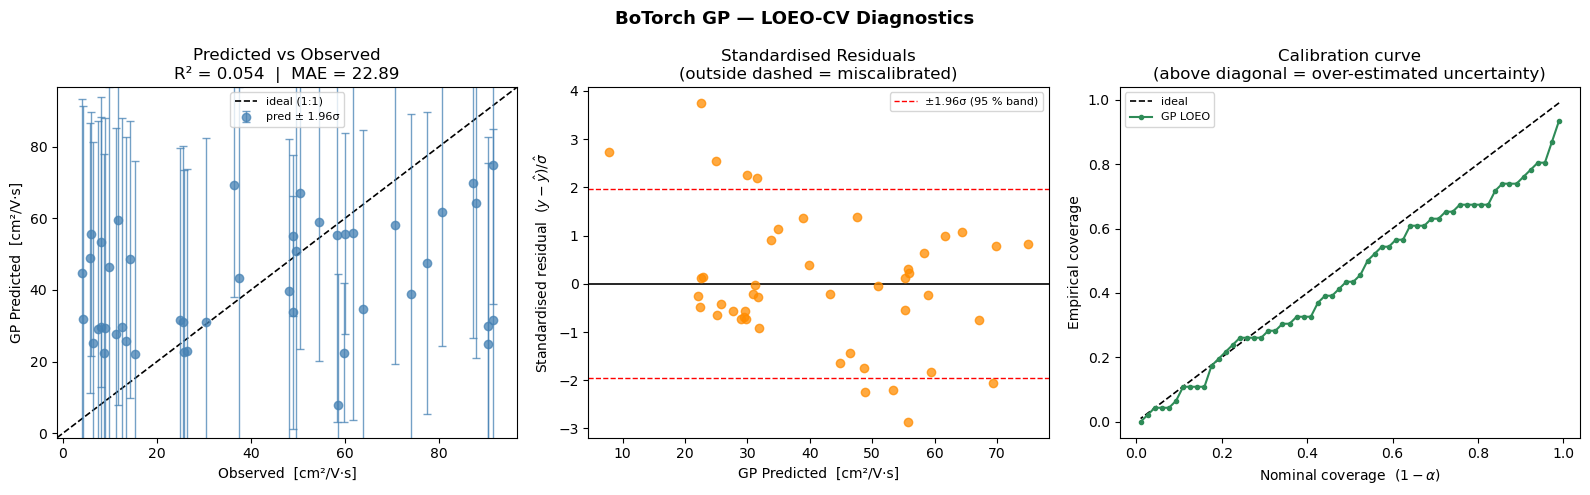

Saved: output/gp_loeo_diagnostics.png


In [6]:
# ── 5. Diagnostic plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("BoTorch GP \u2014 LOEO-CV Diagnostics", fontsize=13, fontweight="bold")
r2 = m_loeo["R²"]
mae = m_loeo["MAE"]
# 5a. Predicted vs Observed
ax = axes[0]
v_min = min(y_true.min(), y_pred.min())
v_max = max(y_true.max(), y_pred.max())
margin = (v_max - v_min) * 0.06
lims = [v_min - margin, v_max + margin]
ax.plot(lims, lims, "k--", lw=1.2, label="ideal (1:1)")
ax.errorbar(y_true, y_pred, yerr=z * y_std,
            fmt="o", color="steelblue", alpha=0.75,
            ecolor="steelblue", elinewidth=1, capsize=3, label="pred \u00b1 1.96\u03c3")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Observed  [cm\u00b2/V\u00b7s]")
ax.set_ylabel("GP Predicted  [cm\u00b2/V\u00b7s]")
ax.set_title(f"Predicted vs Observed\nR\u00b2 = {r2:.3f}  |  MAE = {mae:.2f}")
ax.legend(fontsize=8)

# 5b. Standardised residuals
ax = axes[1]
std_resids = (y_true - y_pred) / y_std
ax.scatter(y_pred, std_resids, color="darkorange", alpha=0.75, zorder=3)
ax.axhline(0,  color="k",   lw=1.2)
ax.axhline( z, color="red", lw=1, ls="--", label=f"\u00b1{z:.2f}\u03c3 (95 % band)")
ax.axhline(-z, color="red", lw=1, ls="--")
ax.set_xlabel("GP Predicted  [cm\u00b2/V\u00b7s]")
ax.set_ylabel("Standardised residual  $(y - \\hat{y})/\\hat{\\sigma}$")
ax.set_title("Standardised Residuals\n(outside dashed = miscalibrated)")
ax.legend(fontsize=8)

# 5c. Calibration curve
ax = axes[2]
alphas_vec = np.linspace(0.01, 0.99, 60)
coverages_emp = []
for a in alphas_vec:
    za = norm.ppf(1 - a / 2)
    cov_a = np.mean((y_true >= y_pred - za * y_std) & (y_true <= y_pred + za * y_std))
    coverages_emp.append(cov_a)
ax.plot(1 - alphas_vec, 1 - alphas_vec, "k--", lw=1.2, label="ideal")
ax.plot(1 - alphas_vec, coverages_emp, "o-", color="seagreen", ms=3, label="GP LOEO")
ax.set_xlabel("Nominal coverage  $(1 - \\alpha)$")
ax.set_ylabel("Empirical coverage")
ax.set_title("Calibration curve\n(above diagonal = over-estimated uncertainty)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("output/gp_loeo_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: output/gp_loeo_diagnostics.png")


In [7]:
# ── 6. Predictor importance \u2014 ARD length scales (reuses model_full from above)
from matplotlib.patches import Patch

# SingleTaskGP structure:
#   model_full.covar_module = ScaleKernel(MaternKernel(nu=2.5, ard_num_dims=d))
#   .outputscale  -> signal amplitude (\u03c3_f\u00b2)
#   .base_kernel.lengthscale -> tensor of shape (1, d)
#   model_full.likelihood.noise -> learned noise (\u03c3_n\u00b2), in standardised units
length_scales = model_full.covar_module.base_kernel.lengthscale.detach().view(-1).cpu().numpy()
amplitude     = float(model_full.covar_module.outputscale.detach().cpu())
noise_level   = float(model_full.likelihood.noise.detach().view(-1).cpu()[0])

# Inputs are inside Normalize(d=d), so length_scales are in the [0,1]-input space
# \u2014 directly comparable across features.
print(f"Amplitude   (\u03c3_f\u00b2) : {amplitude:.4f}")
print(f"Noise       (\u03c3_n\u00b2) : {noise_level:.4f}")
print(f"Signal-to-noise ratio : {amplitude/noise_level:.3f}")

inv_ls     = 1.0 / length_scales
importance = inv_ls / inv_ls.sum()

importance_df = (
    pd.DataFrame({
        "Feature"            : gp_features,
        "Length scale (l_j)" : length_scales,
        "1/l_j (raw)"        : inv_ls,
        "Importance (norm.)" : importance,
    })
    .sort_values("Importance (norm.)", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "="*65)
print(f"{'BoTorch GP \u2014 ARD Predictor Importance (full data)':^65}")
print("="*65)
print(importance_df.to_string(index=False, float_format="%.4f"))
print("\n* Inputs are normalised to [0, 1]; small l_j \u2192 high importance.")

color_map = {f: ("steelblue" if f in controllable else
                 "coral"     if f in xps_areas   else "seagreen")
             for f in importance_df["Feature"]}
fig, ax = plt.subplots(figsize=(9, 4))
colors_bar = [color_map[f] for f in importance_df["Feature"][::-1]]
ax.barh(importance_df["Feature"][::-1],
        importance_df["Importance (norm.)"][::-1],
        color=colors_bar, edgecolor="white")
ax.set_xlabel("Normalised importance  (1/\u2113_j, scaled to sum = 1)")
ax.set_title("BoTorch GP-ARD Predictor Importance\n(full-data fit)")
legend_handles = [
    Patch(facecolor="steelblue", label="Controllable"),
    Patch(facecolor="coral",     label="XPS area"),
    Patch(facecolor="seagreen",  label="XRD height"),
]
ax.legend(handles=legend_handles, fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig("output/gp_ard_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: output/gp_ard_importance.png")


AttributeError: 'RBFKernel' object has no attribute 'base_kernel'

In [ ]:
# ── 7. Permutation importance (model-agnostic, BoTorch GP per LOEO fold) ──────
rng = np.random.default_rng(42)
n_repeats = 20
baseline_mae = np.mean(np.abs(y_true - y_pred))

perm_deltas = np.zeros((n_feat, n_repeats))

for exp in experiments:
    mask_test  = df_gp["Experiment"] == exp
    mask_train = ~mask_test

    X_tr = df_gp.loc[mask_train, gp_features].values.astype(float)
    y_tr = df_gp.loc[mask_train, target].values.astype(float)
    X_te = df_gp.loc[mask_test,  gp_features].values.astype(float)
    y_te = df_gp.loc[mask_test,  target].values.astype(float)

    model_f = fit_botorch_gp(X_tr, y_tr)
    model_f.eval()

    for j in range(n_feat):
        for r in range(n_repeats):
            X_perm = X_te.copy()
            X_perm[:, j] = rng.permutation(X_perm[:, j])
            with torch.no_grad():
                mu_perm = model_f.posterior(
                    torch.tensor(X_perm, dtype=torch.double)
                ).mean.view(-1).cpu().numpy()
            perm_deltas[j, r] += np.mean(np.abs(y_te - mu_perm))

perm_deltas /= len(experiments)
perm_mean = perm_deltas.mean(axis=1) - baseline_mae
perm_std  = perm_deltas.std(axis=1)

perm_df = (
    pd.DataFrame({
        "Feature"           : gp_features,
        "\u0394 MAE (mean)" : perm_mean,
        "\u0394 MAE (std)"  : perm_std,
    })
    .sort_values("\u0394 MAE (mean)", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "="*58)
print(f"{'Permutation Importance \u2014 BoTorch GP, LOEO, 20 reps':^58}")
print("="*58)
print(perm_df.to_string(index=False, float_format="%.4f"))
print("\n* \u0394 MAE > 0 \u2192 shuffling increases error \u2192 feature is important.")
print("* \u0394 MAE \u2248 0 \u2192 shuffling has no effect \u2192 feature is uninformative.")

from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(9, 4))
feat_order  = perm_df["Feature"].tolist()[::-1]
vals_order  = perm_df["\u0394 MAE (mean)"].tolist()[::-1]
errs_order  = perm_df["\u0394 MAE (std)"].tolist()[::-1]
c_order = ["steelblue" if f in controllable else
           "coral"     if f in xps_areas   else "seagreen" for f in feat_order]
ax.barh(feat_order, vals_order, xerr=errs_order, color=c_order, edgecolor="white",
        error_kw=dict(elinewidth=1, capsize=3))
ax.axvline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel("\u0394 MAE when feature is permuted  [cm\u00b2/V\u00b7s]")
ax.set_title("BoTorch GP \u2014 Permutation Importance\n(higher \u0394 MAE = more important)")
legend_handles = [
    Patch(facecolor="steelblue", label="Controllable"),
    Patch(facecolor="coral",     label="XPS area"),
    Patch(facecolor="seagreen",  label="XRD height"),
]
ax.legend(handles=legend_handles, fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig("output/gp_permutation_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: output/gp_permutation_importance.png")
